In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

def head_turn_calcs(df):
    for ind, row in df.iterrows():
        obstacle_ind = int(row.obstacle_ind)
        vel = row.head_angle_velocity[:obstacle_ind]
        
        # Detect positive and negative peaks separately
        pos_peaks, pos_props = find_peaks(vel, width=3,prominence=1,height=0)
        neg_peaks, neg_props = find_peaks(-vel, width=3,prominence=1,height=0)
        
        # Store positive peaks info
        pos_heights = pos_props['peak_heights'] if len(pos_peaks) > 0 else np.array([])
        pos_left_ips = pos_props['left_ips'] if len(pos_peaks) > 0 else np.array([])
        pos_right_ips = pos_props['right_ips'] if len(pos_peaks) > 0 else np.array([])
        
        # Store negative peaks info (convert heights back to negative values)
        neg_heights = -neg_props['peak_heights'] if len(neg_peaks) > 0 else np.array([])
        neg_left_ips = neg_props['left_ips'] if len(neg_peaks) > 0 else np.array([])
        neg_right_ips = neg_props['right_ips'] if len(neg_peaks) > 0 else np.array([])
        
        # Combine all peaks for main peak selection
        all_peaks = np.concatenate([pos_peaks, neg_peaks])
        all_heights = np.concatenate([pos_heights, neg_heights])
        
        # NEW: Calculate large head movements (absolute velocity > 3)
        if len(all_peaks) > 0:
            abs_heights = np.abs(all_heights)
            large_turn_mask = abs_heights > 3
            large_turn_indexs = all_peaks[large_turn_mask]
            large_turn_velocities = all_heights[large_turn_mask]
        else:
            large_turn_indexs = np.array([])
            large_turn_velocities = np.array([])
        
        if len(all_peaks) > 0:
            # Find main peak (max absolute velocity)
            max_abs_idx = np.argmax(np.abs(all_heights))
            main_peak = all_peaks[max_abs_idx]
            main_height = all_heights[max_abs_idx]
            
            # Determine if main peak is positive or negative
            if main_peak in pos_peaks:
                pos_idx = np.where(pos_peaks == main_peak)[0][0]
                main_left_ip = pos_left_ips[pos_idx]
                main_right_ip = pos_right_ips[pos_idx]
            else:
                neg_idx = np.where(neg_peaks == main_peak)[0][0]
                main_left_ip = neg_left_ips[neg_idx]
                main_right_ip = neg_right_ips[neg_idx]
                
            start_movement = int(np.round(main_left_ip))
            end_movement = int(np.round(main_right_ip))
            
            # Store main peak values
            df.at[ind, 'distance_at_head_turn'] = row.ts_distance_from_edge[main_peak]
            df.at[ind, 'distance_after_head_turn'] = row.ts_distance_from_edge[end_movement]
            df.at[ind, 'distance_before_head_turn'] = row.ts_distance_from_edge[start_movement]
            df.at[ind, 'indexs_of_head_turn'] = np.array([start_movement, main_peak, end_movement]).astype(object)
            df.at[ind, 'angle_at_head_turn'] = row.ts_angle_to_corner[main_peak]
            df.at[ind, 'angle_after_head_turn'] = row.ts_angle_to_corner[end_movement]
            df.at[ind, 'angle_before_head_turn'] = row.ts_angle_to_corner[start_movement]
            df.at[ind, 'head_turn_velocity'] = main_height
            df.at[ind, 'num_turn'] = len(all_peaks)
            
            # Store all peaks information (combined)
            df.at[ind, 'head_turn_indexs'] = all_peaks.astype(object)
            df.at[ind, 'head_turn_velocities'] = all_heights.astype(object)
            
            # NEW: Store large head movements information
            df.at[ind, 'large_head_turn_indexs'] = large_turn_indexs.astype(object)
            df.at[ind, 'large_head_turn_velocities'] = large_turn_velocities.astype(object)
            
            # Store separate positive/negative peaks information
            df.at[ind, 'positive_peaks'] = pos_peaks.astype(object)
            df.at[ind, 'positive_heights'] = pos_heights.astype(object)
            df.at[ind, 'positive_left_ips'] = pos_left_ips.astype(object)
            df.at[ind, 'positive_right_ips'] = pos_right_ips.astype(object)
            
            df.at[ind, 'negative_peaks'] = neg_peaks.astype(object)
            df.at[ind, 'negative_heights'] = neg_heights.astype(object)
            df.at[ind, 'negative_left_ips'] = neg_left_ips.astype(object)
            df.at[ind, 'negative_right_ips'] = neg_right_ips.astype(object)
            
            # Store non-main peaks information
            non_main_peaks = np.delete(all_peaks, max_abs_idx)
            if len(non_main_peaks) > 0:
                df.at[ind, 'angles_at_head_turns'] = row.ts_angle_to_corner[non_main_peaks].astype(object)
                df.at[ind, 'distances_at_head_turns'] = row.ts_distance_from_edge[non_main_peaks].astype(object)
                
                # Find end indices for non-main peaks
                non_main_ends = []
                for peak in non_main_peaks:
                    if peak in pos_peaks:
                        idx = np.where(pos_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(pos_right_ips[idx])))
                    else:
                        idx = np.where(neg_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(neg_right_ips[idx])))
                df.at[ind, 'angles_at_head_turns_ends'] = row.ts_angle_to_corner[non_main_ends].astype(object)
            else:
                df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
        else:
            # Handle case with no peaks found
            df.at[ind, 'distance_at_head_turn'] = np.nan
            df.at[ind, 'distance_after_head_turn'] = np.nan
            df.at[ind, 'distance_before_head_turn'] = np.nan
            df.at[ind, 'indexs_of_head_turn'] = np.array([np.nan])
            df.at[ind, 'head_turn_indexs'] = np.array([np.nan])
            df.at[ind, 'angle_at_head_turn'] = np.nan
            df.at[ind, 'angle_after_head_turn'] = np.nan
            df.at[ind, 'angle_before_head_turn'] = np.nan
            df.at[ind, 'num_turn'] = 0
            df.at[ind, 'head_turn_velocity'] = np.nan
            df.at[ind, 'head_turn_velocities'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
            df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
            
            # NEW: Empty arrays for large head movements
            df.at[ind, 'large_head_turn_indexs'] = np.array([]).astype(object)
            df.at[ind, 'large_head_turn_velocities'] = np.array([]).astype(object)
            
            # Empty arrays for positive/negative peaks
            df.at[ind, 'positive_peaks'] = np.array([]).astype(object)
            df.at[ind, 'positive_heights'] = np.array([]).astype(object)
            df.at[ind, 'positive_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'positive_right_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_peaks'] = np.array([]).astype(object)
            df.at[ind, 'negative_heights'] = np.array([]).astype(object)
            df.at[ind, 'negative_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_right_ips'] = np.array([]).astype(object)
    
    return df

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.family':'arial',
    'font.size': 32,
    'font.weight':'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [5]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [6]:
head_turn_calcs(light_dark)

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,large_head_turn_indexs,large_head_turn_velocities,positive_peaks,positive_heights,positive_left_ips,positive_right_ips,negative_peaks,negative_heights,negative_left_ips,negative_right_ips
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[9, 87, 29, 51, 80, 150]","[3.467894526684183, 70.76484211201341, -3.5383...","[9, 87, 117]","[3.467894526684183, 70.76484211201341, 0.87842...","[4.348496372157843, 84.57520408092827, 111.802...","[16.19392975054704, 89.74667185224443, 138.917...","[29, 51, 80, 101, 109, 150]","[-3.538385458538178, -6.072763103973279, -15.5...","[25.905246144139266, 47.32339025628978, 75.456...","[32.12845040781993, 54.57613982891745, 82.6354..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[18, 41, 187, 197, 163]","[6.900105355577886, 3.2853130494794236, 7.1115...","[18, 41, 59, 68, 80, 112, 155, 187, 197]","[6.900105355577886, 3.2853130494794236, 0.4219...","[14.29968179236998, 34.45417430857124, 56.8175...","[21.134328939577735, 47.497331594384946, 60.99...","[27, 54, 63, 72, 96, 142, 163]","[-1.084529998922007, -1.007367450928327, -1.23...","[23.633723715468523, 51.22741380863773, 60.626...","[34.45417430857124, 56.81754859503331, 65.6960..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,"[123, 105]","[5.169556264047671, -5.381416681158556]","[45, 79, 123]","[1.6242393845730319, 0.40463929208811134, 5.16...","[41.41521186946102, 75.05998884876111, 121.202...","[47.47076883555107, 100.83250327208884, 124.89...","[60, 73, 105]","[-2.770484234614008, -2.029725669811883, -5.38...","[49.027626511169174, 70.0490124411182, 101.532...","[63.70320204647564, 75.23238818008673, 109.858..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[32, 57, 172, 69, 182]","[4.847588182779208, 27.177322177033663, 4.4365...","[5, 32, 57, 136, 172]","[0.607569965280006, 4.847588182779208, 27.1773...","[3.312465447674962, 27.244918924558764, 53.311...","[7.222653906163416, 39.43742784770508, 60.3740...","[11, 45, 69, 141, 182]","[-2.5443679094536087, -1.326131825354483, -3.6...","[8.573024614211446, 39.43742784770508, 63.7155...","[14.41270127641714, 47.64617801007571, 143.401..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.

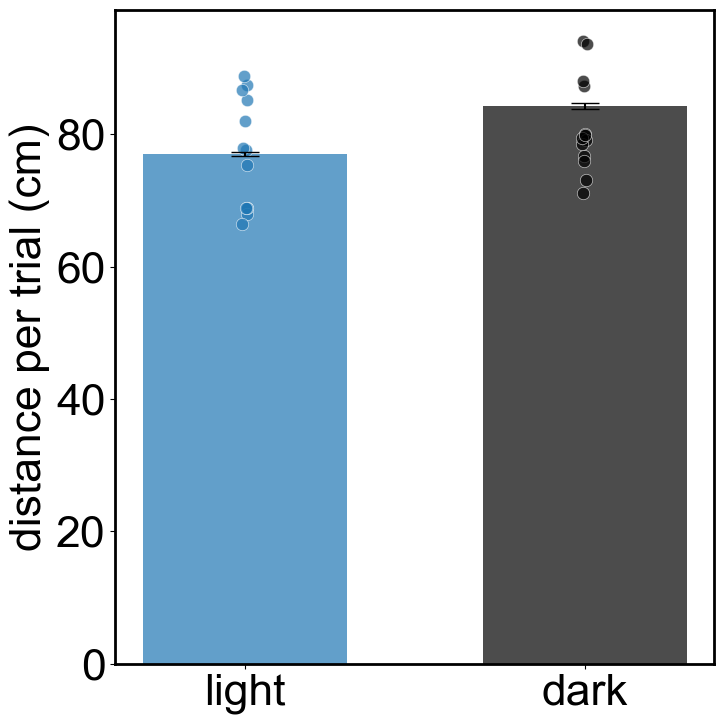

In [611]:
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.total_distance>=0]  # Only valid distances


# Split by turn direction
left_data = data[data['task'] == 'oa']
right_data = data[data['task'] == 'oadark']

# Calculate means and standard errors
left_mean = left_data['total_distance'].mean()
left_se = left_data['total_distance'].sem()
right_mean = right_data['total_distance'].mean()
right_se = right_data['total_distance'].sem()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, right_mean, yerr=right_se, color='black', 
       alpha=0.7, capsize=10, width=0.6, label='dark')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('distance per trial (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='light'),
                   Line2D([0], [0], color='black', lw=4, label='dark')]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

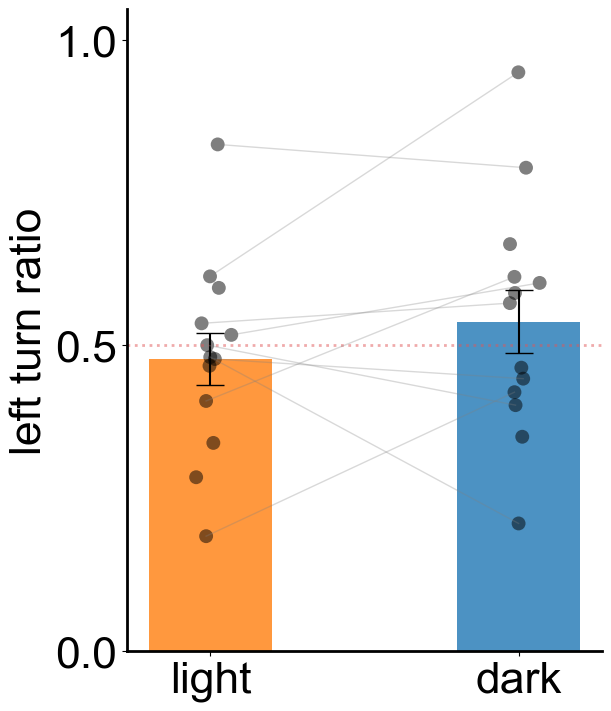

In [29]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(7, 8))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#
#data = data[data.intial_lateral_error<0] 



# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oadark'] 

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order)
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['light', 'dark'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)



plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\left_ratio_mon.pdf", dpi=300, transparent=True)
plt.show()

In [4]:
calculate_speed(light_dark)

In [6]:
distance_at_head_turn(light_dark)

In [ ]:
head_turn_calcs()

In [3]:
light_dark.head_turn_velocities

NameError: name 'light_dark' is not defined

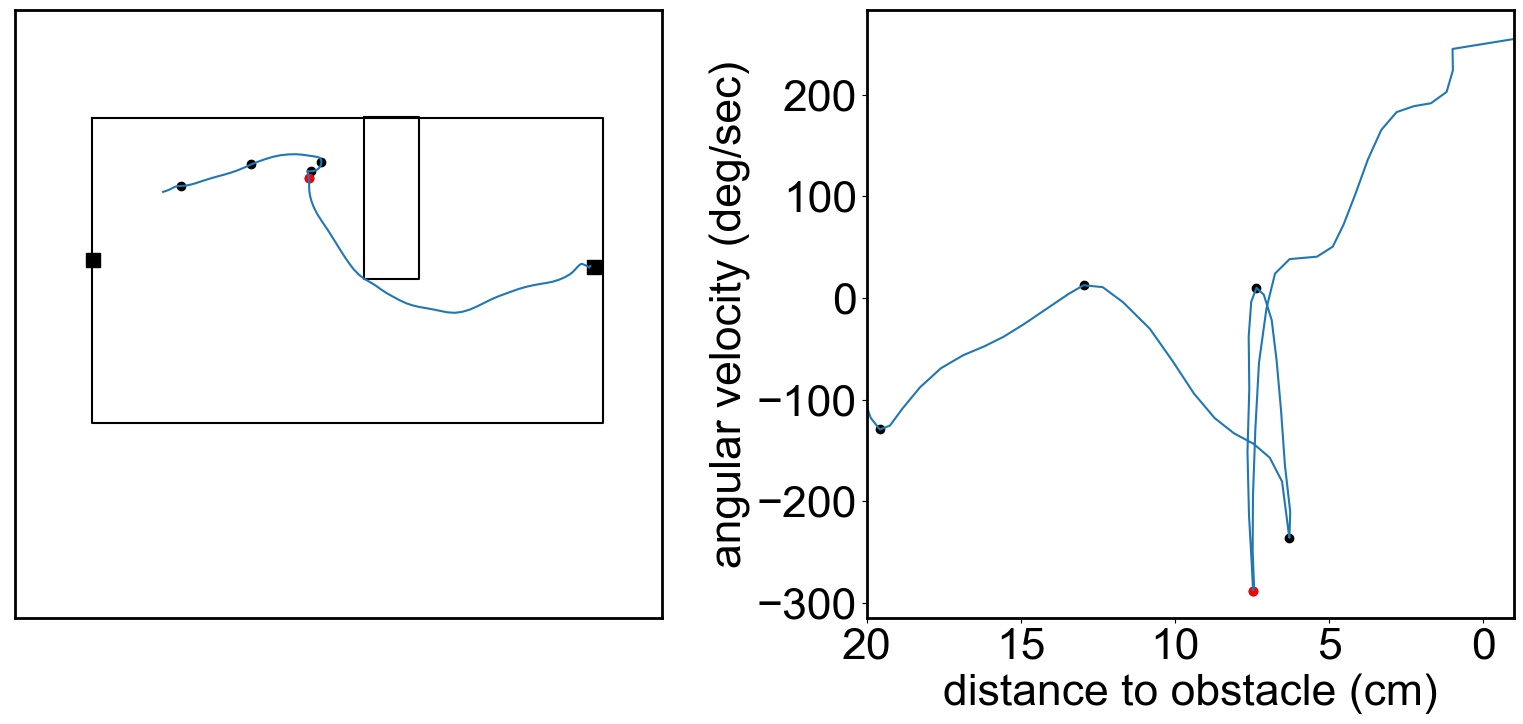

In [612]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 


sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(16,8),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:blue')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[peaks],smooth(row.ts_nose_y_cm)[peaks],color = 'black')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.head_angle_velocity[:ob_ind])*60,color = 'tab:blue')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][peaks],smooth(row.head_angle_velocity)[peaks]*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][thresh],smooth(row.head_angle_velocity)[thresh]*60,color = 'red')

In [619]:
peaks

[14, 44, 5, 33, 49]

In [618]:
[x  -1 for x in peaks]

[13, 43, 4, 32, 48]

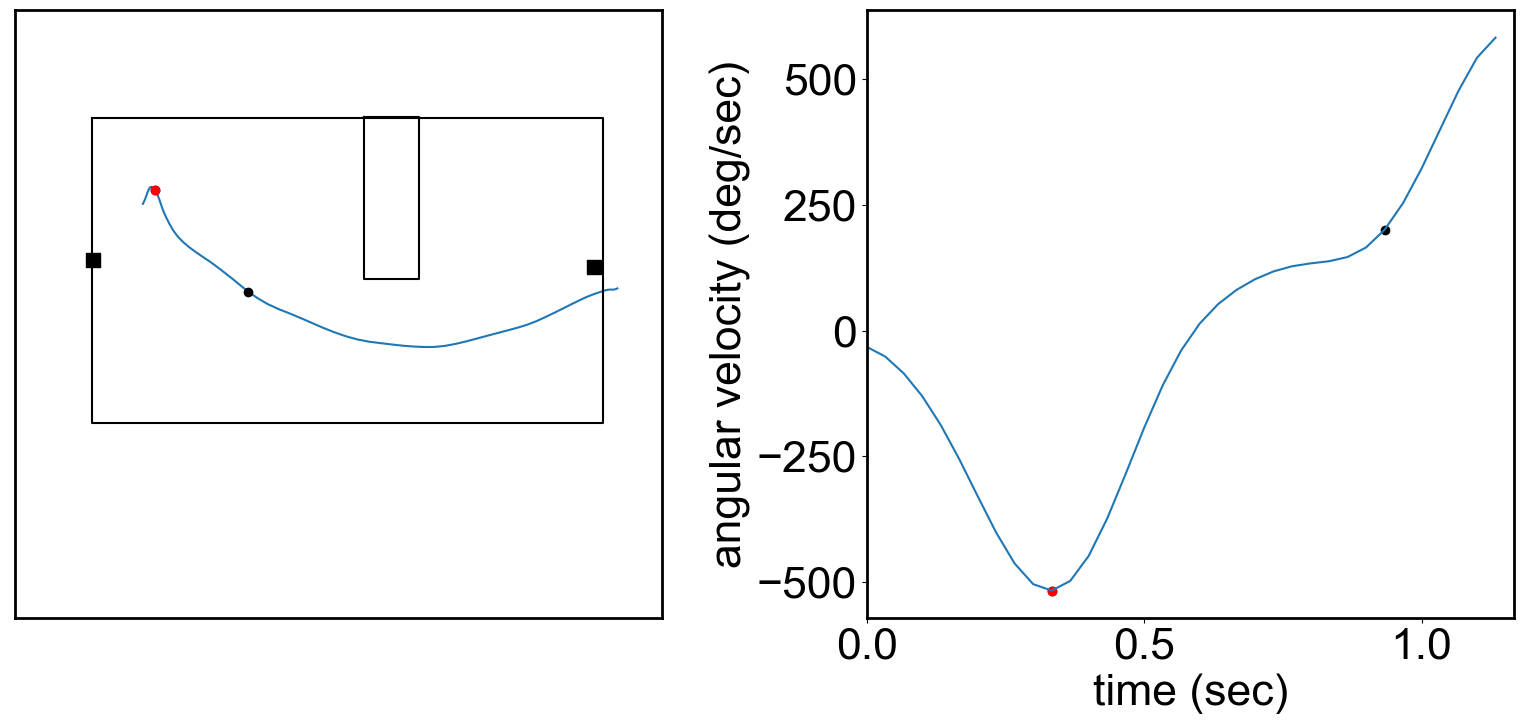

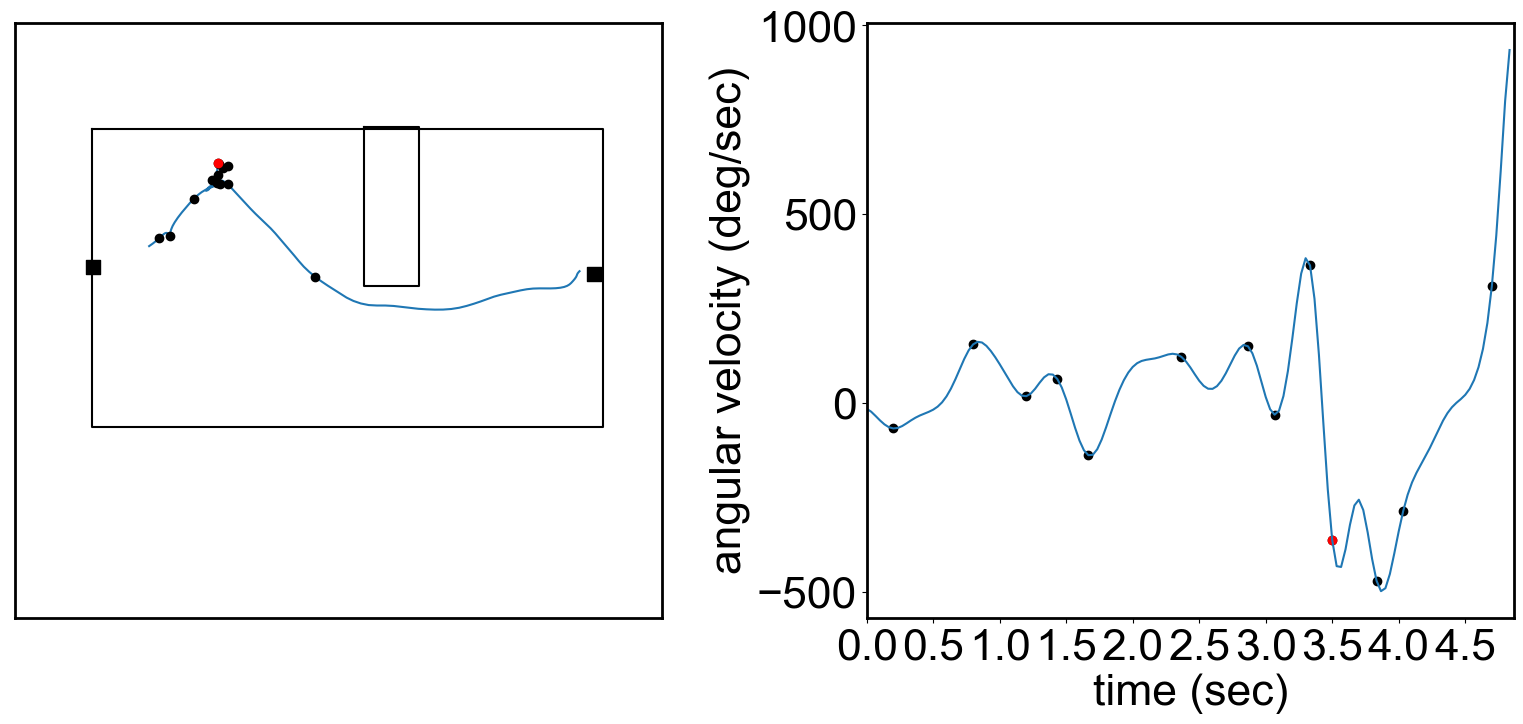

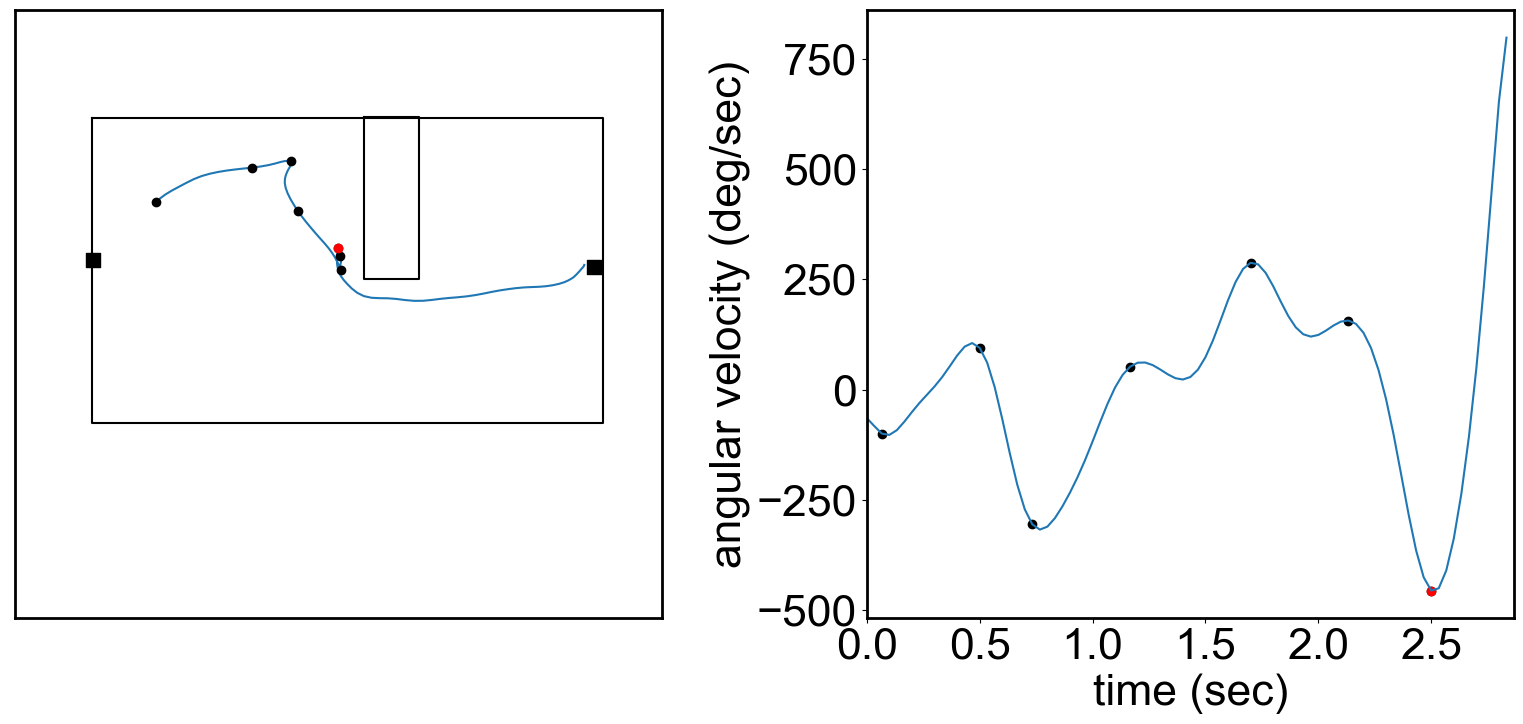

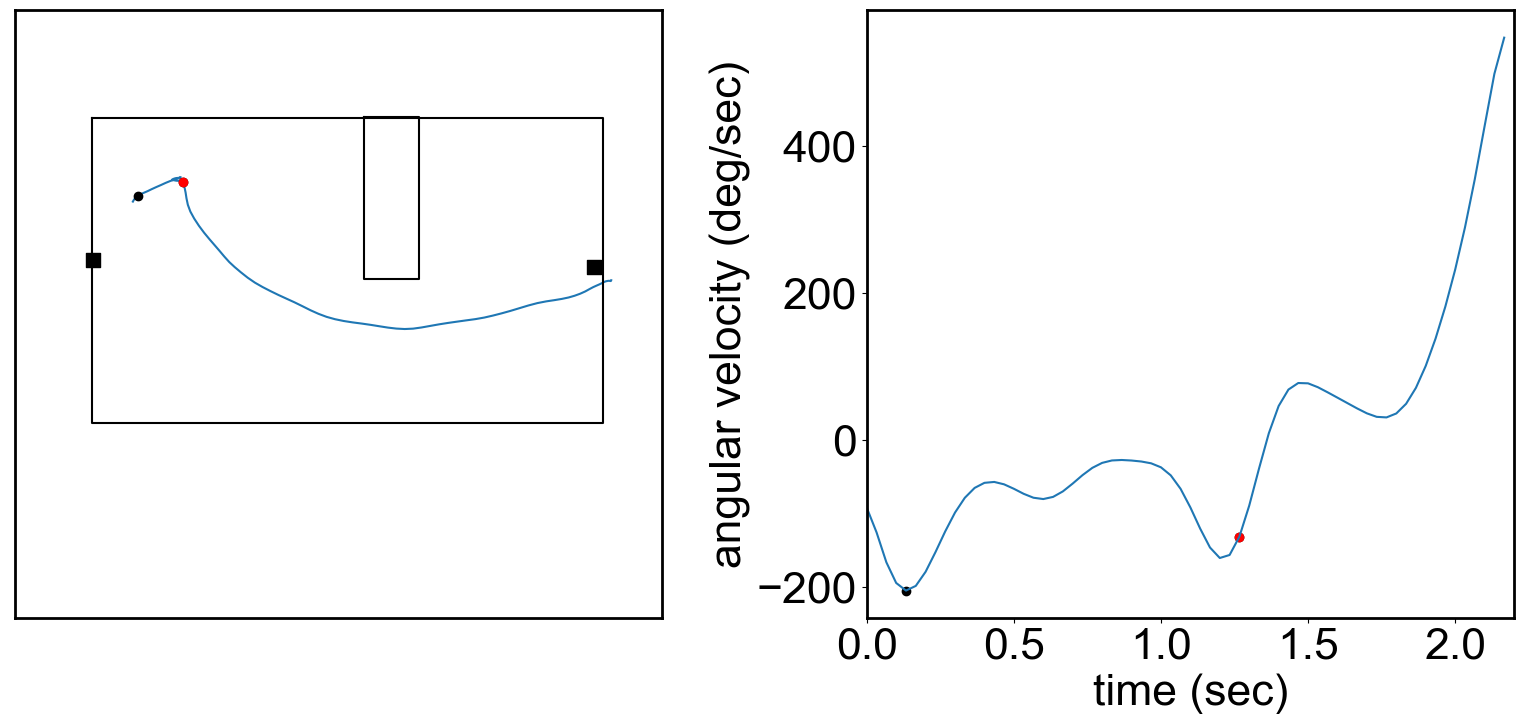

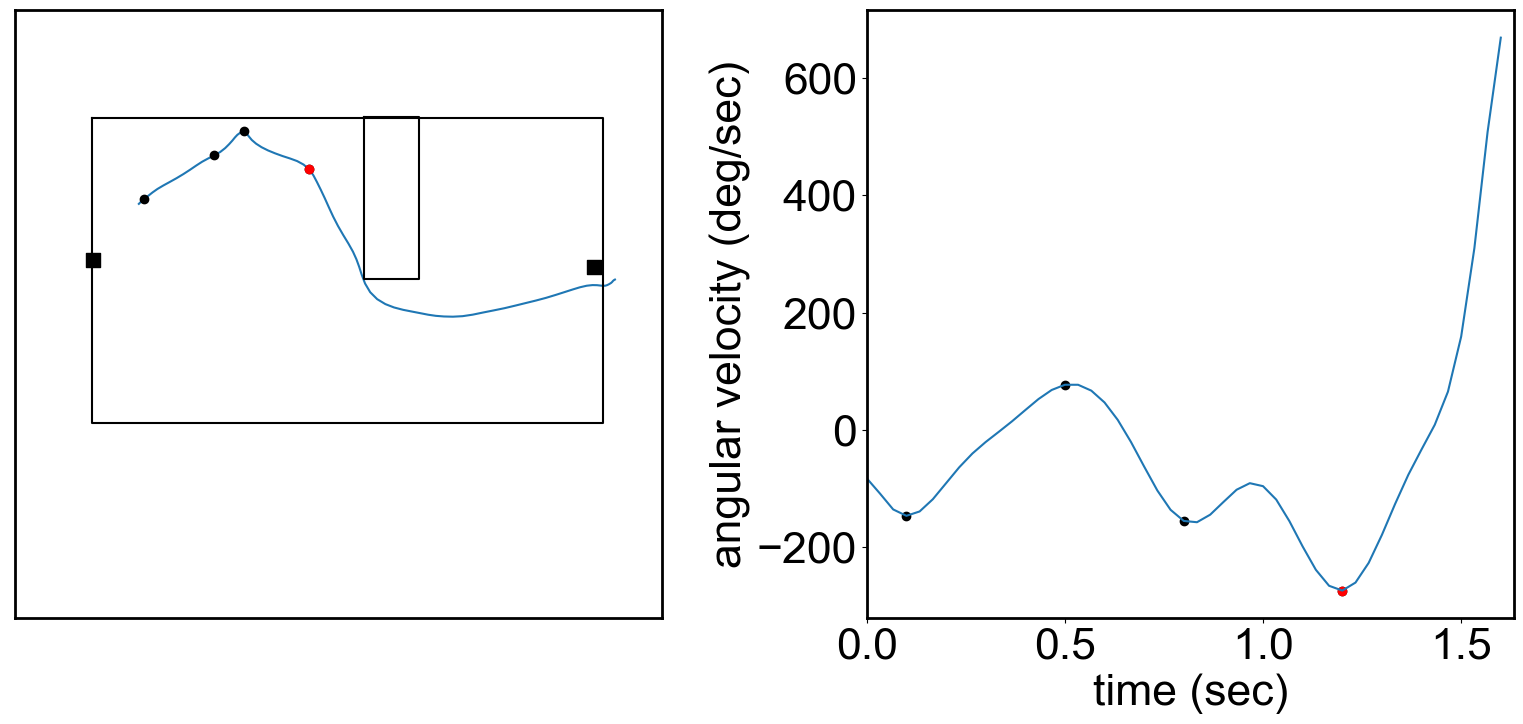

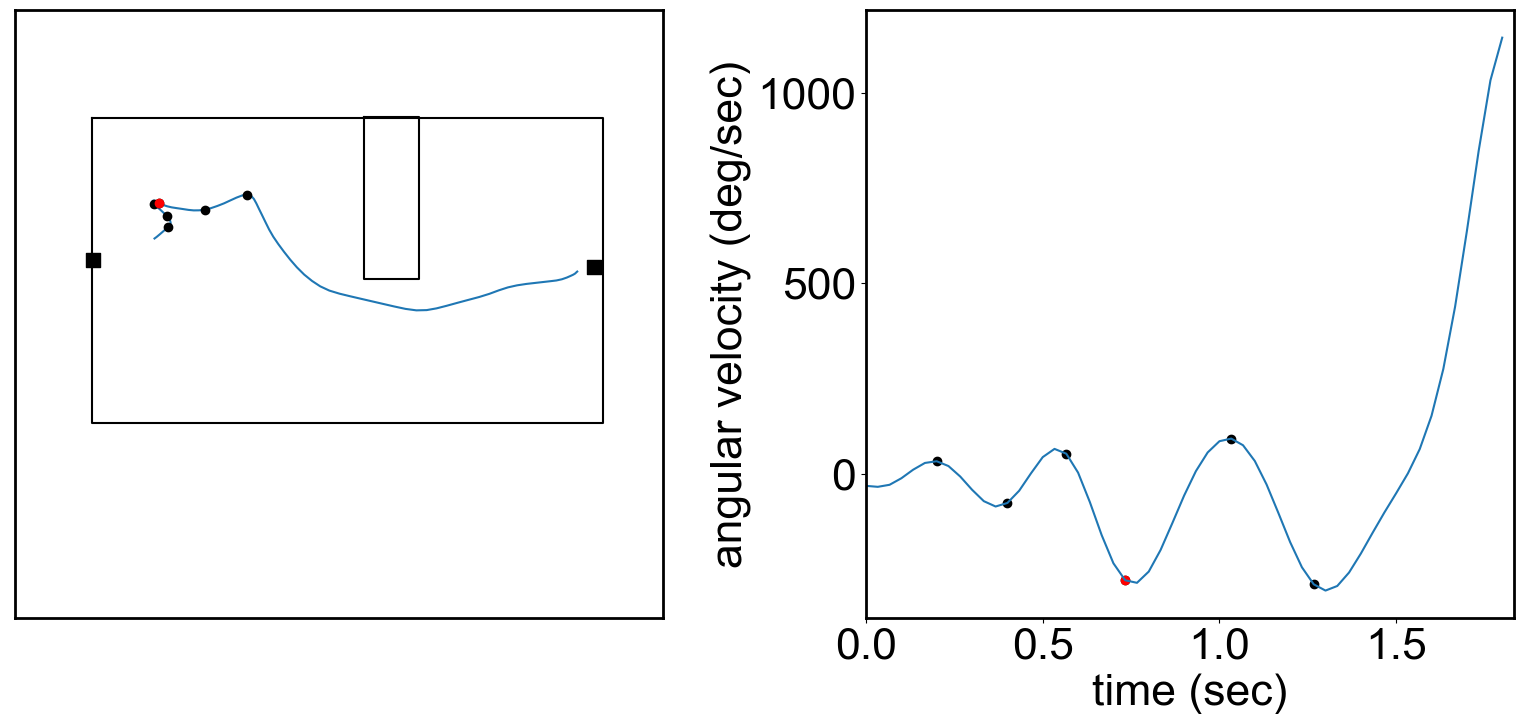

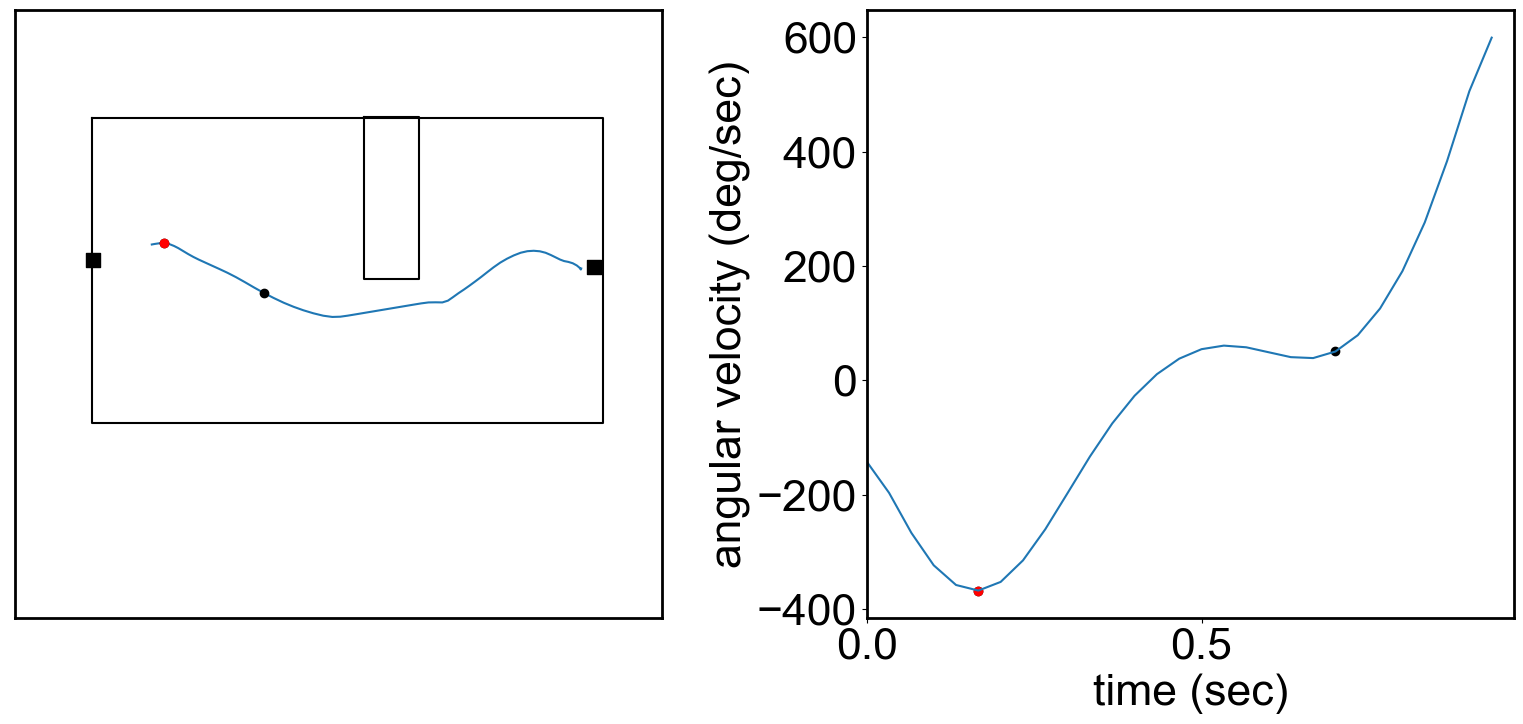

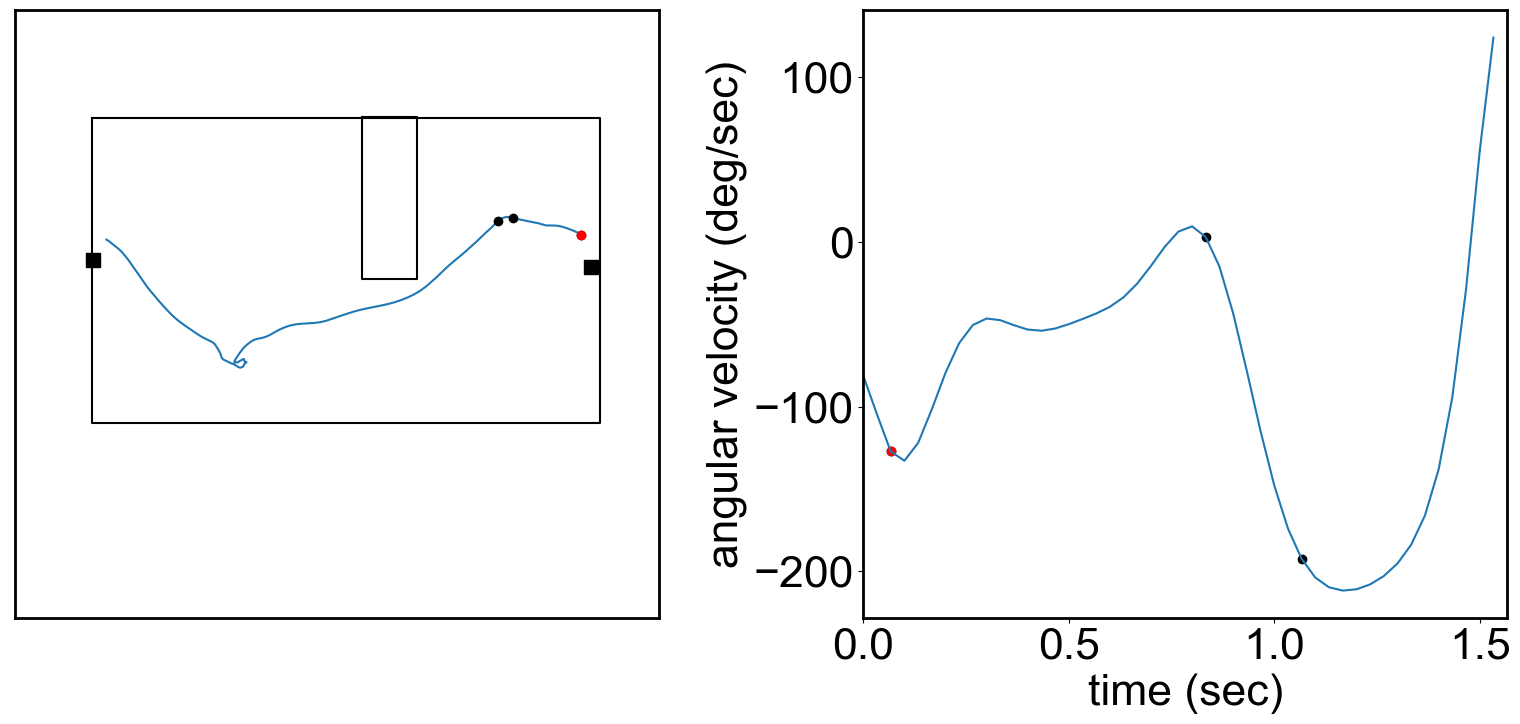

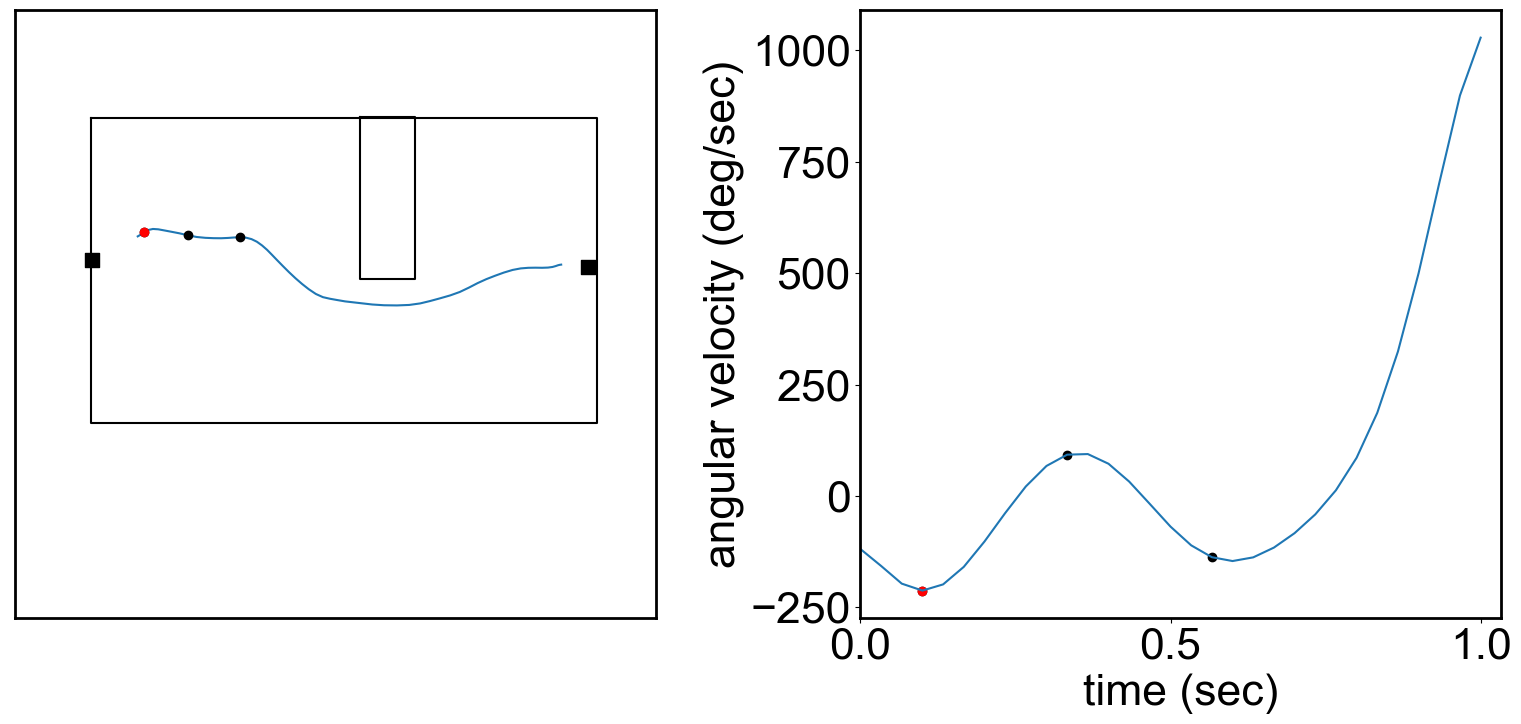

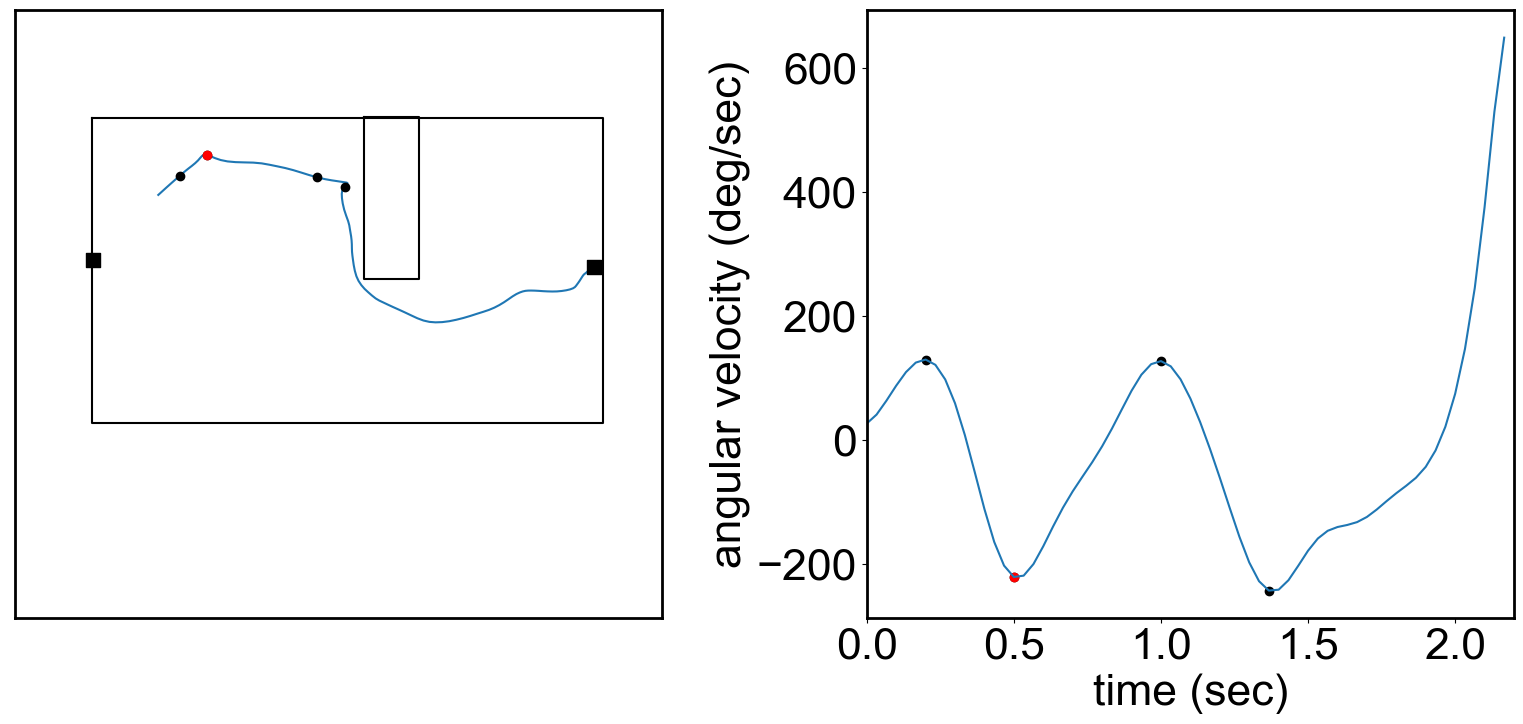

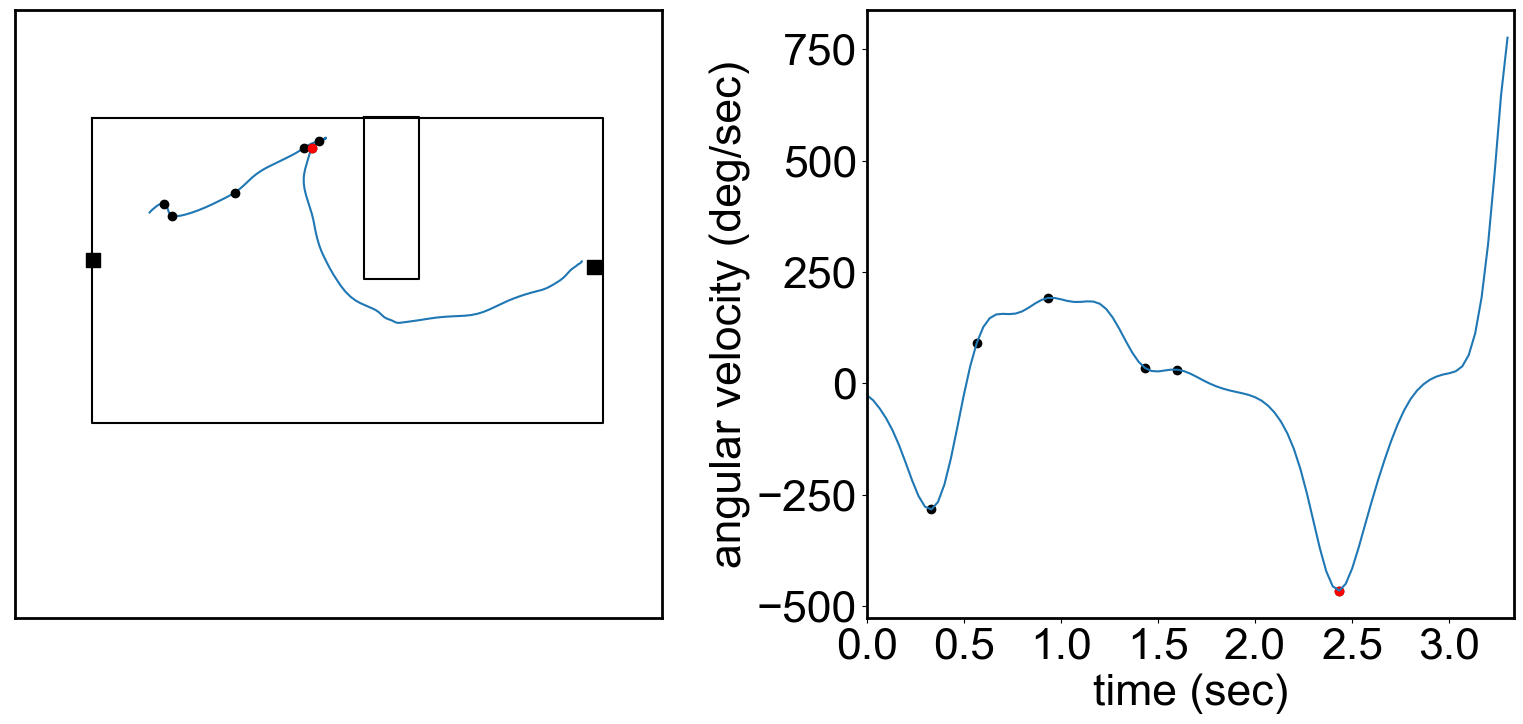

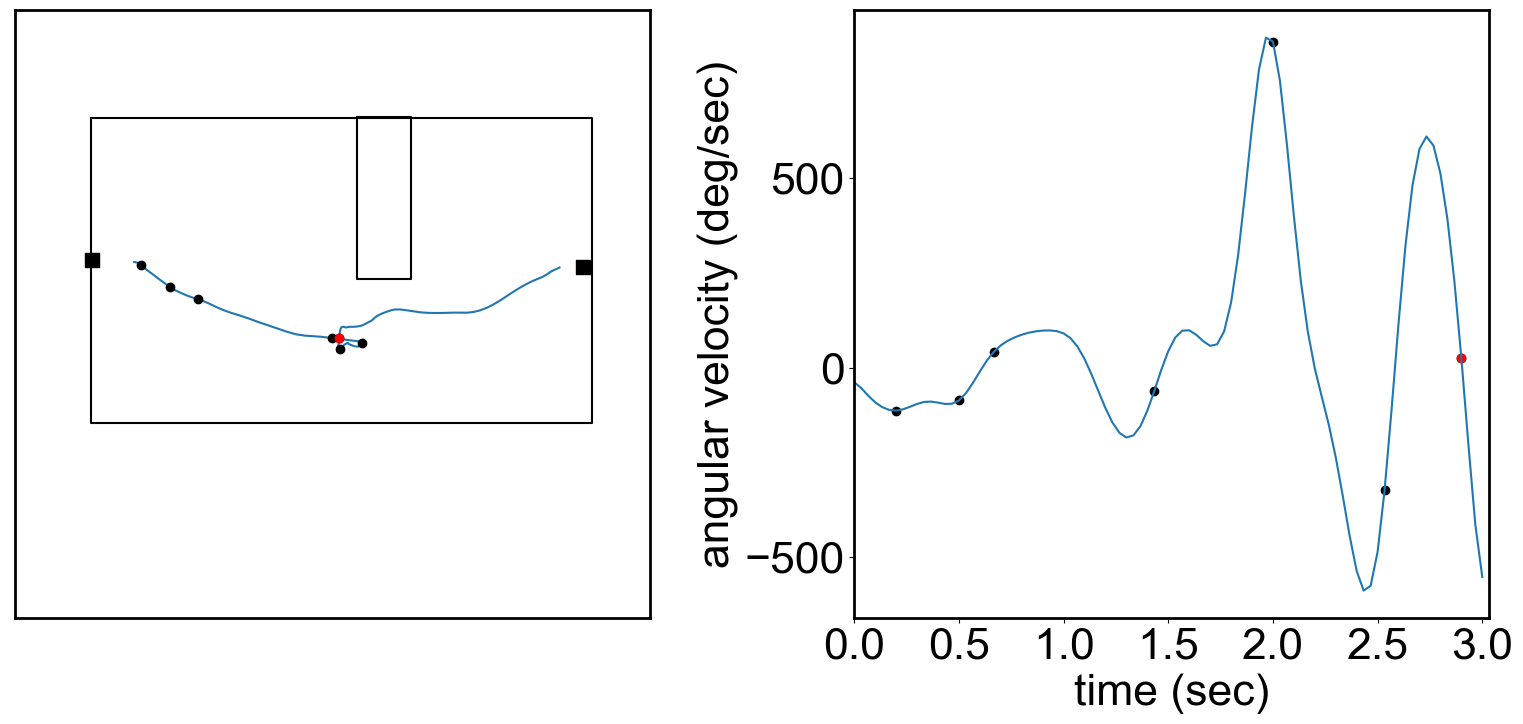

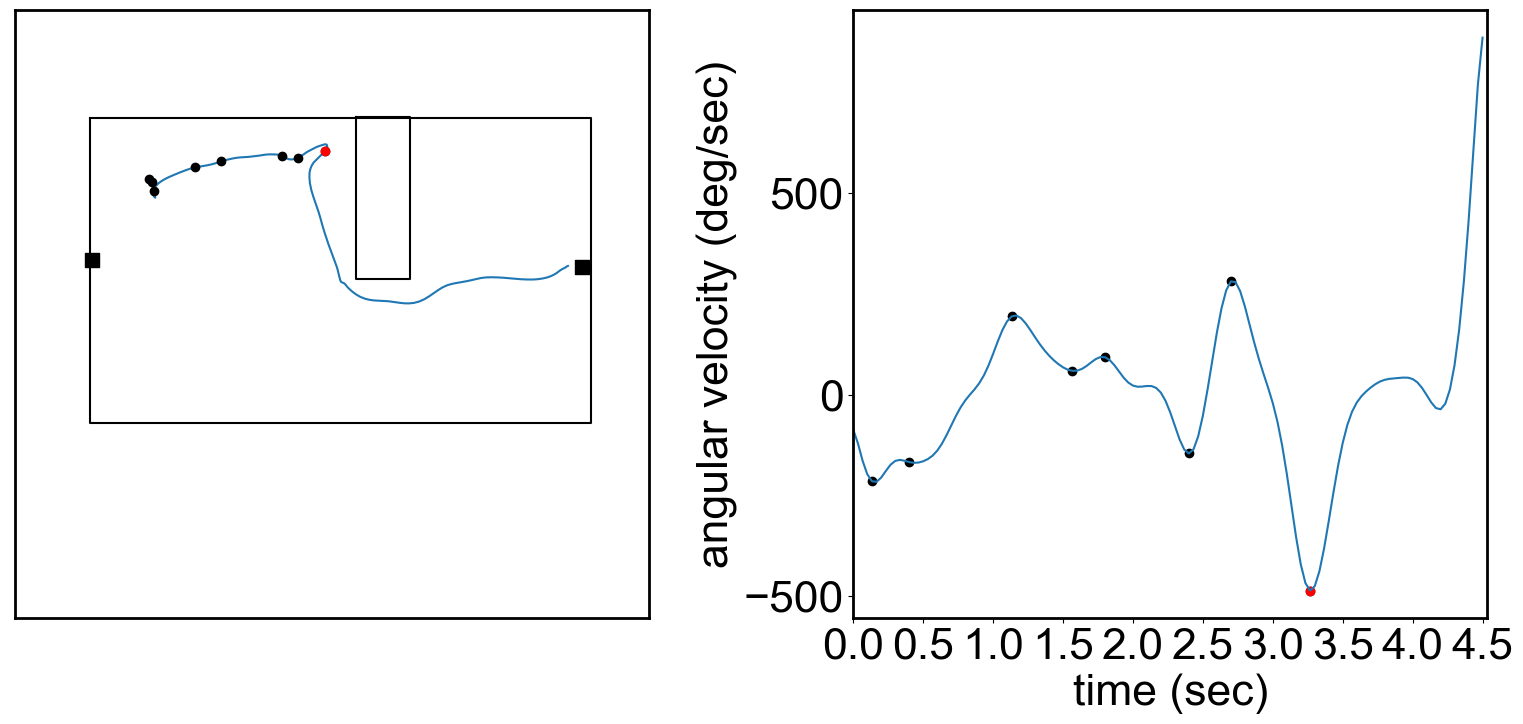

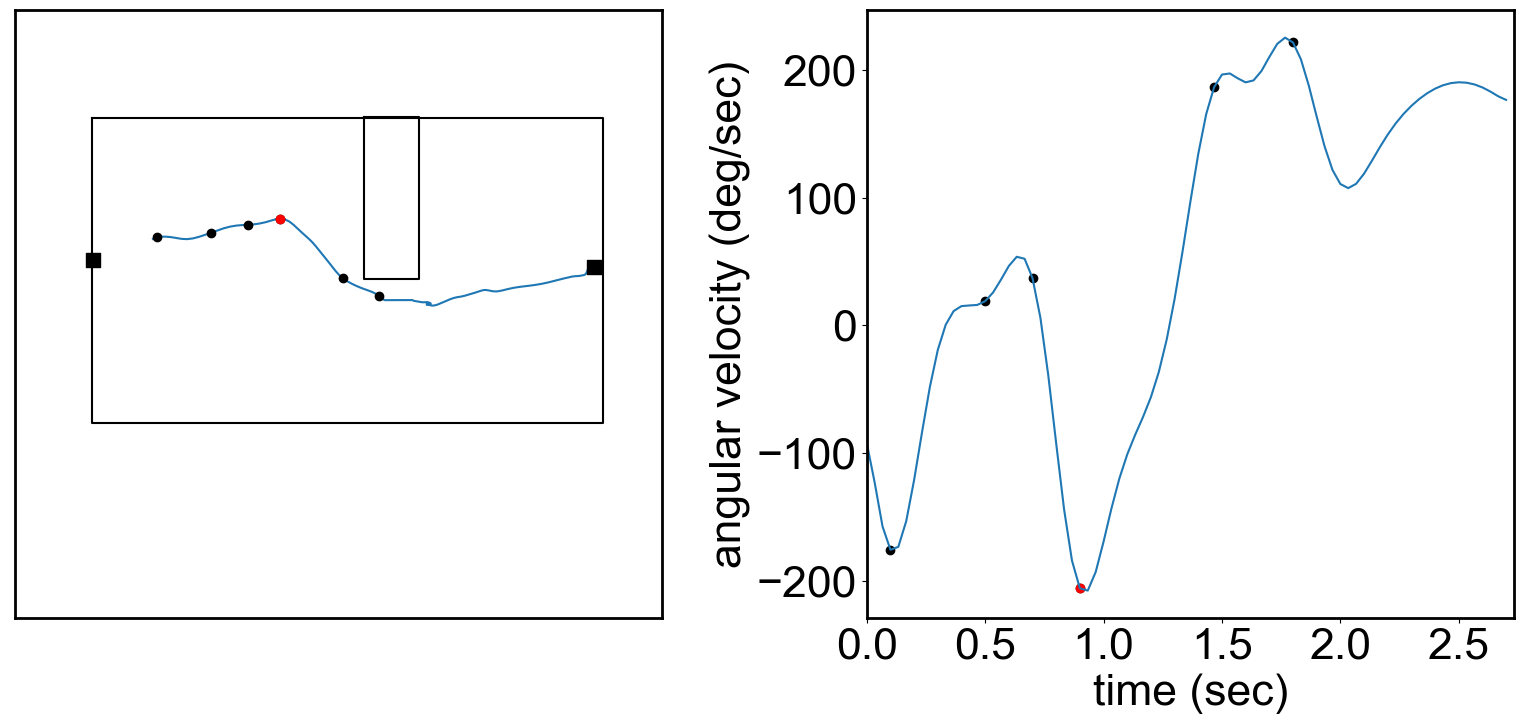

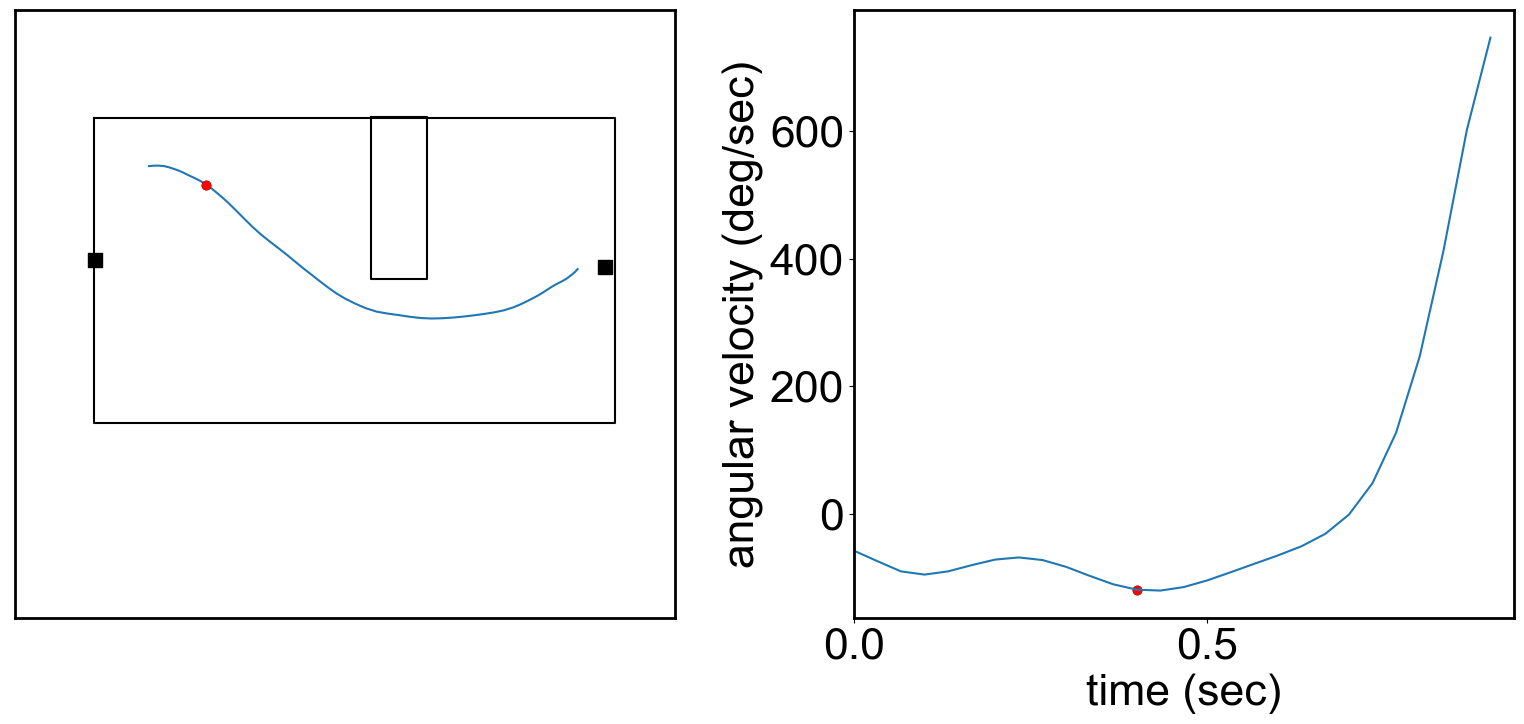

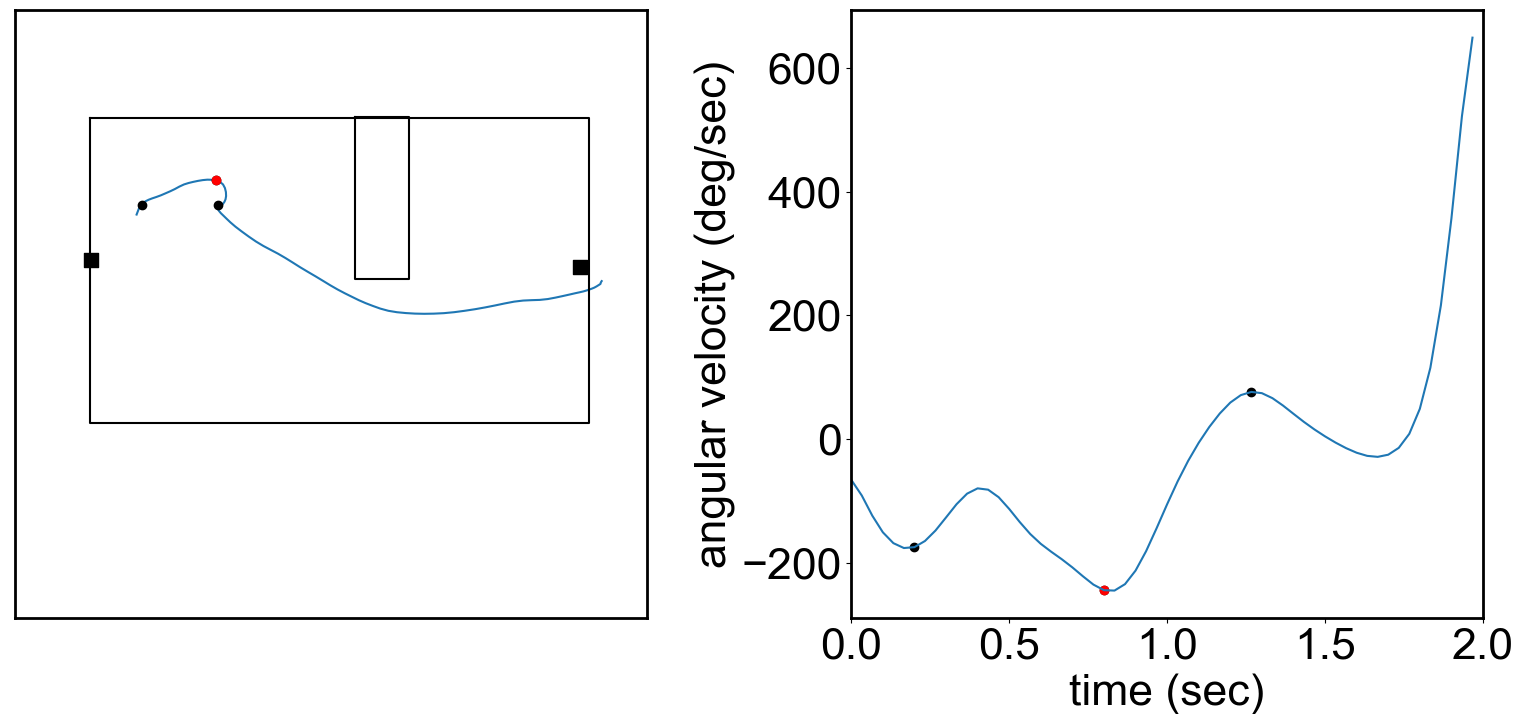

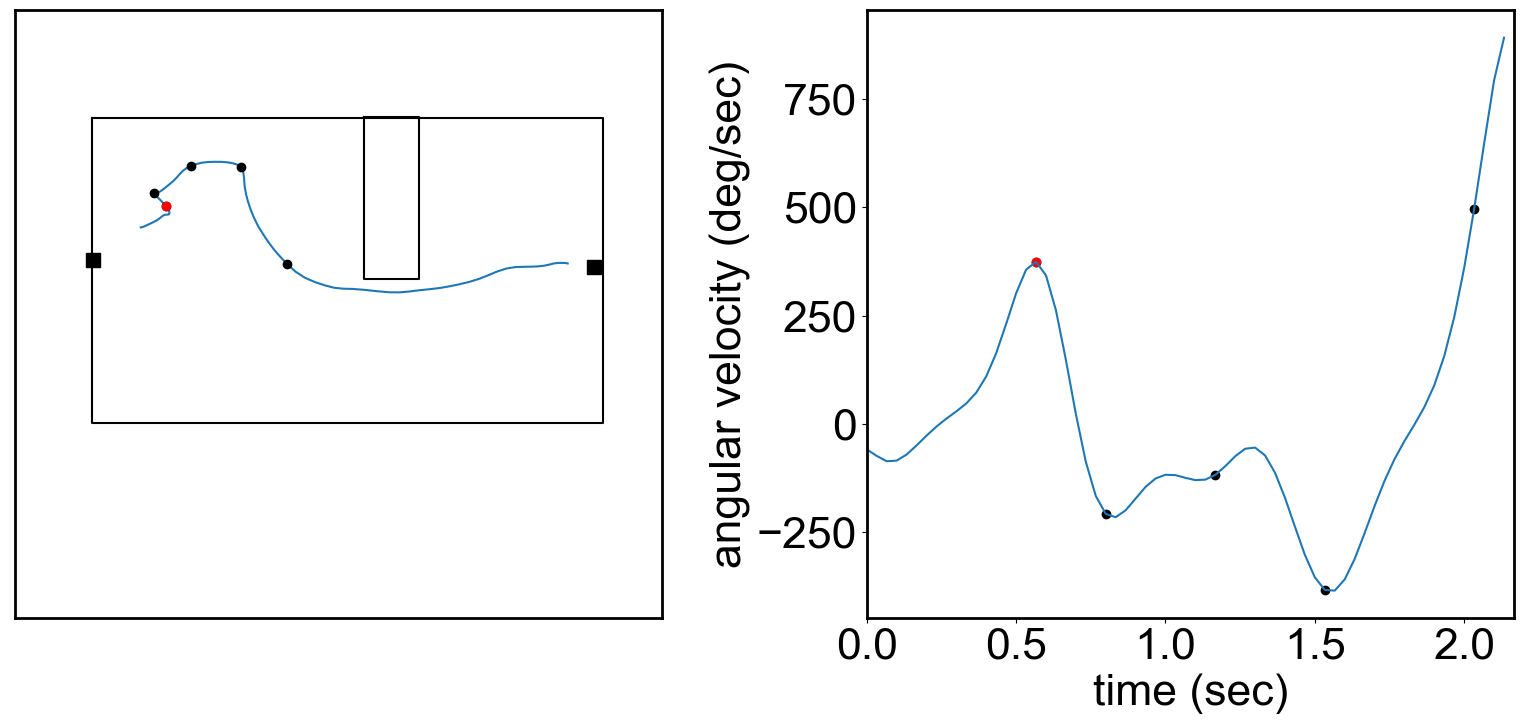

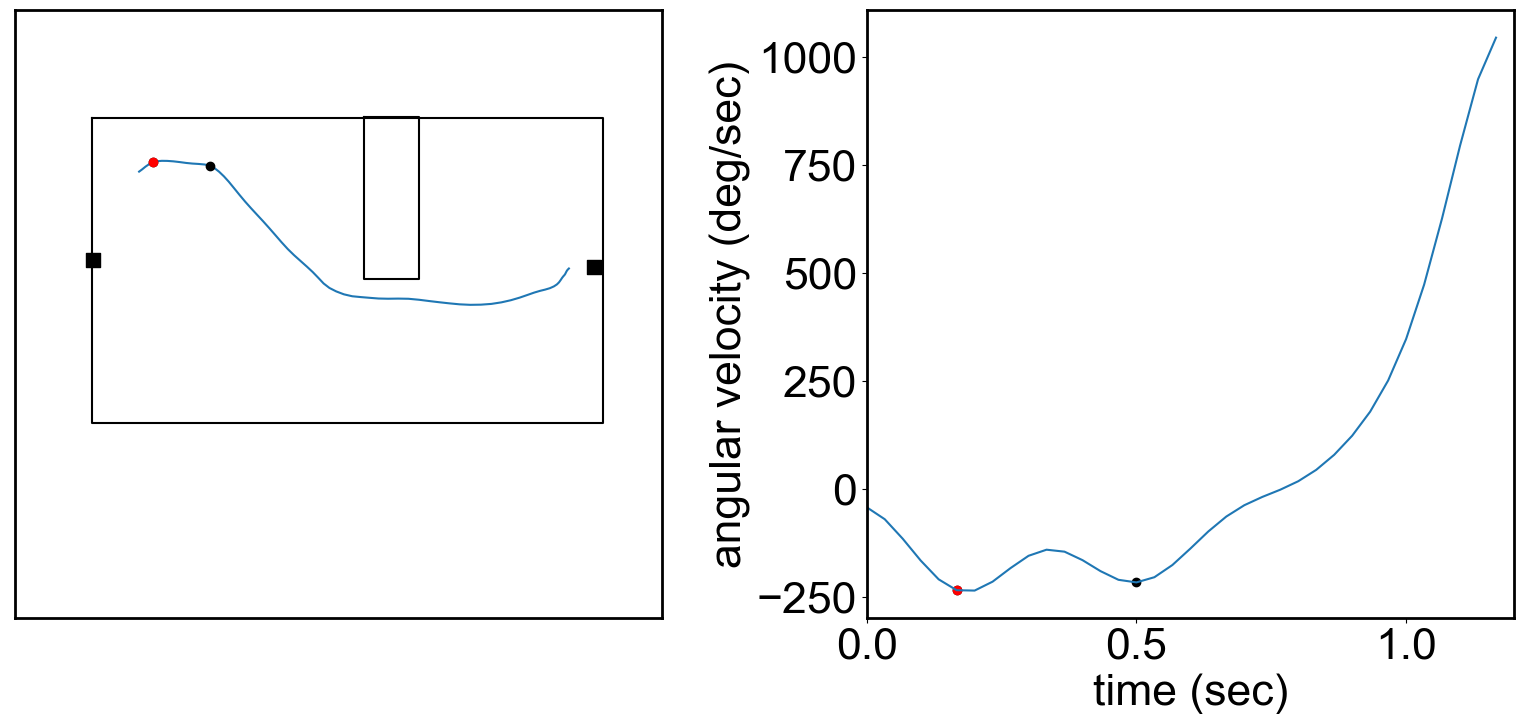

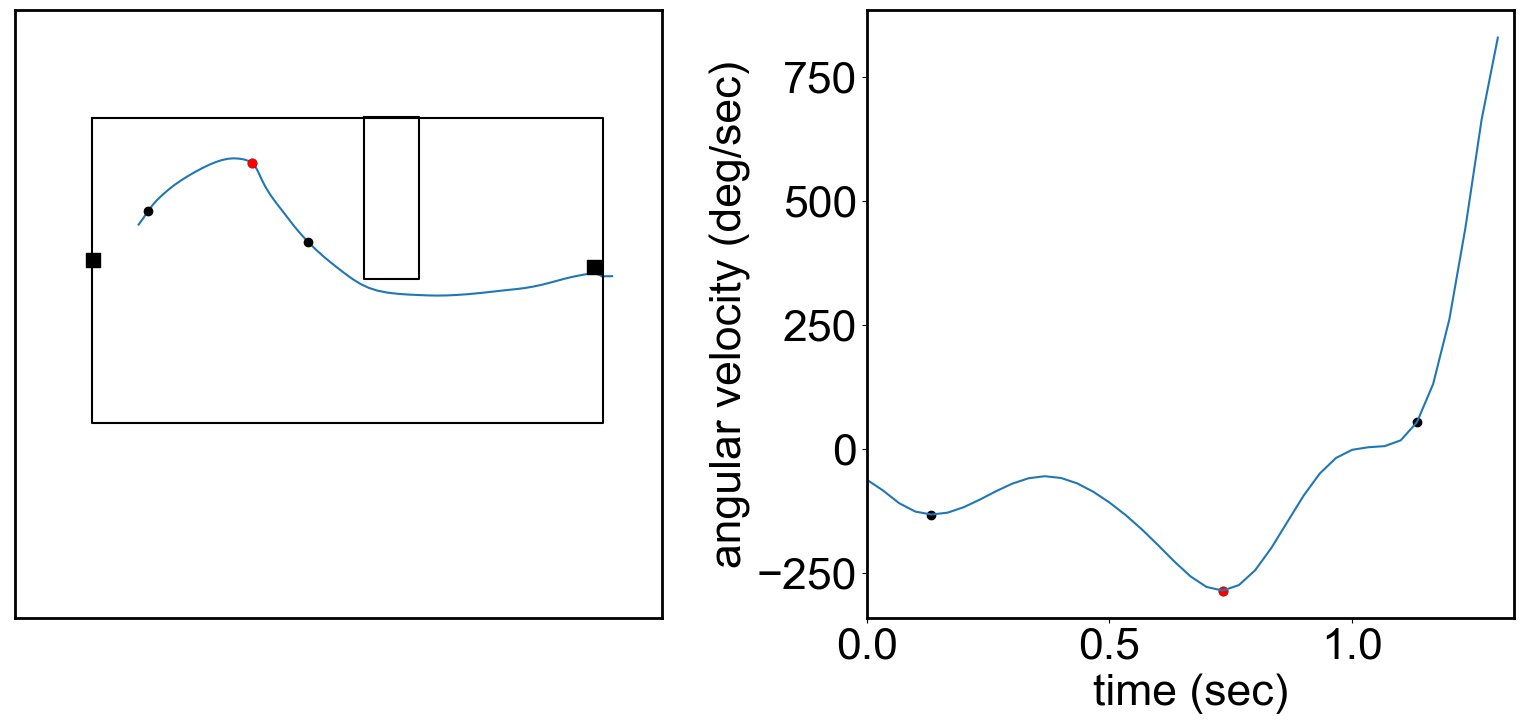

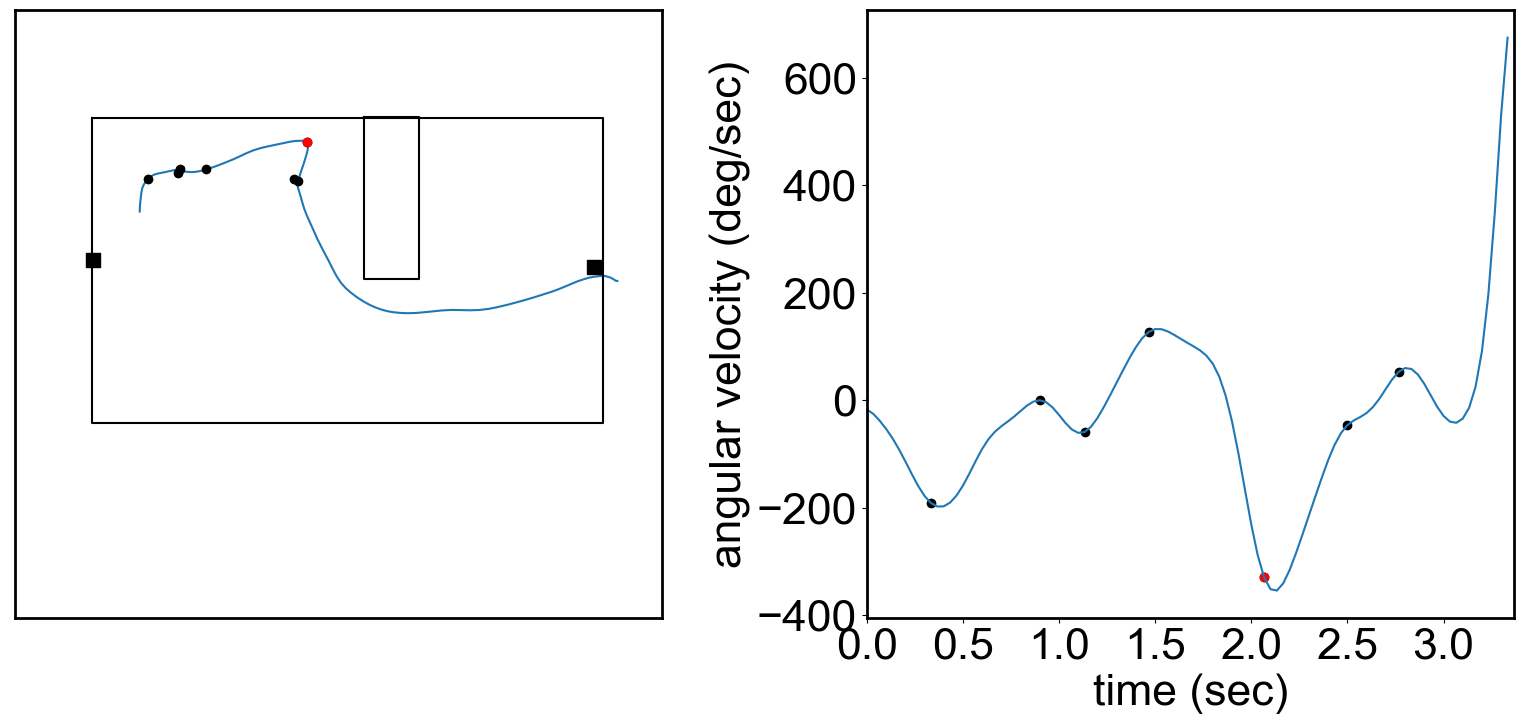

In [1177]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

sample = data.sample(20)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

# Assuming a standard frame rate (change this to your actual frame rate if different)
frame_rate = 30  # frames per second

for ind, row in sample.iterrows():
    fig, ax = plt.subplots(1, 2, figsize=(16, 8), layout='tight')
    
    # First subplot (trajectory)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    plot_arena(data, ax[0])
    plot_orginal_obstacle(data, ax[0], int(row.obstacle_cluster))
    
    # Second subplot (angular velocity)
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('time (sec)')
    
    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
        neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
        
        # Plot trajectory in first subplot
        ax[0].plot(smooth(neck_x), smooth(neck_y), color='tab:blue', zorder = 0)
        ax[0].scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
        ax[0].scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
        #ax[0].scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')
        
        # Convert frames to seconds for x-axis
        frames = np.arange(len(row.head_corner_angle_velocity[:ob_ind]))
        time_seconds = frames / frame_rate
        
        # Plot angular velocity in second subplot with time in seconds
        ax[1].plot(time_seconds, smooth(row.head_corner_angle_velocity[:ob_ind])*60, color='tab:blue')
        
        # Convert peak and threshold indices to seconds
        peak_times = np.array(peaks) / frame_rate
        thresh_time = thresh / frame_rate
        
        ax[1].scatter(peak_times, smooth(row.head_corner_angle_velocity)[peaks]*60, color='black')
        ax[1].scatter([thresh_time], smooth(row.head_corner_angle_velocity)[thresh]*60, color='red')
        
        # Set reasonable x-axis ticks in seconds
        max_time = len(row.head_corner_angle_velocity[:ob_ind]) / frame_rate
        ax[1].set_xticks(np.arange(0, max_time + 0.5, 0.5))  # Ticks every 0.5 seconds
        ax[1].set_xlim(0, max_time)

plt.show()

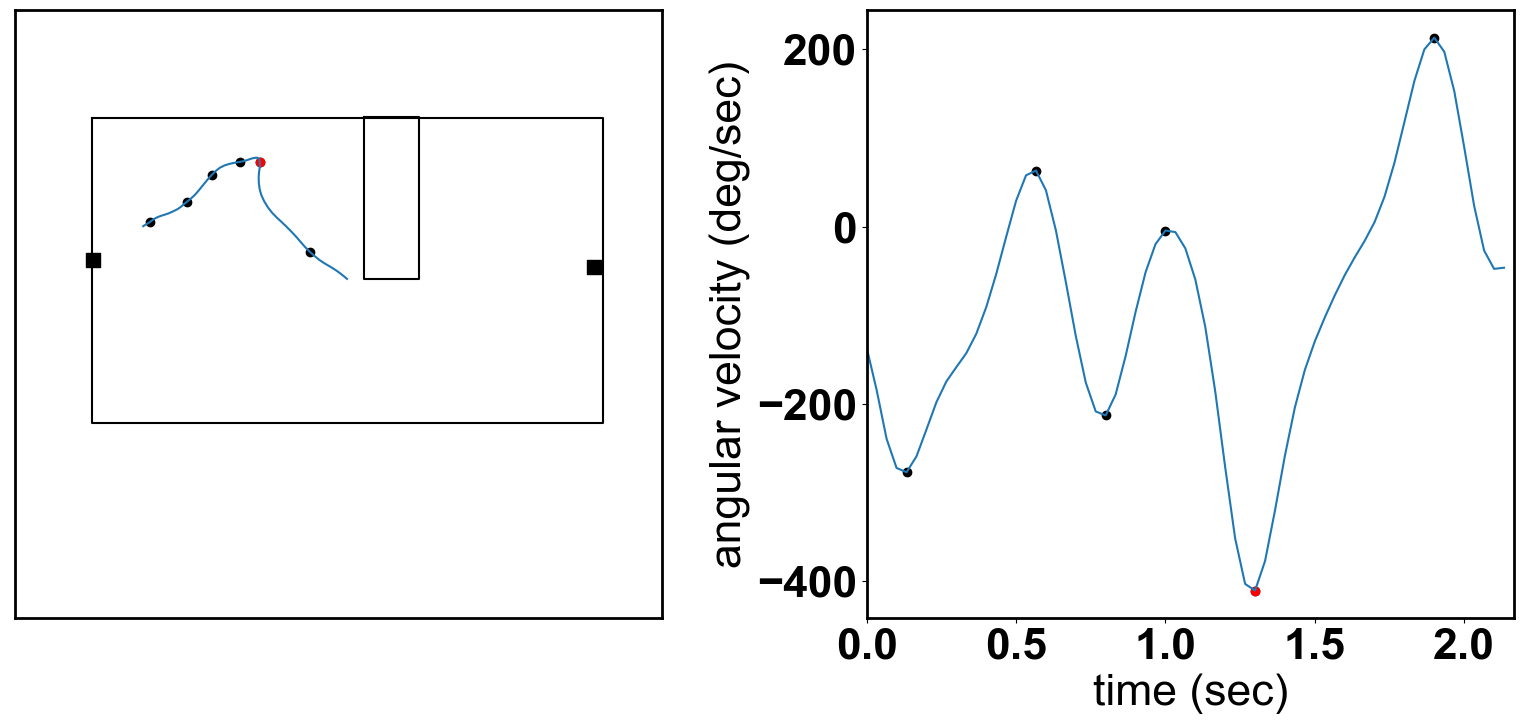

In [682]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

# Assuming a standard frame rate (change this to your actual frame rate if different)
frame_rate = 30  # frames per second

for ind, row in sample.iterrows():
    fig, ax = plt.subplots(1, 2, figsize=(16, 8), layout='tight')
    
    # First subplot (trajectory)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    plot_arena(data, ax[0])
    plot_orginal_obstacle(data, ax[0], int(row.obstacle_cluster))
    
    # Second subplot (angular velocity)
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('time (sec)')
    
    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
        neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
        
        # Plot trajectory in first subplot
        ax[0].plot(smooth(neck_x[:ob_ind]), smooth(neck_y[:ob_ind]), color='tab:blue')
        ax[0].scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
        ax[0].scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
        #ax[0].scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')
        
        # Convert frames to seconds for x-axis
        frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
        time_seconds = frames / frame_rate
        
        # Plot angular velocity in second subplot with time in seconds
        ax[1].plot(time_seconds, smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:blue')
        
        # Convert peak and threshold indices to seconds
        peak_times = np.array(peaks) / frame_rate
        thresh_time = thresh / frame_rate
        
        ax[1].scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax[1].scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')
        
        # Set reasonable x-axis ticks in seconds
        max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
        ax[1].set_xticks(np.arange(0, max_time + 0.5, 0.5))  # Ticks every 0.5 seconds
        ax[1].set_xlim(0, max_time)

plt.show()

meta NOT subset; don't know how to subset; dropped


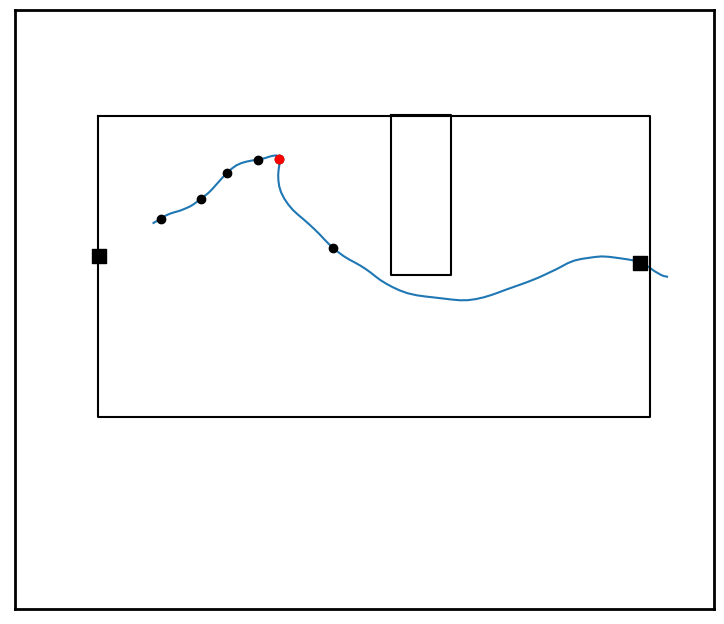

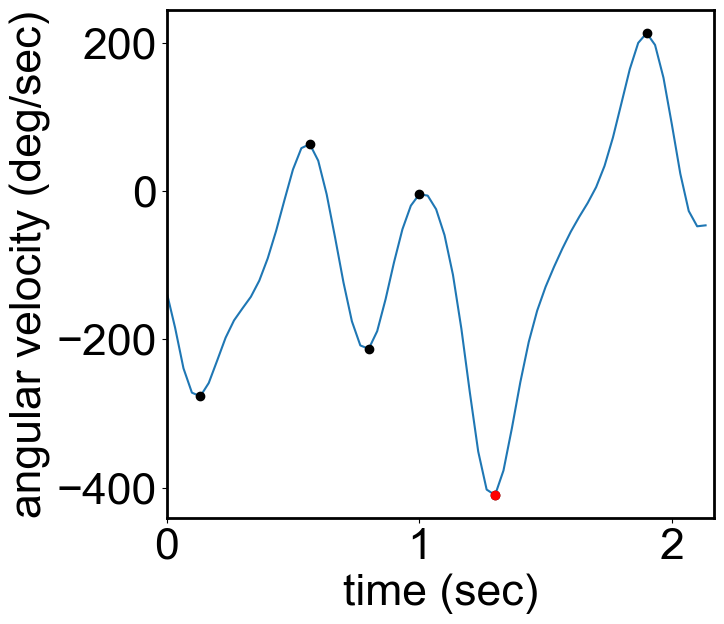

In [688]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
plt.rcParams['font.weight'] = 'normal'  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('time (sec)')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
        neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
        
        # Plot trajectory in first subplot
        ax1.plot(smooth(neck_x), smooth(neck_y), color='tab:blue', zorder = 0)
        ax1.scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
        ax1.scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
        #ax1.scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')
        
        # Plot on second figure
        # Convert frames to seconds for x-axis
        frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
        time_seconds = frames / frame_rate

        # Plot angular velocity in second subplot with time in seconds
        ax2.plot(time_seconds, smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:blue',zorder = 0)

        # Convert peak and threshold indices to seconds
        peak_times = np.array(peaks) / frame_rate
        thresh_time = thresh / frame_rate

        ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

        # Set reasonable x-axis ticks in seconds
        max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
        ax2.set_xticks(np.arange(0, max_time + 1, 1))  # Ticks every 0.5 seconds
        ax2.set_xlim(0, max_time )

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_light_headturn_trace.pdf",dpi = 300, transparent=True)
fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_light_angular_velocity_trace.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped


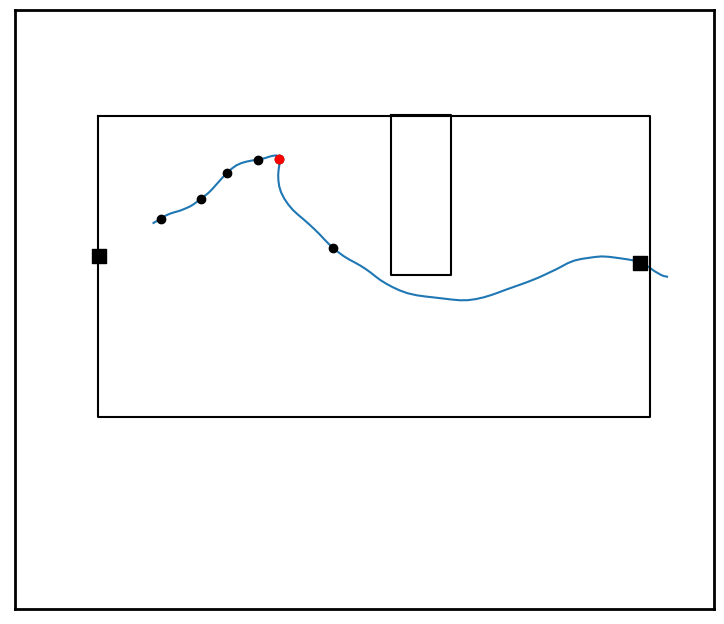

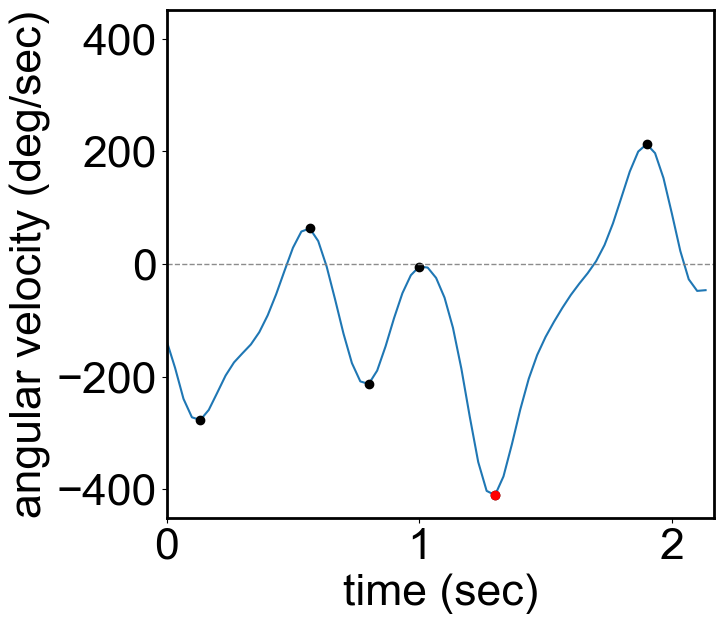

In [1000]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
plt.rcParams['font.weight'] = 'normal'  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('time (sec)')

    trial_df = data.loc[[ind]]
    
for ind, row in trial_df.iterrows():
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.head_turn_indexs.tolist()
    neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
    neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
    
    # Plot trajectory in first subplot
    ax1.plot(smooth(neck_x), smooth(neck_y), color='tab:blue', zorder = 0)
    ax1.scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
    ax1.scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
    #ax1.scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')

    # Plot on second figure
    frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
    time_seconds = frames / frame_rate

    # Smooth angular velocity and convert to deg/sec
    smoothed_velocity = smooth(row.head_angle_velocity[:ob_ind]) * 60

    # Plot angular velocity
    ax2.plot(time_seconds, smoothed_velocity, color='tab:blue', zorder=0)

    # Find max absolute value for symmetric y-limits
    max_abs_velocity = np.max(np.abs(smoothed_velocity))
    y_padding = max_abs_velocity * 0.1  # Add 10% padding for better visualization
    ax2.set_ylim(-max_abs_velocity - y_padding, max_abs_velocity + y_padding)

    # Mark peaks and threshold
    peak_times = np.array(peaks) / frame_rate
    thresh_time = thresh / frame_rate

    ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
    ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

    # Add a horizontal line at y=0 for reference
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.9)

    # Set x-axis ticks and limits
    max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
    ax2.set_xticks(np.arange(0, max_time + 1, 1))
    ax2.set_xlim(0, max_time)

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_light_headturn_trace.pdf",dpi = 300, transparent=True)
fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_light_angular_velocity_trace.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped


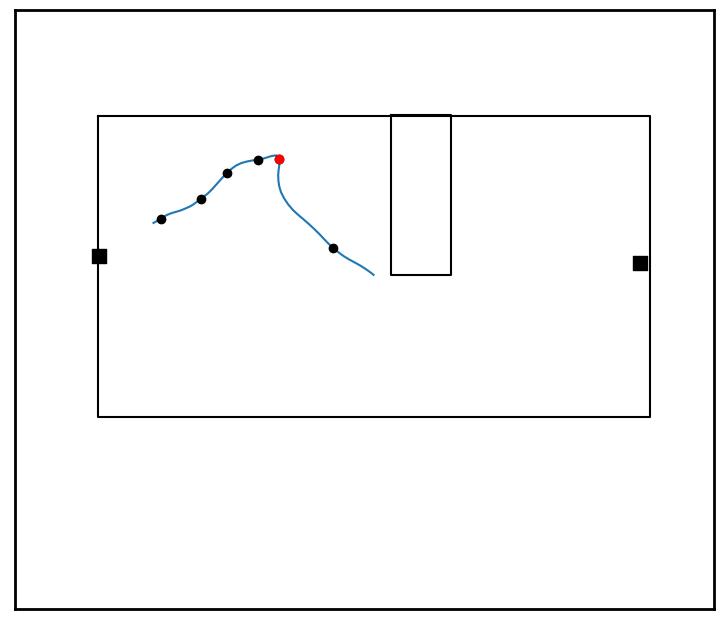

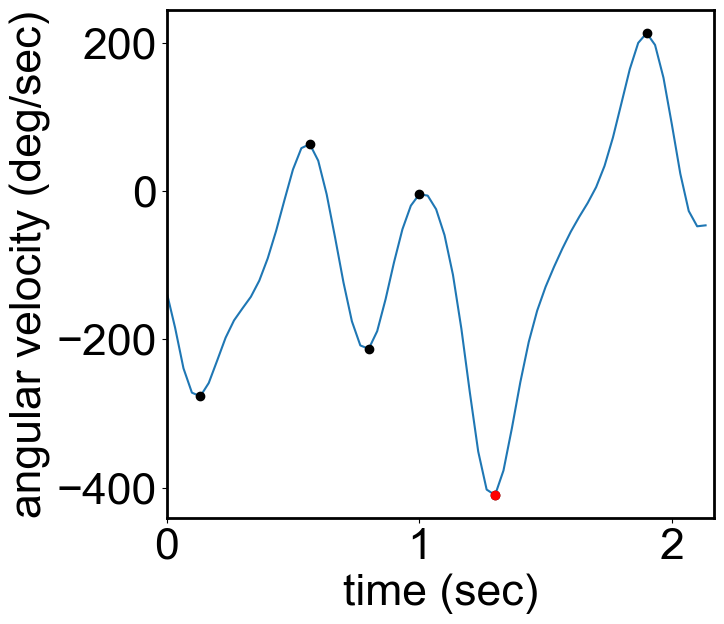

In [ ]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
plt.rcParams['font.weight'] = 'normal'  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('time (sec)')

    trial_df = data.loc[[ind]]
    
for ind, row in trial_df.iterrows():
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.head_turn_indexs.tolist()
    neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
    neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
    
    # Plot trajectory in first subplot
    ax1.plot(smooth(neck_x), smooth(neck_y), color='tab:blue', zorder = 0)
    ax1.scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
    ax1.scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
    #ax1.scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')

    # Plot on second figure
    frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
    time_seconds = frames / frame_rate

    # Smooth angular velocity and convert to deg/sec
    smoothed_velocity = smooth(row.head_angle_velocity[:ob_ind]) * 60

    # Plot angular velocity
    ax2.plot(time_seconds, smoothed_velocity, color='tab:blue', zorder=0)

    # Find max absolute value for symmetric y-limits
    max_abs_velocity = np.max(np.abs(smoothed_velocity))
    y_padding = max_abs_velocity * 0.1  # Add 10% padding for better visualization
    ax2.set_ylim(-max_abs_velocity - y_padding, max_abs_velocity + y_padding)

    # Mark peaks and threshold
    peak_times = np.array(peaks) / frame_rate
    thresh_time = thresh / frame_rate

    ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
    ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

    # Add a horizontal line at y=0 for reference
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.9)

    # Set x-axis ticks and limits
    max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
    ax2.set_xticks(np.arange(0, max_time + 1, 1))
    ax2.set_xlim(0, max_time)

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\shorten_sec_light_headturn_trace.pdf",dpi = 300, transparent=True)
fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\shorten_sec_light_angular_velocity_trace.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped


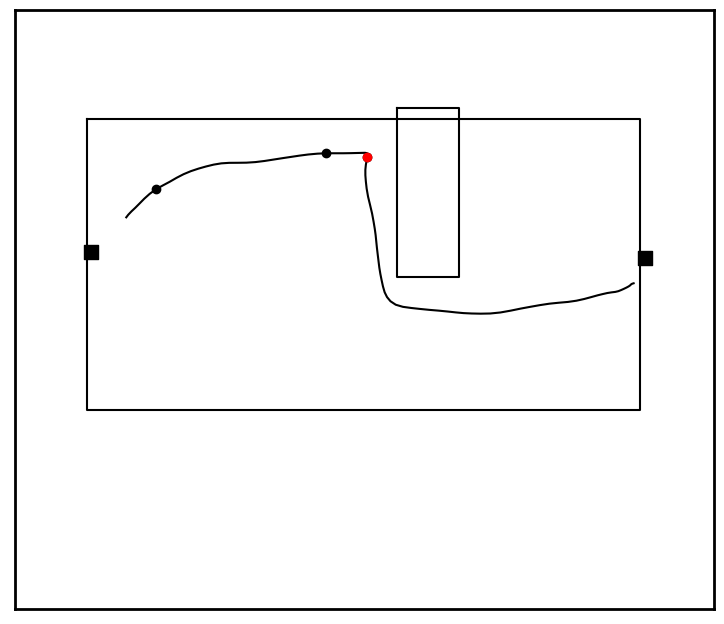

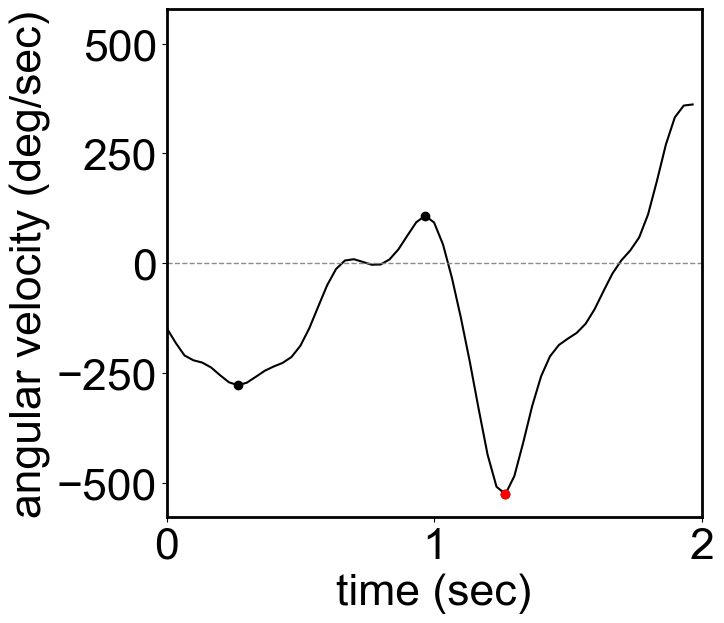

In [1062]:
data = pd.concat([light_dark])
data = data[data.task=='oadark']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
plt.rcParams['font.weight'] = 'normal'  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('time (sec)')

    trial_df = data.loc[[ind]]
    
for ind, row in trial_df.iterrows():
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.head_turn_indexs.tolist()
    neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
    neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
    
    # Plot trajectory in first subplot
    ax1.plot(smooth(neck_x), smooth(neck_y), color='black', zorder = 0)
    ax1.scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
    ax1.scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
    #ax1.scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')

    # Plot on second figure
    frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
    time_seconds = frames / frame_rate

    # Smooth angular velocity and convert to deg/sec
    smoothed_velocity = smooth(row.head_angle_velocity[:ob_ind]) * 60

    # Plot angular velocity
    ax2.plot(time_seconds, smoothed_velocity, color='black', zorder=0)

    # Find max absolute value for symmetric y-limits
    max_abs_velocity = np.max(np.abs(smoothed_velocity))
    y_padding = max_abs_velocity * 0.1  # Add 10% padding for better visualization
    ax2.set_ylim(-max_abs_velocity - y_padding, max_abs_velocity + y_padding)

    # Mark peaks and threshold
    peak_times = np.array(peaks) / frame_rate
    thresh_time = thresh / frame_rate

    ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
    ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

    # Add a horizontal line at y=0 for reference
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.9)

    # Set x-axis ticks and limits
    max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
    ax2.set_xticks(np.arange(0, max_time + 1, 1))
    ax2.set_xlim(0, max_time)

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_dark_headturn_trace.pdf",dpi = 300, transparent=True)

fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_dark_angular_velocity_trace.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped


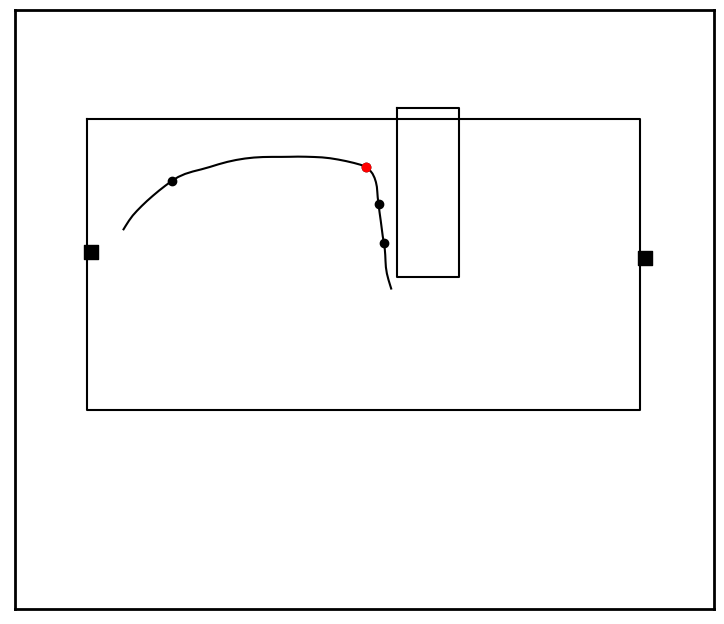

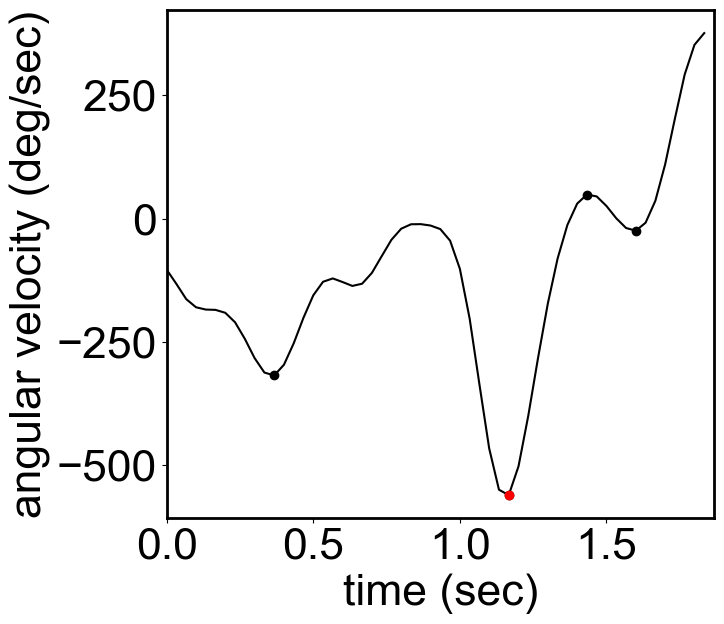

In [695]:
data = pd.concat([light_dark])
data = data[data.task=='oadark']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
plt.rcParams['font.weight'] = 'normal'  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('time (sec)')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        neck_x = np.nanmean([row.ts_rightear_x_cm,row.ts_leftear_x_cm],axis=0)
        neck_y =  np.nanmean([row.ts_rightear_y_cm,row.ts_leftear_y_cm],axis=0)
        
        # Plot trajectory in first subplot
        ax1.plot(smooth(neck_x[:ob_ind]), smooth(neck_y[:ob_ind]), color='black', zorder = 0)
        ax1.scatter(smooth(neck_x)[[x  -1 for x in peaks]], smooth(neck_y)[[x  -1 for x in peaks]], color='black')
        ax1.scatter(smooth(neck_x)[thresh-1], smooth(neck_y)[thresh-1], color='red')
        #ax1.scatter(smooth(neck_x)[thresh], smooth(neck_y)[thresh], color='orange')
        
        # Plot on second figure
        # Convert frames to seconds for x-axis
        frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
        time_seconds = frames / frame_rate

        # Plot angular velocity in second subplot with time in seconds
        ax2.plot(time_seconds, smooth(row.head_angle_velocity[:ob_ind])*60, color='black',zorder = 0)

        # Convert peak and threshold indices to seconds
        peak_times = np.array(peaks) / frame_rate
        thresh_time = thresh / frame_rate

        ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

        # Set reasonable x-axis ticks in seconds
        max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
        ax2.set_xticks(np.arange(0, max_time + 1, .5))  # Ticks every 0.5 seconds
        ax2.set_xlim(0, max_time )

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\shorten_sec_dark_headturn_trace.pdf",dpi = 300, transparent=True)

fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\shorten_sec_dark_angular_velocity_trace.pdf",dpi = 300, transparent=True)

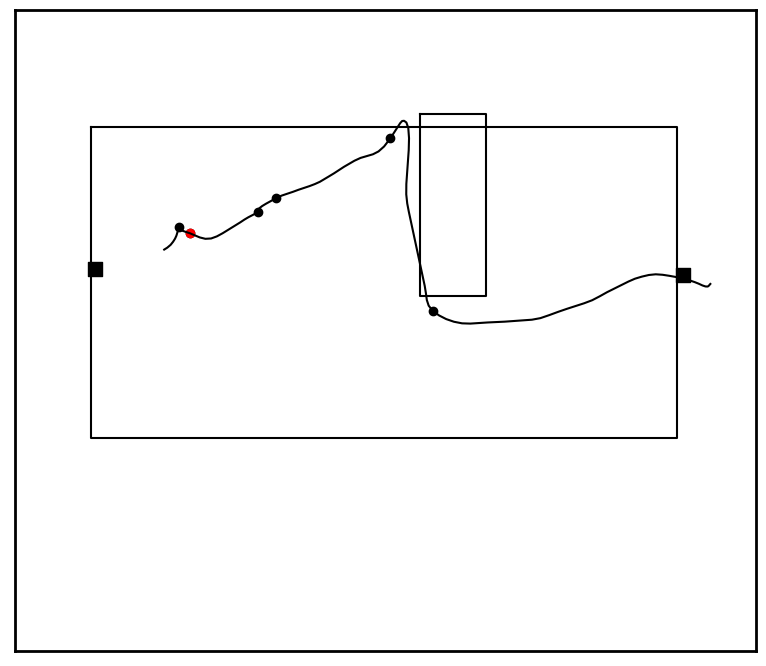

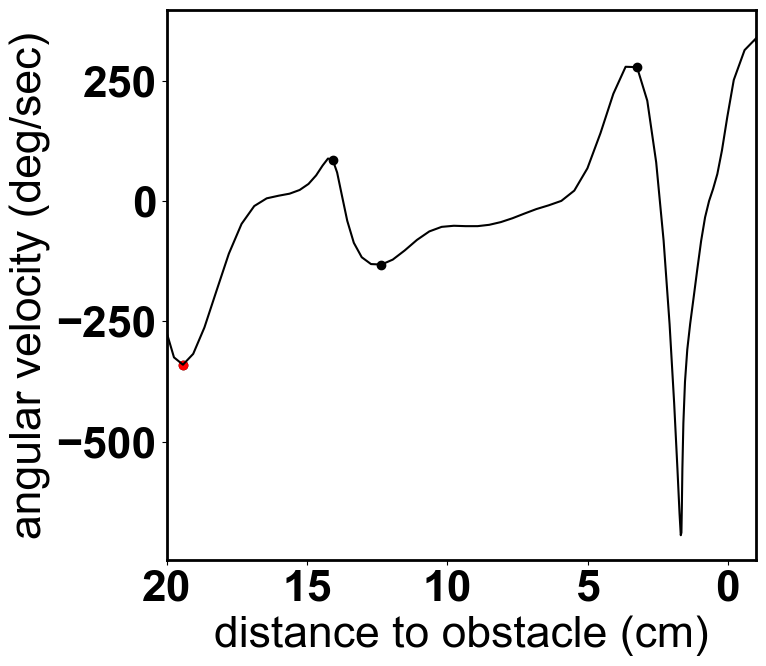

In [566]:
data = pd.concat([light_dark])
data = data[data.task=='oadark']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_yticks([-500,-250,0,250,500])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('distance to obstacle (cm)')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
       ob_ind = int(row.obstacle_ind)
       thresh = int(row.indexs_of_head_turn[1])
       peaks = row.head_turn_indexs.tolist()
        
        
       # Plot on first figure
       ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='black')
       ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
       ax1.scatter(smooth(row.ts_nose_x_cm)[thresh], smooth(row.ts_nose_y_cm)[thresh], color='red')
       
       # Plot on second figure
       ax2.plot(row.ts_distance_from_edge[:ob_ind], smooth(row.head_angle_velocity[:ob_ind])*60, color='black')
       ax2.scatter(row.ts_distance_from_edge[:ob_ind][peaks], smooth(row.head_angle_velocity)[peaks]*60, color='black')
       ax2.scatter(row.ts_distance_from_edge[:ob_ind][thresh], smooth(row.head_angle_velocity)[thresh]*60, color='red')

#fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\dark_headturn_trace.pdf",dpi = 300, transparent=True)

#fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\dark_angular_velocity_trace.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


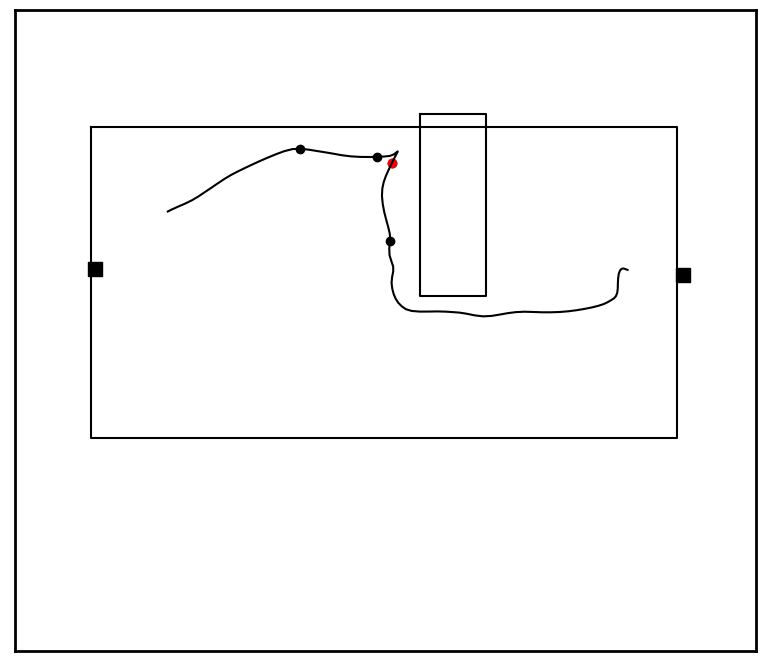

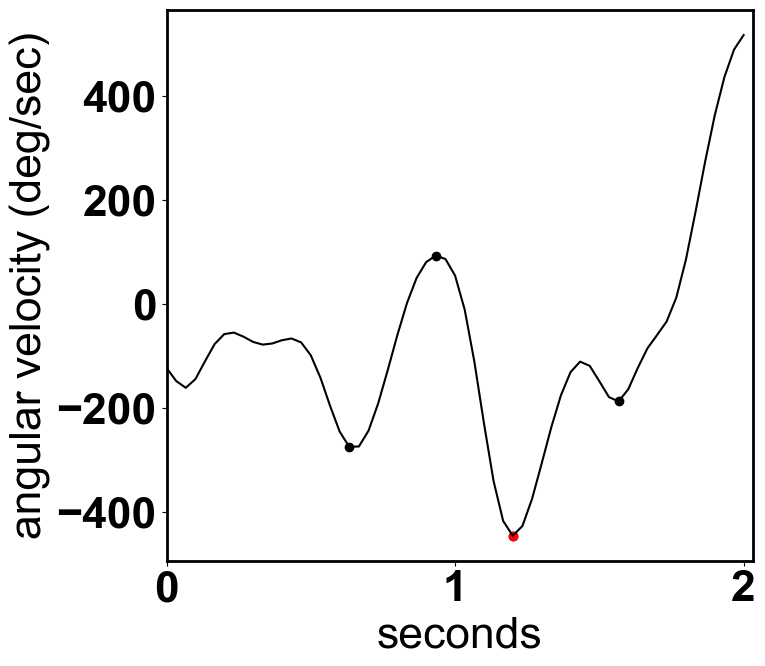

In [298]:
data = pd.concat([light_dark])
data = data[data.task=='oadark']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('seconds')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        
        # Plot on first figure
        ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='black')
        ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
        ax1.scatter(smooth(row.ts_nose_x_cm)[thresh], smooth(row.ts_nose_y_cm)[thresh], color='red')
        
        # Plot on second figure
        # Convert frames to seconds for x-axis
        frames = np.arange(len(row.head_angle_velocity[:ob_ind]))
        time_seconds = frames / frame_rate

        # Plot angular velocity in second subplot with time in seconds
        ax2.plot(time_seconds, smooth(row.head_angle_velocity[:ob_ind])*60, color='black')

        # Convert peak and threshold indices to seconds
        peak_times = np.array(peaks) / frame_rate
        thresh_time = thresh / frame_rate

        ax2.scatter(peak_times, smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax2.scatter([thresh_time], smooth(row.head_angle_velocity)[thresh]*60, color='red')

        # Set reasonable x-axis ticks in seconds
        max_time = len(row.head_angle_velocity[:ob_ind]) / frame_rate
        ax2.set_xticks(np.arange(0, max_time + 1, 1))  # Ticks every 0.5 seconds
        ax2.set_xlim(0, max_time )
fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_dark_headturn_trace.pdf",dpi = 300, transparent=True)

fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\sec_dark_angular_velocity_trace.pdf",dpi = 300, transparent=True)

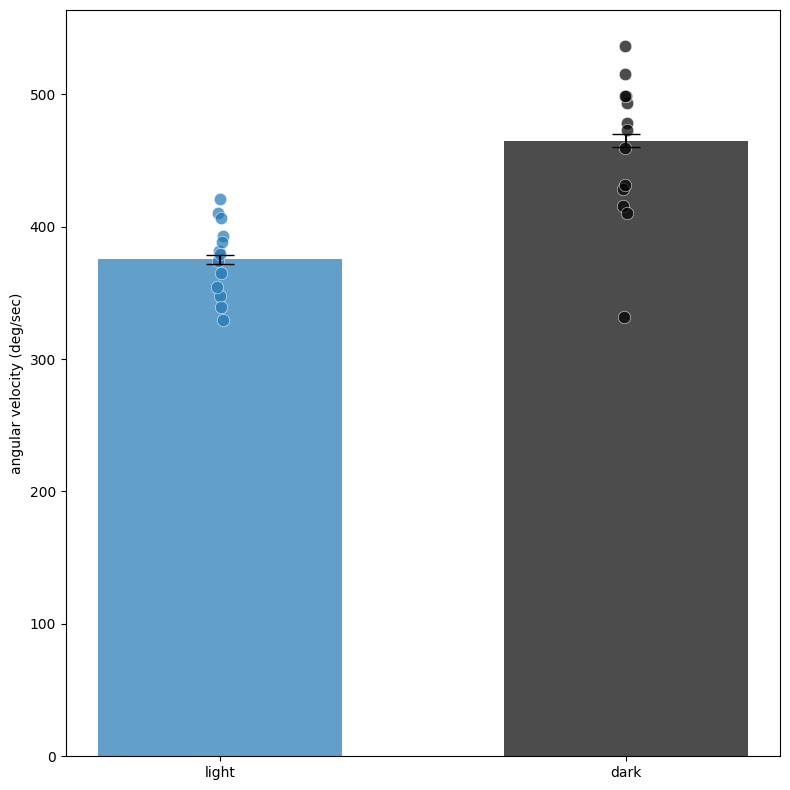

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 
#data = data[data.head_turn_velocity<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['head_turn_velocity'].median()*60
light_se = light_data['head_turn_velocity'].sem()*60
dark_median = dark_data['head_turn_velocity'].median()*60
dark_se = dark_data['head_turn_velocity'].sem()*60

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angular velocity (deg/sec)')

plt.tight_layout()
plt.show()

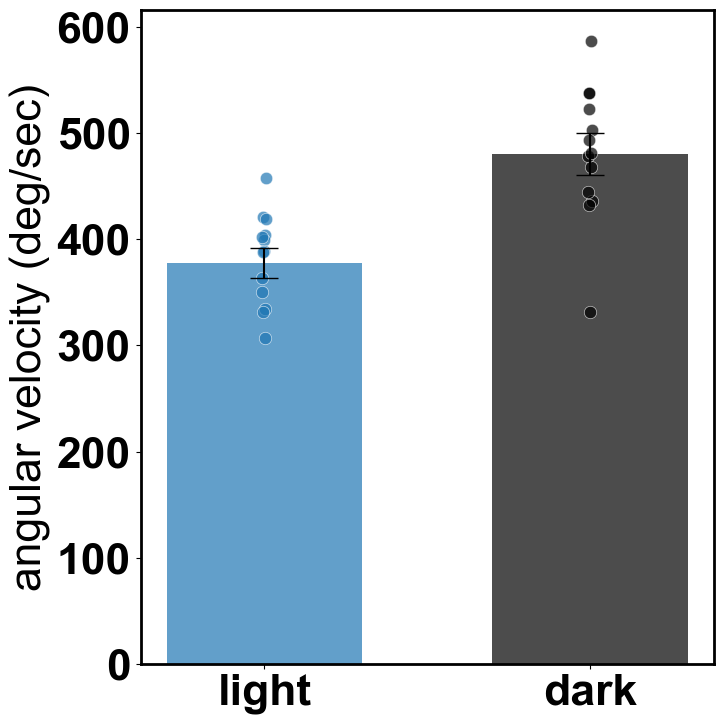

In [455]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 
#data = data[data.head_turn_velocity<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['head_turn_velocity'].median()*60
light_se = light_data['head_turn_velocity'].sem()*60
dark_median = dark_data['head_turn_velocity'].median()*60
dark_se = dark_data['head_turn_velocity'].sem()*60

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angular velocity (deg/sec)')

plt.tight_layout()
plt.show()

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\headturn_velocity.pdf",dpi = 300, transparent=True)

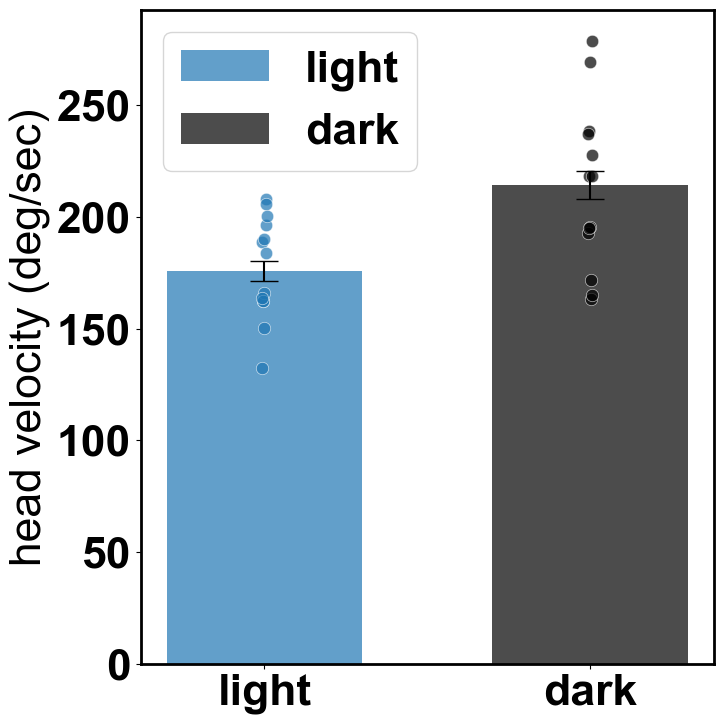

In [456]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Separate light and dark conditions
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Function to process head_turn_velocities
def process_velocities(df):
    # Flatten the array of arrays and convert to deg/sec
    all_velocities = flatten_list_of_arrays(df.head_turn_velocities.to_numpy()) * 60
    # Filter valid velocities (positive values)
    return np.array([v for v in all_velocities if v >= 0])

# Get all velocities for each condition
light_velocities = process_velocities(light_data)
dark_velocities = process_velocities(dark_data)

# Calculate median and SEM for each condition
light_median = np.median(light_velocities)
light_se = np.std(light_velocities) / np.sqrt(len(light_velocities))
dark_median = np.median(dark_velocities)
dark_se = np.std(dark_velocities) / np.sqrt(len(dark_velocities))

# Calculate animal-level medians for jitter points
def get_animal_medians(df):
    animal_medians = []
    for animal in df['animal'].unique():
        animal_df = df[df['animal'] == animal]
        velocities = process_velocities(animal_df)
        if len(velocities) > 0:
            animal_medians.append(np.median(velocities))
    return animal_medians

light_animal_medians = get_animal_medians(light_data)
dark_animal_medians = get_animal_medians(dark_data)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
       alpha=0.7, capsize=10, width=0.6, label='dark')

# Jitter settings
jitter_width = 0.008   # Adjust as needed

# Add individual animal points for light condition
for i, median in enumerate(light_animal_medians):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, median, color='tab:blue', s=80, 
               alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition
for i, median in enumerate(dark_animal_medians):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, median, color='black', s=80, 
               alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
ax.set_ylabel('head velocity (deg/sec)')


# Add legend
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
light_dist = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())

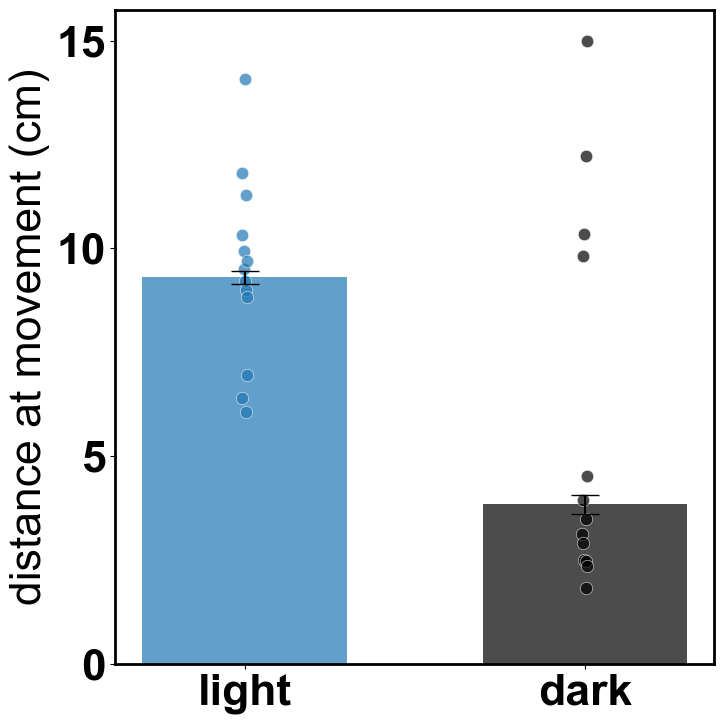

In [457]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
#data = data[data.distance_at_head_turn<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['distance_at_head_turn'].median()
light_se = light_data['distance_at_head_turn'].sem()
dark_median = dark_data['distance_at_head_turn'].median()
dark_se = dark_data['distance_at_head_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['distance_at_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['distance_at_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])

ax.set_yticks([0,5,10,15])
ax.set_ylabel('distance at movement (cm)')

plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\distance_at_headturn_trace.pdf",dpi = 300, transparent=True)

In [404]:
obstacle_ind = int(row.obstacle_ind)
vel = row.head_angle_velocity[:obstacle_ind]
pos_peaks, pos_props = find_peaks(vel, width=3,distance=3,prominence=1)
neg_peaks, neg_props = find_peaks(-vel, width=3,distance=3,prominence=1)

In [403]:
pos_peaks

array([19, 36, 45], dtype=int64)

In [405]:
neg_peaks

array([ 6, 31, 40, 49], dtype=int64)

In [729]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

def head_turn_calcs(df):
    for ind, row in df.iterrows():
        obstacle_ind = int(row.obstacle_ind)
        vel = row.head_angle_velocity[:obstacle_ind]
        
        # Detect positive and negative peaks separately
        pos_peaks, pos_props = find_peaks(vel, width=3,prominence=1,height=0)
        neg_peaks, neg_props = find_peaks(-vel, width=3,prominence=1,height=0)
        
        # Store positive peaks info
        pos_heights = pos_props['peak_heights'] if len(pos_peaks) > 0 else np.array([])
        pos_left_ips = pos_props['left_ips'] if len(pos_peaks) > 0 else np.array([])
        pos_right_ips = pos_props['right_ips'] if len(pos_peaks) > 0 else np.array([])
        
        # Store negative peaks info (convert heights back to negative values)
        neg_heights = -neg_props['peak_heights'] if len(neg_peaks) > 0 else np.array([])
        neg_left_ips = neg_props['left_ips'] if len(neg_peaks) > 0 else np.array([])
        neg_right_ips = neg_props['right_ips'] if len(neg_peaks) > 0 else np.array([])
        
        # Combine all peaks for main peak selection
        all_peaks = np.concatenate([pos_peaks, neg_peaks])
        all_heights = np.concatenate([pos_heights, neg_heights])
        
        # NEW: Calculate large head movements (absolute velocity > 3)
        if len(all_peaks) > 0:
            abs_heights = np.abs(all_heights)
            large_turn_mask = abs_heights > 3
            large_turn_indexs = all_peaks[large_turn_mask]
            large_turn_velocities = all_heights[large_turn_mask]
        else:
            large_turn_indexs = np.array([])
            large_turn_velocities = np.array([])
        
        if len(all_peaks) > 0:
            # Find main peak (max absolute velocity)
            max_abs_idx = np.argmax(np.abs(all_heights))
            main_peak = all_peaks[max_abs_idx]
            main_height = all_heights[max_abs_idx]
            
            # Determine if main peak is positive or negative
            if main_peak in pos_peaks:
                pos_idx = np.where(pos_peaks == main_peak)[0][0]
                main_left_ip = pos_left_ips[pos_idx]
                main_right_ip = pos_right_ips[pos_idx]
            else:
                neg_idx = np.where(neg_peaks == main_peak)[0][0]
                main_left_ip = neg_left_ips[neg_idx]
                main_right_ip = neg_right_ips[neg_idx]
                
            start_movement = int(np.round(main_left_ip))
            end_movement = int(np.round(main_right_ip))
            
            # Store main peak values
            df.at[ind, 'distance_at_head_turn'] = row.ts_distance_from_edge[main_peak]
            df.at[ind, 'distance_after_head_turn'] = row.ts_distance_from_edge[end_movement]
            df.at[ind, 'distance_before_head_turn'] = row.ts_distance_from_edge[start_movement]
            df.at[ind, 'indexs_of_head_turn'] = np.array([start_movement, main_peak, end_movement]).astype(object)
            df.at[ind, 'angle_at_head_turn'] = row.ts_angle_to_corner[main_peak]
            df.at[ind, 'angle_after_head_turn'] = row.ts_angle_to_corner[end_movement]
            df.at[ind, 'angle_before_head_turn'] = row.ts_angle_to_corner[start_movement]
            df.at[ind, 'head_turn_velocity'] = main_height
            df.at[ind, 'num_turn'] = len(all_peaks)
            
            # Store all peaks information (combined)
            df.at[ind, 'head_turn_indexs'] = all_peaks.astype(object)
            df.at[ind, 'head_turn_velocities'] = all_heights.astype(object)
            
            # NEW: Store large head movements information
            df.at[ind, 'large_head_turn_indexs'] = large_turn_indexs.astype(object)
            df.at[ind, 'large_head_turn_velocities'] = large_turn_velocities.astype(object)
            
            # Store separate positive/negative peaks information
            df.at[ind, 'positive_peaks'] = pos_peaks.astype(object)
            df.at[ind, 'positive_heights'] = pos_heights.astype(object)
            df.at[ind, 'positive_left_ips'] = pos_left_ips.astype(object)
            df.at[ind, 'positive_right_ips'] = pos_right_ips.astype(object)
            
            df.at[ind, 'negative_peaks'] = neg_peaks.astype(object)
            df.at[ind, 'negative_heights'] = neg_heights.astype(object)
            df.at[ind, 'negative_left_ips'] = neg_left_ips.astype(object)
            df.at[ind, 'negative_right_ips'] = neg_right_ips.astype(object)
            
            # Store non-main peaks information
            non_main_peaks = np.delete(all_peaks, max_abs_idx)
            if len(non_main_peaks) > 0:
                df.at[ind, 'angles_at_head_turns'] = row.ts_angle_to_corner[non_main_peaks].astype(object)
                df.at[ind, 'distances_at_head_turns'] = row.ts_distance_from_edge[non_main_peaks].astype(object)
                
                # Find end indices for non-main peaks
                non_main_ends = []
                for peak in non_main_peaks:
                    if peak in pos_peaks:
                        idx = np.where(pos_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(pos_right_ips[idx])))
                    else:
                        idx = np.where(neg_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(neg_right_ips[idx])))
                df.at[ind, 'angles_at_head_turns_ends'] = row.ts_angle_to_corner[non_main_ends].astype(object)
            else:
                df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
        else:
            # Handle case with no peaks found
            df.at[ind, 'distance_at_head_turn'] = np.nan
            df.at[ind, 'distance_after_head_turn'] = np.nan
            df.at[ind, 'distance_before_head_turn'] = np.nan
            df.at[ind, 'indexs_of_head_turn'] = np.array([np.nan])
            df.at[ind, 'head_turn_indexs'] = np.array([np.nan])
            df.at[ind, 'angle_at_head_turn'] = np.nan
            df.at[ind, 'angle_after_head_turn'] = np.nan
            df.at[ind, 'angle_before_head_turn'] = np.nan
            df.at[ind, 'num_turn'] = 0
            df.at[ind, 'head_turn_velocity'] = np.nan
            df.at[ind, 'head_turn_velocities'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
            df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
            
            # NEW: Empty arrays for large head movements
            df.at[ind, 'large_head_turn_indexs'] = np.array([]).astype(object)
            df.at[ind, 'large_head_turn_velocities'] = np.array([]).astype(object)
            
            # Empty arrays for positive/negative peaks
            df.at[ind, 'positive_peaks'] = np.array([]).astype(object)
            df.at[ind, 'positive_heights'] = np.array([]).astype(object)
            df.at[ind, 'positive_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'positive_right_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_peaks'] = np.array([]).astype(object)
            df.at[ind, 'negative_heights'] = np.array([]).astype(object)
            df.at[ind, 'negative_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_right_ips'] = np.array([]).astype(object)
    
    return df

In [730]:
head_turn_calcs(light_dark)


,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,large_head_turn_indexs,large_head_turn_velocities,positive_peaks,positive_heights,positive_left_ips,positive_right_ips,negative_peaks,negative_heights,negative_left_ips,negative_right_ips
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[9, 87, 29, 51, 80, 150]","[3.467894526684183, 70.76484211201341, -3.5383...","[9, 87, 117]","[3.467894526684183, 70.76484211201341, 0.87842...","[4.348496372157843, 84.57520408092827, 111.802...","[16.19392975054704, 89.74667185224443, 138.917...","[29, 51, 80, 101, 109, 150]","[-3.538385458538178, -6.072763103973279, -15.5...","[25.905246144139266, 47.32339025628978, 75.456...","[32.12845040781993, 54.57613982891745, 82.6354..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[18, 41, 187, 197, 163]","[6.900105355577886, 3.2853130494794236, 7.1115...","[18, 41, 59, 68, 80, 112, 155, 187, 197]","[6.900105355577886, 3.2853130494794236, 0.4219...","[14.29968179236998, 34.45417430857124, 56.8175...","[21.134328939577735, 47.497331594384946, 60.99...","[27, 54, 63, 72, 96, 142, 163]","[-1.084529998922007, -1.007367450928327, -1.23...","[23.633723715468523, 51.22741380863773, 60.626...","[34.45417430857124, 56.81754859503331, 65.6960..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,"[123, 105]","[5.169556264047671, -5.381416681158556]","[45, 79, 123]","[1.6242393845730319, 0.40463929208811134, 5.16...","[41.41521186946102, 75.05998884876111, 121.202...","[47.47076883555107, 100.83250327208884, 124.89...","[60, 73, 105]","[-2.770484234614008, -2.029725669811883, -5.38...","[49.027626511169174, 70.0490124411182, 101.532...","[63.70320204647564, 75.23238818008673, 109.858..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[32, 57, 172, 69, 182]","[4.847588182779208, 27.177322177033663, 4.4365...","[5, 32, 57, 136, 172]","[0.607569965280006, 4.847588182779208, 27.1773...","[3.312465447674962, 27.244918924558764, 53.311...","[7.222653906163416, 39.43742784770508, 60.3740...","[11, 45, 69, 141, 182]","[-2.5443679094536087, -1.326131825354483, -3.6...","[8.573024614211446, 39.43742784770508, 63.7155...","[14.41270127641714, 47.64617801007571, 143.401..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.

In [8]:
# For evenly spaced jitter
def even_jitter(n, amount=0.1):
    return np.linspace(-amount, amount, n)

# Light condition points
light_animals = light_data['animal'].unique()
for i, animal in enumerate(light_animals):
    animal_dist = light_data[light_data['animal'] == animal]['distance_at_head_turn'].median()
    jitter = even_jitter(len(light_animals))[i]
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7)

# Dark condition points
dark_animals = dark_data['animal'].unique()
for i, animal in enumerate(dark_animals):
    animal_dist = dark_data[dark_data['animal'] == animal]['distance_at_head_turn'].median()
    jitter = even_jitter(len(dark_animals))[i]
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7)

NameError: name 'light_data' is not defined

In [19]:
dark_data.animal.unique()

array(['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

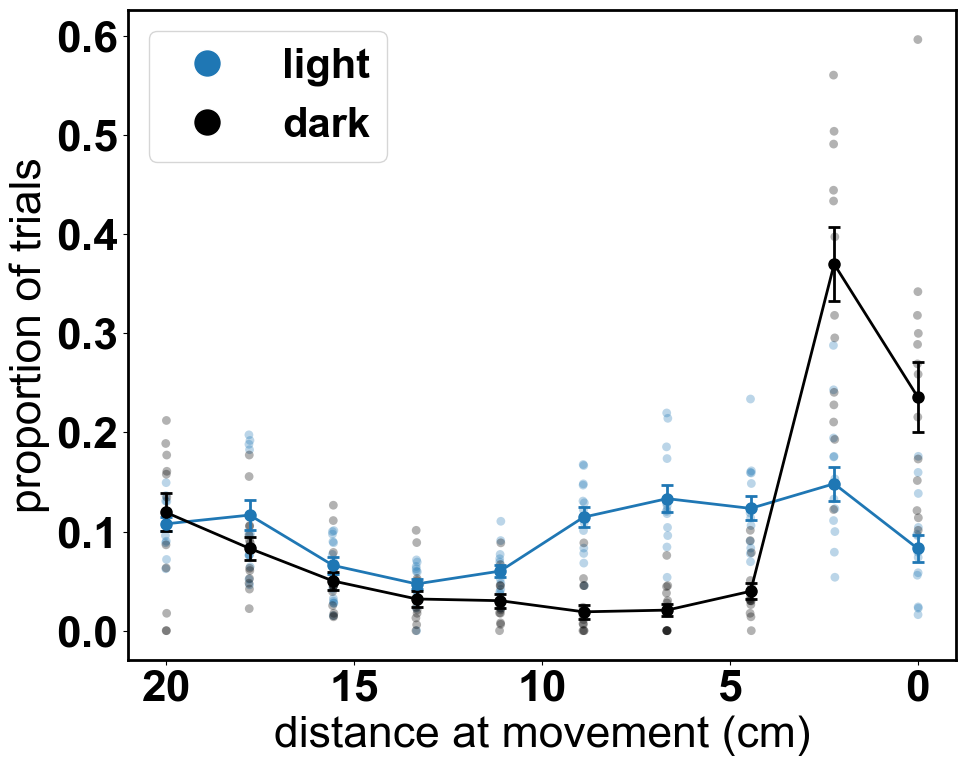

<Figure size 640x480 with 0 Axes>

In [458]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=20]
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
#data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,20))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at movement (cm)', fontweight='normal')     # Not bold
ax.invert_xaxis()

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

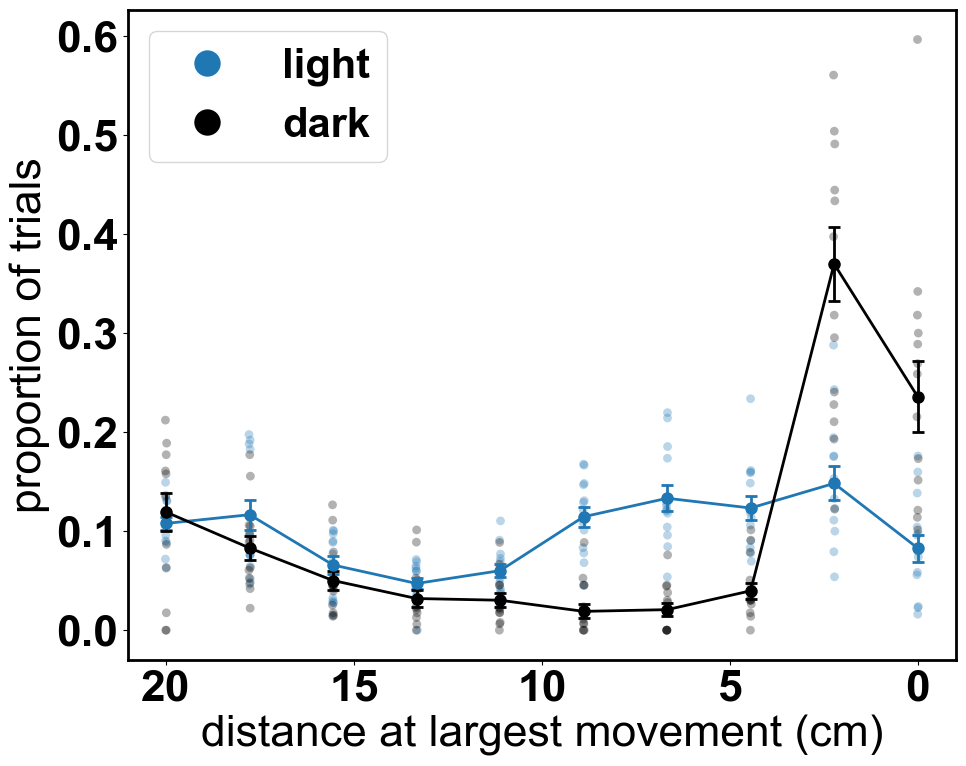

<Figure size 640x480 with 0 Axes>

In [459]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=20]
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
#data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,20))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at largest movement (cm)', fontweight='normal')     # Not bold
ax.invert_xaxis()

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\hist_distance_at_headturn_trace.pdf",dpi = 300, transparent=True)

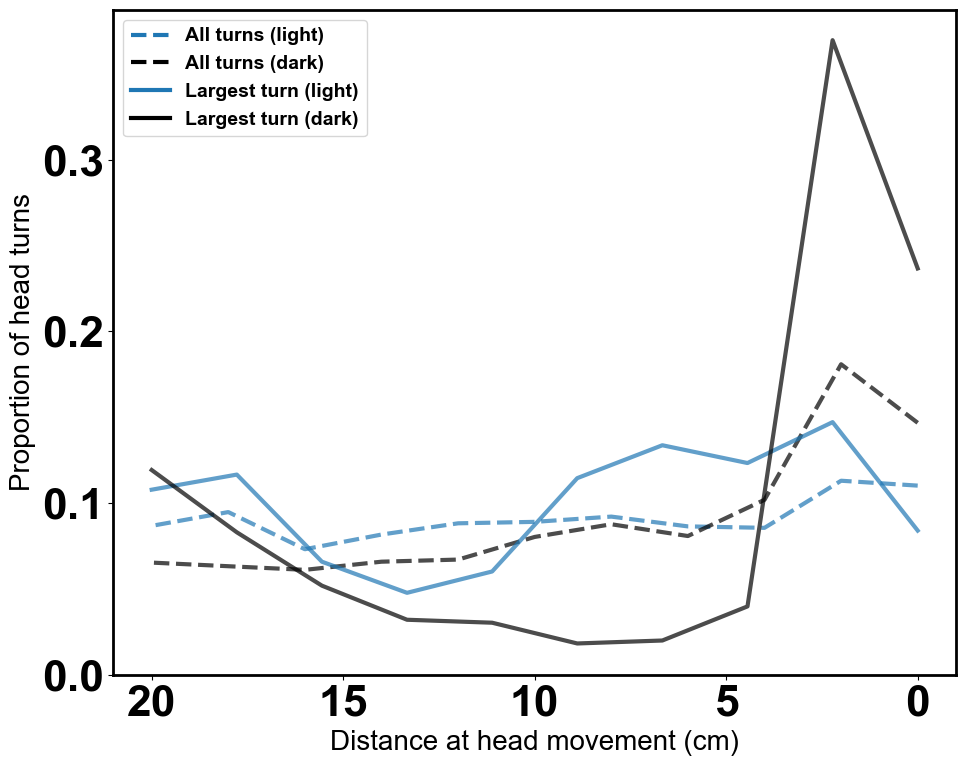

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Common parameters
xnew = np.arange(0, 21, 2)
xnew2 = np.linspace(0, 20, 10)

# Data processing for all head turns (first plot)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  

# Process all head turns - light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=len(xnew))
light_hist = (light_counts / sum(light_counts))

# Process all head turns - dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew))
dark_hist = (dark_counts / sum(dark_counts))

# Data processing for largest head turns (second plot)
data2 = pd.concat([light_dark])
data2 = drop_nans_in_columns(data2, 'obstacle_ind')
data2 = data2[~data2['obstacle_cluster'].isin([2,3])] 
data2 = data2[data2.intial_distance>=15] 
data2 = data2[data2.intial_lateral_error<0] 

# Process largest head turns - light condition
light2 = data2[data2.task == 'oa']
light_dist2 = (light2.distance_at_head_turn.to_numpy())
light_dist2 = light_dist2[np.where((light_dist2 >= 0))]
light_counts2, light_bins2 = np.histogram(light_dist2, bins=len(xnew2), range=(0,20))
light_hist2 = (light_counts2 / sum(light_counts2))

# Process largest head turns - dark condition
dark2 = data2[data2.task == 'oadark']
dark_dist2 = (dark2.distance_at_head_turn.to_numpy())
dark_dist2 = dark_dist2[np.where((dark_dist2 >= 0))]
dark_counts2, dark_bins2 = np.histogram(dark_dist2, bins=len(xnew2), range=(0,20))
dark_hist2 = (dark_counts2 / sum(dark_counts2))

# Plot all head turns data (dashed lines)
ax.plot(xnew, light_hist, '--', color='tab:blue', linewidth=3, alpha=0.7, label='All turns (light)')
ax.plot(xnew, dark_hist, '--', color='black', linewidth=3, alpha=0.7, label='All turns (dark)')

# Plot largest head turns data (solid lines)
ax.plot(xnew2, light_hist2, '-', color='tab:blue', linewidth=3, alpha=0.7, label='Largest turn (light)')
ax.plot(xnew2, dark_hist2, '-', color='black', linewidth=3, alpha=0.7, label='Largest turn (dark)')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_ylabel('Proportion of head turns', fontsize=20)
ax.set_xlabel('Distance at head movement (cm)', fontsize=20)
ax.invert_xaxis()

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='tab:blue', linestyle='--', lw=3, label='All turns (light)'),
    Line2D([0], [0], color='black', linestyle='--', lw=3, label='All turns (dark)'),
    Line2D([0], [0], color='tab:blue', linestyle='-', lw=3, label='Largest turn (light)'),
    Line2D([0], [0], color='black', linestyle='-', lw=3, label='Largest turn (dark)')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=14, framealpha=0.8)

plt.tight_layout()
plt.show()

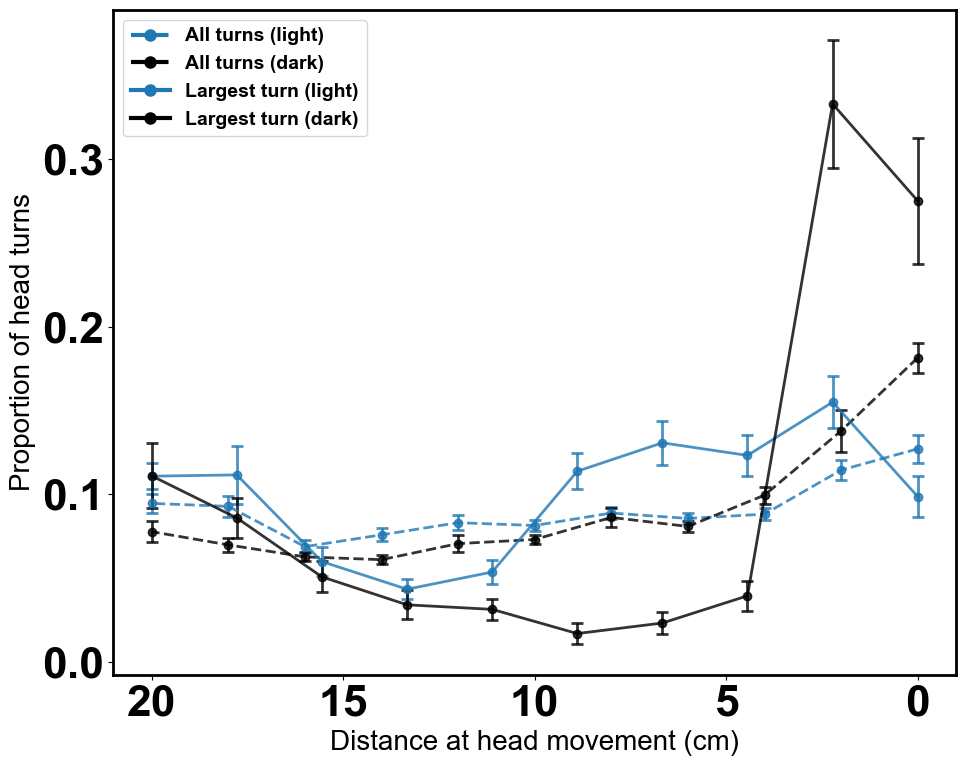

In [603]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)
# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Common parameters
xnew = np.arange(0, 21, 2)  # For all head turns
xnew2 = np.linspace(0, 20, 10)  # For largest head turns

# Data processing for all head turns (first plot)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  

# Process all head turns - light condition
light = data[data.task == 'oa']
light_prob_all = []
for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, _ = np.histogram(ani_light_dists, bins=len(xnew))
    prob = counts / sum(counts) if sum(counts) > 0 else np.nan
    light_prob_all.append(prob)
light_prob_all = np.array(light_prob_all)
light_hist_all = np.nanmean(light_prob_all, axis=0)
light_sem_all = np.nanstd(light_prob_all, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob_all), axis=0))

# Process all head turns - dark condition
dark = data[data.task == 'oadark']
dark_prob_all = []
for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, _ = np.histogram(ani_dark_dists, bins=len(xnew))
    prob = counts / sum(counts) if sum(counts) > 0 else np.nan
    dark_prob_all.append(prob)
dark_prob_all = np.array(dark_prob_all)
dark_hist_all = np.nanmean(dark_prob_all, axis=0)
dark_sem_all = np.nanstd(dark_prob_all, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob_all), axis=0))

# Data processing for largest head turns (second plot)
data2 = pd.concat([light_dark])
data2 = drop_nans_in_columns(data2, 'obstacle_ind')
data2 = data2[~data2['obstacle_cluster'].isin([2,3])] 
data2 = data2[data2.intial_distance>=15] 
data2 = data2[data2.intial_lateral_error<0] 

# Process largest head turns - light condition
light2 = data2[data2.task == 'oa']
light_prob_largest = []
for ani, ani_df in light2.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    counts, _ = np.histogram(ani_light_dists, bins=len(xnew2), range=(0,20))
    prob = counts / sum(counts) if sum(counts) > 0 else np.nan
    light_prob_largest.append(prob)
light_prob_largest = np.array(light_prob_largest)
light_hist_largest = np.nanmean(light_prob_largest, axis=0)
light_sem_largest = np.nanstd(light_prob_largest, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob_largest), axis=0))

# Process largest head turns - dark condition
dark2 = data2[data2.task == 'oadark']
dark_prob_largest = []
for ani, ani_df in dark2.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    counts, _ = np.histogram(ani_dark_dists, bins=len(xnew2), range=(0,20))
    prob = counts / sum(counts) if sum(counts) > 0 else np.nan
    dark_prob_largest.append(prob)
dark_prob_largest = np.array(dark_prob_largest)
dark_hist_largest = np.nanmean(dark_prob_largest, axis=0)
dark_sem_largest = np.nanstd(dark_prob_largest, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob_largest), axis=0))

# Plot with error bars
# All head turns (dashed lines with error bars)
ax.errorbar(xnew, light_hist_all, yerr=light_sem_all,
           fmt='--o', color='tab:blue', linewidth=2,
           markersize=6, capsize=4, capthick=2, alpha=0.8,
           label='All turns (light)')

ax.errorbar(xnew, dark_hist_all, yerr=dark_sem_all,
           fmt='--o', color='black', linewidth=2,
           markersize=6, capsize=4, capthick=2, alpha=0.8,
           label='All turns (dark)')

# Largest head turns (solid lines with error bars)
ax.errorbar(xnew2, light_hist_largest, yerr=light_sem_largest,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=6, capsize=4, capthick=2, alpha=0.8,
           label='Largest turn (light)')

ax.errorbar(xnew2, dark_hist_largest, yerr=dark_sem_largest,
           fmt='-o', color='black', linewidth=2,
           markersize=6, capsize=4, capthick=2, alpha=0.8,
           label='Largest turn (dark)')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_ylabel('Proportion of head turns', fontsize=20)
ax.set_xlabel('Distance at head movement (cm)', fontsize=20)
ax.invert_xaxis()

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='tab:blue', linestyle='--', lw=3, marker='o', markersize=8, label='All turns (light)'),
    Line2D([0], [0], color='black', linestyle='--', lw=3, marker='o', markersize=8, label='All turns (dark)'),
    Line2D([0], [0], color='tab:blue', linestyle='-', lw=3, marker='o', markersize=8, label='Largest turn (light)'),
    Line2D([0], [0], color='black', linestyle='-', lw=3, marker='o', markersize=8, label='Largest turn (dark)')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=14, framealpha=0.8)

plt.tight_layout()
plt.show()

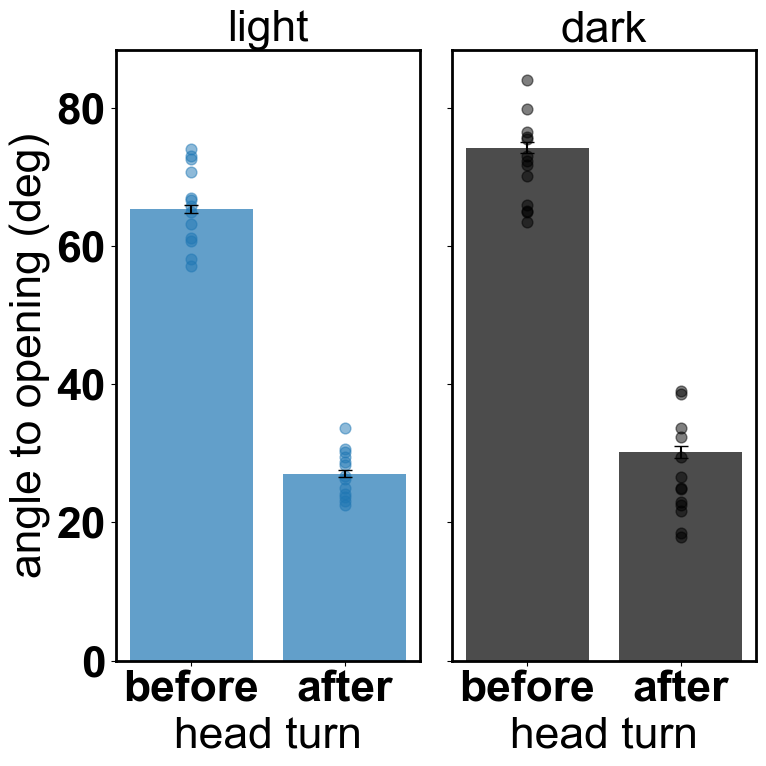

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

# panel 1: oa data (light - tab:blue)
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']

# calculate means and standard errors for oa data
oa_before_mean = oa_data['angle_before_head_turn'].mean()
oa_before_se = oa_data['angle_before_head_turn'].sem()
oa_after_mean = oa_data['angle_after_head_turn'].mean()
oa_after_se = oa_data['angle_after_head_turn'].sem()

# plot bars with error bars (both tab:blue)
ax1.bar(0, oa_before_mean, yerr=oa_before_se, color='tab:blue', capsize=5, alpha=0.7)
ax1.bar(1, oa_after_mean, yerr=oa_after_se, color='tab:blue', capsize=5, alpha=0.7)

# add individual animal means as scatter points (tab:blue)
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax1.scatter([0], [before_mean], color='tab:blue', alpha=0.5, s=60)
    ax1.scatter([1], [after_mean], color='tab:blue', alpha=0.5, s=60)

ax1.set_title('light')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['before', 'after'])
ax1.set_ylabel('angle to opening (deg)')
ax1.set_xlabel('head turn')

# panel 2: oadark data (dark - black)
oadark_data = data[data['task'] == 'oadark']

# calculate means and standard errors for oadark data
oadark_before_mean = oadark_data['angle_before_head_turn'].mean()
oadark_before_se = oadark_data['angle_before_head_turn'].sem()
oadark_after_mean = oadark_data['angle_after_head_turn'].mean()
oadark_after_se = oadark_data['angle_after_head_turn'].sem()

# plot bars with error bars (both black)
ax2.bar(0, oadark_before_mean, yerr=oadark_before_se, color='black', capsize=5, alpha=0.7)
ax2.bar(1, oadark_after_mean, yerr=oadark_after_se, color='black', capsize=5, alpha=0.7)

# add individual animal means as scatter points (black)
for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax2.scatter([0], [before_mean], color='black', alpha=0.5, s=60)
    ax2.scatter([1], [after_mean], color='black', alpha=0.5, s=60)

ax2.set_title('dark')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['before', 'after'])
ax2.set_xlabel('head turn')

# adjust layout and show plot
plt.tight_layout()
plt.show()

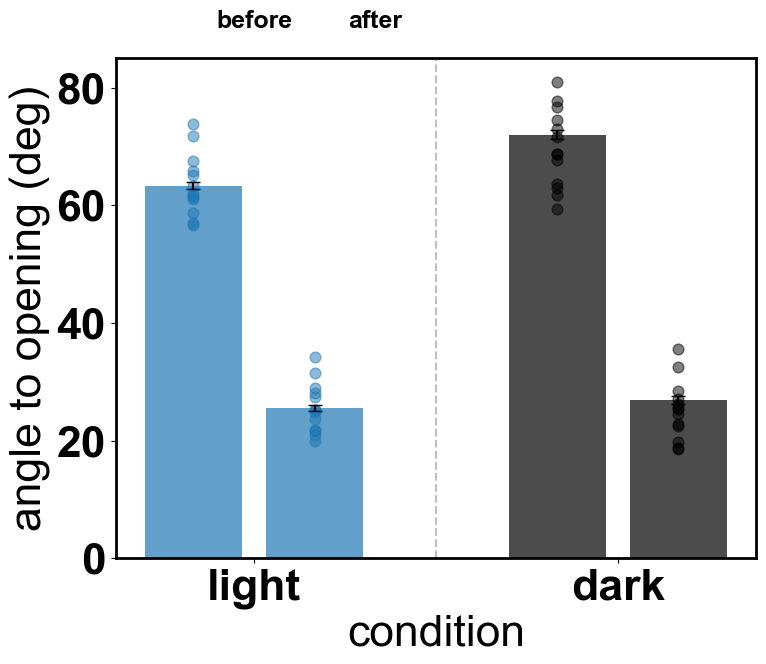

In [275]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create figure with one subplot
fig, ax = plt.subplots(figsize=(8, 7))

# prepare data (same as original)
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

# Set positions for the bars
positions = [0, 1, 3, 4]  # positions for light before, light after, dark before, dark after

# Calculate means and standard errors for both conditions
oa_before_mean = oa_data['angle_before_head_turn'].mean()
oa_before_se = oa_data['angle_before_head_turn'].sem()
oa_after_mean = oa_data['angle_after_head_turn'].mean()
oa_after_se = oa_data['angle_after_head_turn'].sem()

oadark_before_mean = oadark_data['angle_before_head_turn'].mean()
oadark_before_se = oadark_data['angle_before_head_turn'].sem()
oadark_after_mean = oadark_data['angle_after_head_turn'].mean()
oadark_after_se = oadark_data['angle_after_head_turn'].sem()

# Plot bars with error bars
ax.bar(positions[0], oa_before_mean, yerr=oa_before_se, color='tab:blue', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[1], oa_after_mean, yerr=oa_after_se, color='tab:blue', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[2], oadark_before_mean, yerr=oadark_before_se, color='black', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[3], oadark_after_mean, yerr=oadark_after_se, color='black', capsize=5, alpha=0.7, width=0.8)

# Add individual animal means as scatter points
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax.scatter([positions[0]], [before_mean], color='tab:blue', alpha=0.5, s=60)
    ax.scatter([positions[1]], [after_mean], color='tab:blue', alpha=0.5, s=60)

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax.scatter([positions[2]], [before_mean], color='black', alpha=0.5, s=60)
    ax.scatter([positions[3]], [after_mean], color='black', alpha=0.5, s=60)

# Customize the plot
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(['light', 'dark'])
ax.set_ylabel('angle to opening (deg)')
ax.set_xlabel('condition')

# Add before/after labels and a dividing line
ax.text(0.5, ax.get_ylim()[1]*1.05, 'before', ha='center', va='bottom')
ax.text(1.5, ax.get_ylim()[1]*1.05, 'after', ha='center', va='bottom')
ax.axvline(2, color='gray', linestyle='--', alpha=0.5)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

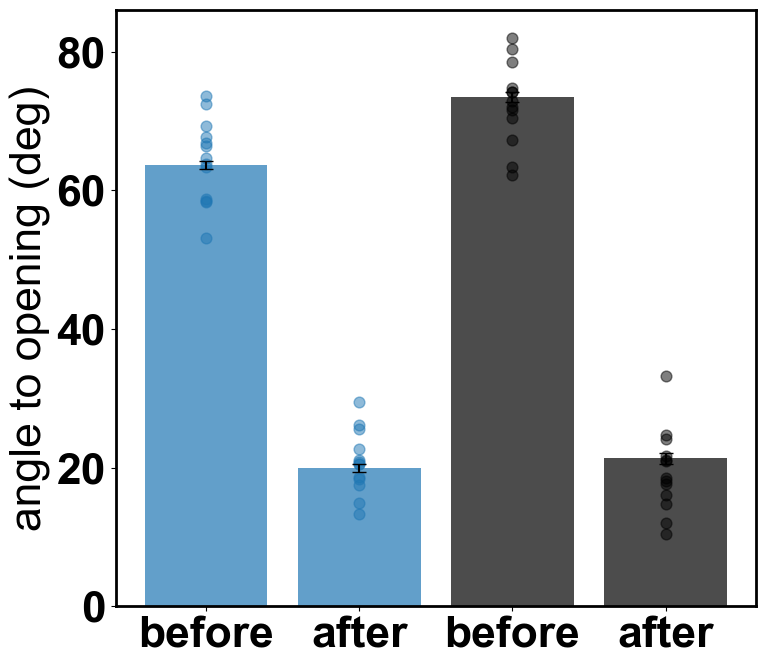

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create figure with one subplot
fig, ax = plt.subplots(figsize=(8, 7))

# prepare data (same as original)
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

# Set positions for the bars (now evenly spaced)
positions = [0, 1, 2, 3]  # positions for light before, light after, dark before, dark after

# Calculate medians and standard errors for both conditions
oa_before_median = oa_data['angle_before_head_turn'].median()
oa_before_se = oa_data['angle_before_head_turn'].sem()
oa_after_median = oa_data['angle_after_head_turn'].median()
oa_after_se = oa_data['angle_after_head_turn'].sem()

oadark_before_median = oadark_data['angle_before_head_turn'].median()
oadark_before_se = oadark_data['angle_before_head_turn'].sem()
oadark_after_median = oadark_data['angle_after_head_turn'].median()
oadark_after_se = oadark_data['angle_after_head_turn'].sem()

# Plot bars with error bars
ax.bar(positions[0], oa_before_median, yerr=oa_before_se, color='tab:blue', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[1], oa_after_median, yerr=oa_after_se, color='tab:blue', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[2], oadark_before_median, yerr=oadark_before_se, color='black', capsize=5, alpha=0.7, width=0.8)
ax.bar(positions[3], oadark_after_median, yerr=oadark_after_se, color='black', capsize=5, alpha=0.7, width=0.8)

# Add individual animal medians as scatter points
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    before_median = animal_data['angle_before_head_turn'].median()
    after_median = animal_data['angle_after_head_turn'].median()
    ax.scatter([positions[0]], [before_median], color='tab:blue', alpha=0.5, s=60)
    ax.scatter([positions[1]], [after_median], color='tab:blue', alpha=0.5, s=60)

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    before_median = animal_data['angle_before_head_turn'].median()
    after_median = animal_data['angle_after_head_turn'].median()
    ax.scatter([positions[2]], [before_median], color='black', alpha=0.5, s=60)
    ax.scatter([positions[3]], [after_median], color='black', alpha=0.5, s=60)

# Customize the plot
ax.set_xticks(positions)
ax.set_xticklabels(['before', 'after', 'before', 'after'])  # Labels directly under each bar
ax.set_ylabel('angle to opening (deg)')



# Add subtle vertical lines to group the pairs


# Adjust layout and show plot
plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\angle_.pdf",dpi = 300, transparent=True)

In [598]:
light_dark.distance_at_head_turn.to_numpy().shape

(14553,)

In [595]:
flatten_list_of_arrays(light_dark.distances_at_head_turns.to_numpy()).shape

(73874,)

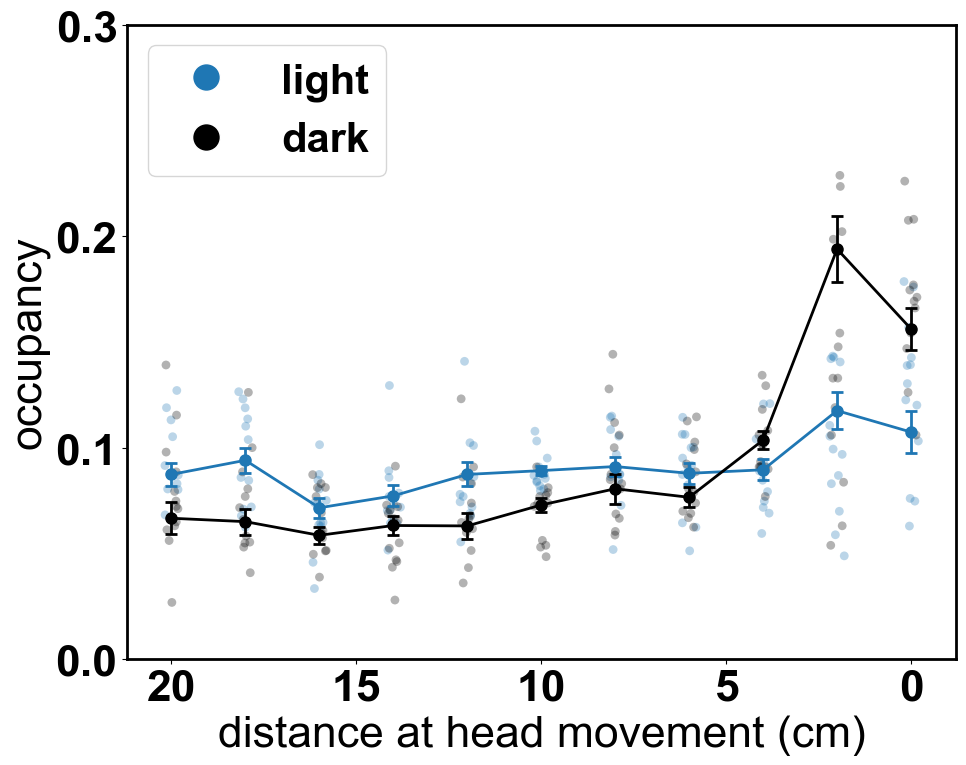

In [460]:
xnew = np.arange(0, 21, 2)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
#ts_calculate_relative_distance2(light)
light_dist = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=len(xnew))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
#ts_calculate_relative_distance2(dark)
dark_dist = flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2,.3])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance at head movement (cm)', fontsize=32)
ax.invert_xaxis()

# Legend

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

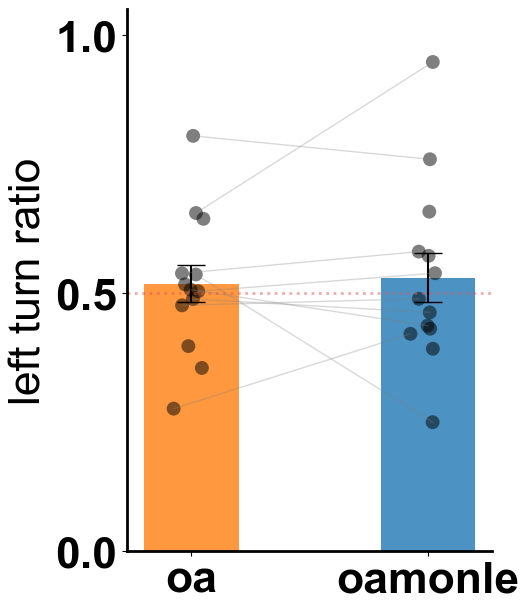

In [461]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(6, 7))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 



# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oadark'] 

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order)
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['oa', 'oamonle'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)



plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_comparison_switched.pdf", dpi=300, transparent=True)
plt.show()

In [24]:
light_dark.tortuosity

0        1.529404
1        1.886171
2        1.642790
3        1.516201
4        1.148280
           ...   
14548    1.496037
14549    1.172446
14550    1.256019
14551    1.101086
14552    1.473633
Name: tortuosity, Length: 14553, dtype: float64

In [277]:
light_dist = flatten_list_of_arrays(light.head_turn_velocities.to_numpy())

(array([  24.,   38.,  211., 1740., 6866., 6367., 1864.,  256.,   32.,
          17.]),
 array([-19.79603474, -15.82958783, -11.86314091,  -7.89669399,
         -3.93024708,   0.03619984,   4.00264676,   7.96909367,
         11.93554059,  15.90198751,  19.86843443]),
 <BarContainer object of 10 artists>)

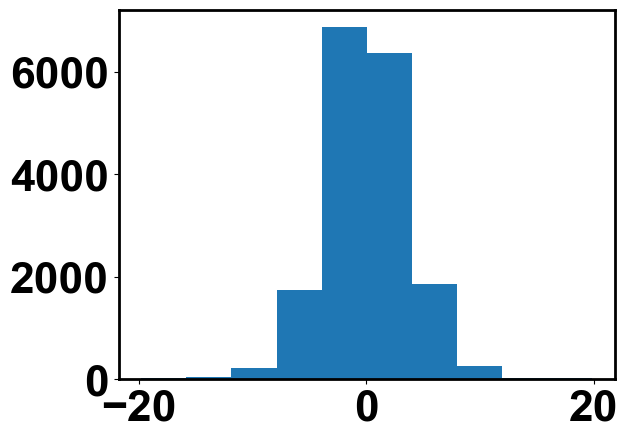

In [278]:
plt.hist(light_dist)

In [235]:
light_dist

array([179.696092  , 236.42870041,  62.56127752, ..., 112.64705765,
       418.06014858,  43.67092183])

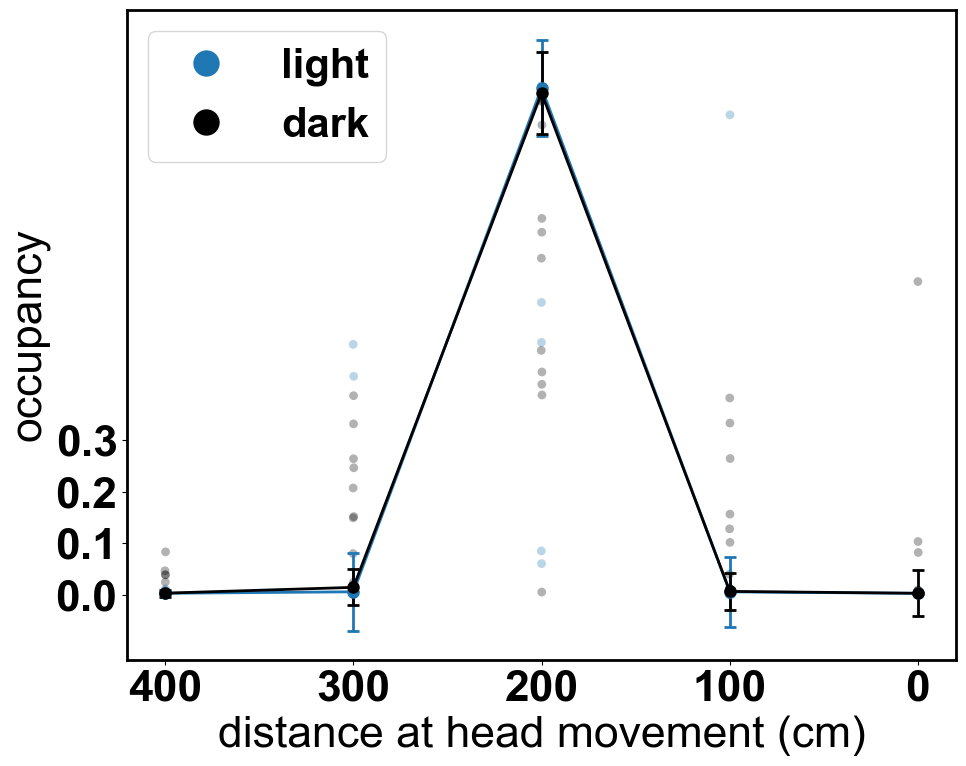

In [177]:
xnew = np.arange(0, 500, 100)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
#ts_calculate_relative_distance2(light)
light_dist = flatten_list_of_arrays(light.head_turn_velocities.to_numpy())
light_dist =  light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist, bins=len(xnew))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.head_turn_velocities.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
#ts_calculate_relative_distance2(dark)
dark_dist = flatten_list_of_arrays(dark.head_turn_velocities.to_numpy())
dark_dist =  dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.head_turn_velocities.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
#ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2,.3])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance at head movement (cm)', fontsize=32)
ax.invert_xaxis()

# Legend

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

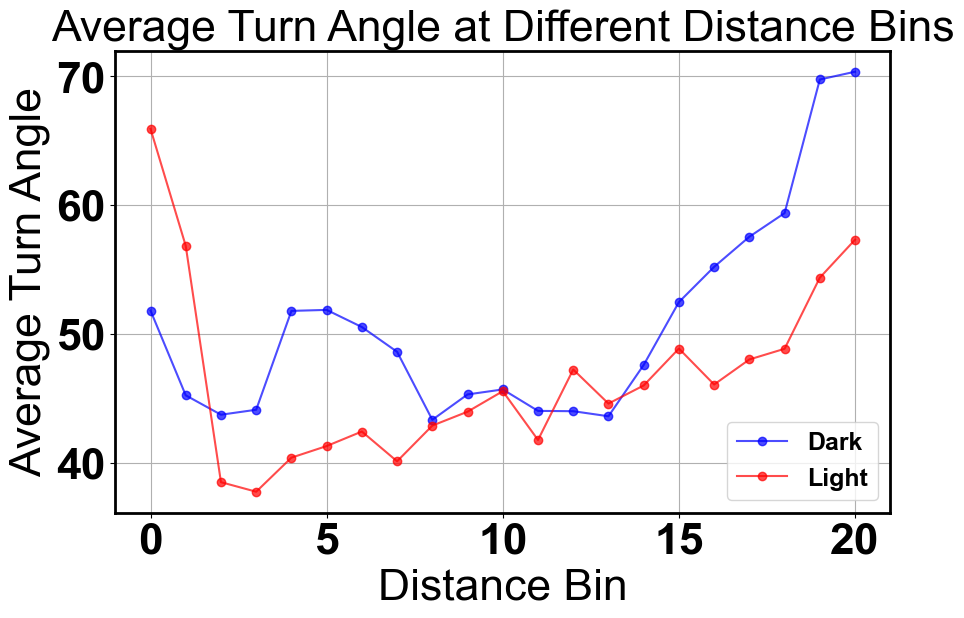

In [178]:
import numpy as np
import matplotlib.pyplot as plt

# First, flatten the lists and round distances
dark_turn_angles = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
light_turn_angles = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())

dark_turn_distances = flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())
light_turn_distances = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())

dark_turn_distances = np.round(dark_turn_distances)
light_turn_distances = np.round(light_turn_distances)

# Check lengths match
assert len(dark_turn_distances) == len(dark_turn_angles), "Dark distances and angles lengths don't match"
assert len(light_turn_distances) == len(light_turn_angles), "Light distances and angles lengths don't match"

# Define distance bins (0-20)
distance_bins = np.arange(0, 21)  # Creates bins 0, 1, 2, ..., 20

# Function to calculate average angles per distance bin
def get_avg_angles(distances, angles, bins):
    avg_angles = []
    for d in bins:
        idx = np.where(distances == d)[0]
        if len(idx) > 0:
            avg_angles.append(np.mean(angles[idx]))
        else:
            avg_angles.append(np.nan)  # Use nan if no data for this distance
    return avg_angles

# Calculate averages
dark_avg_angles = get_avg_angles(dark_turn_distances, dark_turn_angles, distance_bins)
light_avg_angles = get_avg_angles(light_turn_distances, light_turn_angles, distance_bins)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(distance_bins, dark_avg_angles, 'b-o', label='Dark', alpha=0.7)
plt.plot(distance_bins, light_avg_angles, 'r-o', label='Light', alpha=0.7)

plt.xlabel('Distance Bin')
plt.ylabel('Average Turn Angle')
plt.title('Average Turn Angle at Different Distance Bins')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

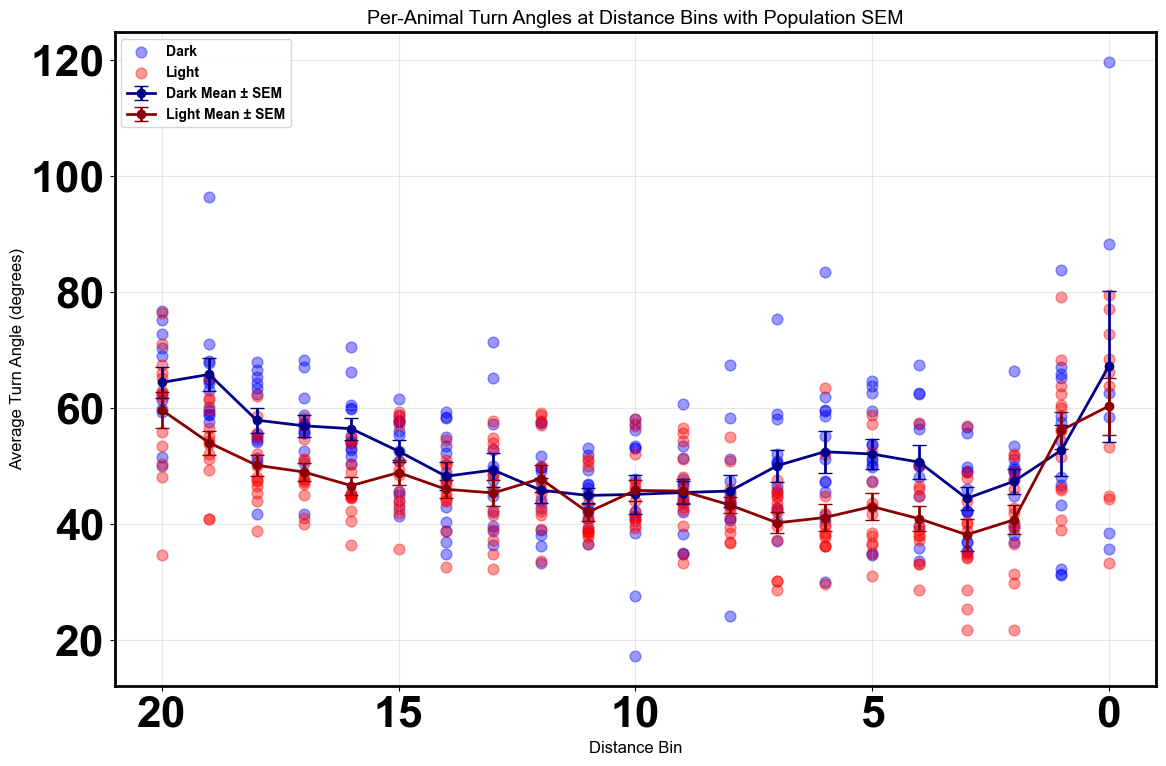

In [179]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem

# Get unique animals in each condition
dark_animals = dark['animal'].unique()
light_animals = light['animal'].unique()

# Define distance bins (0-20)
distance_bins = np.arange(0, 21)

# Function to calculate per-animal averages
def get_animal_avg_angles(df, bins):
    animal_data = {}
    for animal in df['animal'].unique():
        # Get data for this animal
        animal_df = df[df['animal'] == animal]
        angles = flatten_list_of_arrays(animal_df.angles_at_head_turns.to_numpy())
        distances = np.round(flatten_list_of_arrays(animal_df.distances_at_head_turns.to_numpy()))
        
        # Calculate averages per bin
        avg_angles = []
        for d in bins:
            idx = np.where(distances == d)[0]
            avg_angles.append(np.mean(angles[idx]) if len(idx) > 0 else np.nan)
        
        animal_data[animal] = avg_angles
    return animal_data

# Get per-animal data
dark_animal_angles = get_animal_avg_angles(dark, distance_bins)
light_animal_angles = get_animal_avg_angles(light, distance_bins)

# Calculate population means and standard errors
def calculate_population_stats(animal_data, bins):
    # Convert to array (animals × bins)
    angles_matrix = np.array([angles for angles in animal_data.values()])
    pop_mean = np.nanmean(angles_matrix, axis=0)
    pop_sem = sem(angles_matrix, axis=0, nan_policy='omit')
    return pop_mean, pop_sem

dark_mean, dark_sem = calculate_population_stats(dark_animal_angles, distance_bins)
light_mean, light_sem = calculate_population_stats(light_animal_angles, distance_bins)

# Plotting
plt.figure(figsize=(12, 8))

# Plot individual animals (scatter)
for animal, angles in dark_animal_angles.items():
    plt.scatter(distance_bins, angles, color='blue', alpha=0.4, s=60, label='Dark' if animal == list(dark_animal_angles.keys())[0] else "")

for animal, angles in light_animal_angles.items():
    plt.scatter(distance_bins, angles, color='red', alpha=0.4, s=60, label='Light' if animal == list(light_animal_angles.keys())[0] else "")

# Plot population means with error bars
plt.errorbar(distance_bins, dark_mean, yerr=dark_sem, 
             fmt='-o', color='darkblue', linewidth=2, capsize=5, label='Dark Mean ± SEM')
plt.errorbar(distance_bins, light_mean, yerr=light_sem, 
             fmt='-o', color='darkred', linewidth=2, capsize=5, label='Light Mean ± SEM')

# Customize plot
plt.gca().invert_xaxis()  # Invert x-axis
plt.xlabel('Distance Bin', fontsize=12)
plt.ylabel('Average Turn Angle (degrees)', fontsize=12)
plt.title('Per-Animal Turn Angles at Distance Bins with Population SEM', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

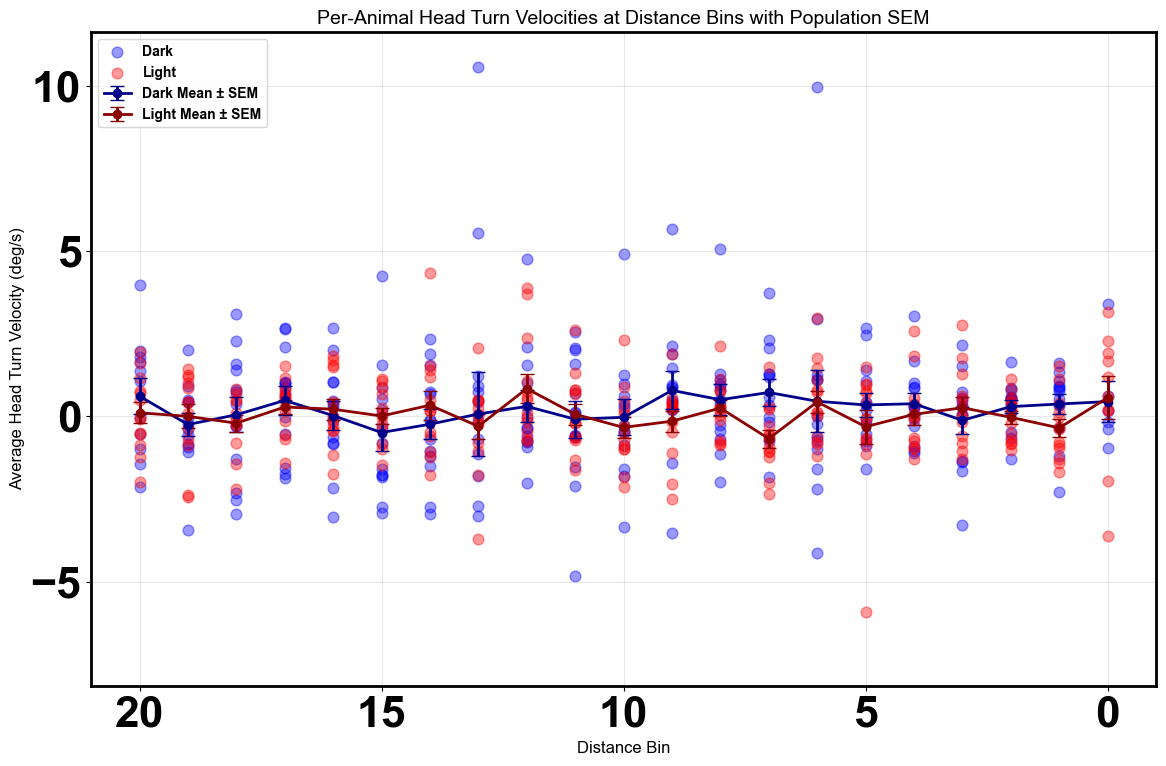

In [180]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem

data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get unique animals in each condition
dark_animals = dark['animal'].unique()
light_animals = light['animal'].unique()

# Define distance bins (0-20)
distance_bins = np.arange(0, 21)

# Function to calculate per-animal averages for velocities
def get_animal_avg_velocities(df, bins):
    animal_data = {}
    for animal in df['animal'].unique():
        # Get data for this animal
        animal_df = df[df['animal'] == animal]
        velocities = flatten_list_of_arrays(animal_df.head_turn_velocities.to_numpy())
        distances = np.round(flatten_list_of_arrays(animal_df.distances_at_head_turns.to_numpy()))
        
        # Calculate averages per bin
        avg_velocities = []
        for d in bins:
            idx = np.where(distances == d)[0]
            avg_velocities.append(np.mean(velocities[idx]) if len(idx) > 0 else np.nan)
        
        animal_data[animal] = avg_velocities
    return animal_data

# Get per-animal data for velocities
dark_animal_velocities = get_animal_avg_velocities(dark, distance_bins)
light_animal_velocities = get_animal_avg_velocities(light, distance_bins)

# Calculate population means and standard errors for velocities
def calculate_population_stats(animal_data, bins):
    # Convert to array (animals × bins)
    velocities_matrix = np.array([velocities for velocities in animal_data.values()])
    pop_mean = np.nanmean(velocities_matrix, axis=0)
    pop_sem = sem(velocities_matrix, axis=0, nan_policy='omit')
    return pop_mean, pop_sem

dark_mean_vel, dark_sem_vel = calculate_population_stats(dark_animal_velocities, distance_bins)
light_mean_vel, light_sem_vel = calculate_population_stats(light_animal_velocities, distance_bins)

# Plotting
plt.figure(figsize=(12, 8))

# Plot individual animals (scatter) for velocities
for animal, velocities in dark_animal_velocities.items():
    plt.scatter(distance_bins, velocities, color='blue', alpha=0.4, s=60, 
                label='Dark' if animal == list(dark_animal_velocities.keys())[0] else "")

for animal, velocities in light_animal_velocities.items():
    plt.scatter(distance_bins, velocities, color='red', alpha=0.4, s=60, 
                label='Light' if animal == list(light_animal_velocities.keys())[0] else "")

# Plot population means with error bars for velocities
plt.errorbar(distance_bins, dark_mean_vel, yerr=dark_sem_vel, 
             fmt='-o', color='darkblue', linewidth=2, capsize=5, label='Dark Mean ± SEM')
plt.errorbar(distance_bins, light_mean_vel, yerr=light_sem_vel, 
             fmt='-o', color='darkred', linewidth=2, capsize=5, label='Light Mean ± SEM')

# Customize plot
plt.gca().invert_xaxis()  # Invert x-axis
plt.xlabel('Distance Bin', fontsize=12)
plt.ylabel('Average Head Turn Velocity (deg/s)', fontsize=12)  # Update y-axis label
plt.title('Per-Animal Head Turn Velocities at Distance Bins with Population SEM', fontsize=14)
plt.legend(fontsize=10, loc='upper left')  # Adjust legend position
plt.grid(True, alpha=0.3)

# Adjust y-axis limits if needed (remove if automatic scaling is fine)
vel_data = np.concatenate([np.array(v) for v in dark_animal_velocities.values()] + 
                          [np.array(v) for v in light_animal_velocities.values()])
plt.ylim(np.nanmin(vel_data)*0.9, np.nanmax(vel_data)*1.1)  # 10% padding

plt.tight_layout()
plt.show()

In [6]:
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

In [13]:
flatten_list_of_arrays(light.distances_at_head_turns.to_numpy()).shape

(14768,)

In [12]:
flatten_list_of_arrays(light.angles_at_head_turns.to_numpy()).shape

(14768,)

(array([764., 578., 615., 989., 628., 233.,  96.,  59.,  39.,  17.]),
 array([1.25020522e-02, 1.77249077e+01, 3.54373134e+01, 5.31497191e+01,
        7.08621247e+01, 8.85745304e+01, 1.06286936e+02, 1.23999342e+02,
        1.41711747e+02, 1.59424153e+02, 1.77136559e+02]),
 <BarContainer object of 10 artists>)

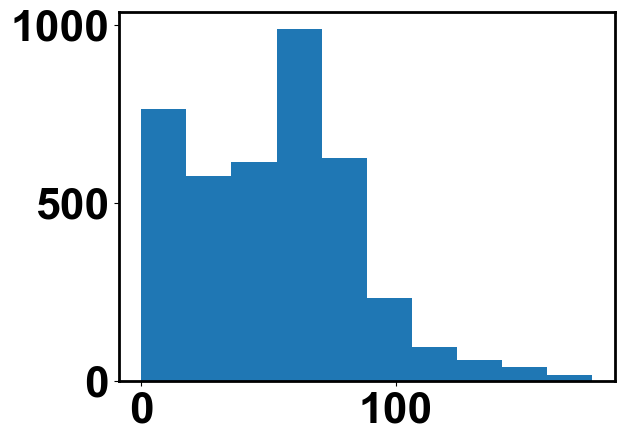

In [579]:
plt.hist(flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy()))

In [290]:
light.head_turn_velocity

5       17.136954
7       -5.369580
8       -4.699180
9       -6.422671
10      12.533449
          ...    
8871     4.611240
8874     6.698335
8875     4.146346
8878    -5.830302
8880    -6.967669
Name: head_turn_velocity, Length: 2205, dtype: float64

Text(0, 0.5, 'porportion of movments')

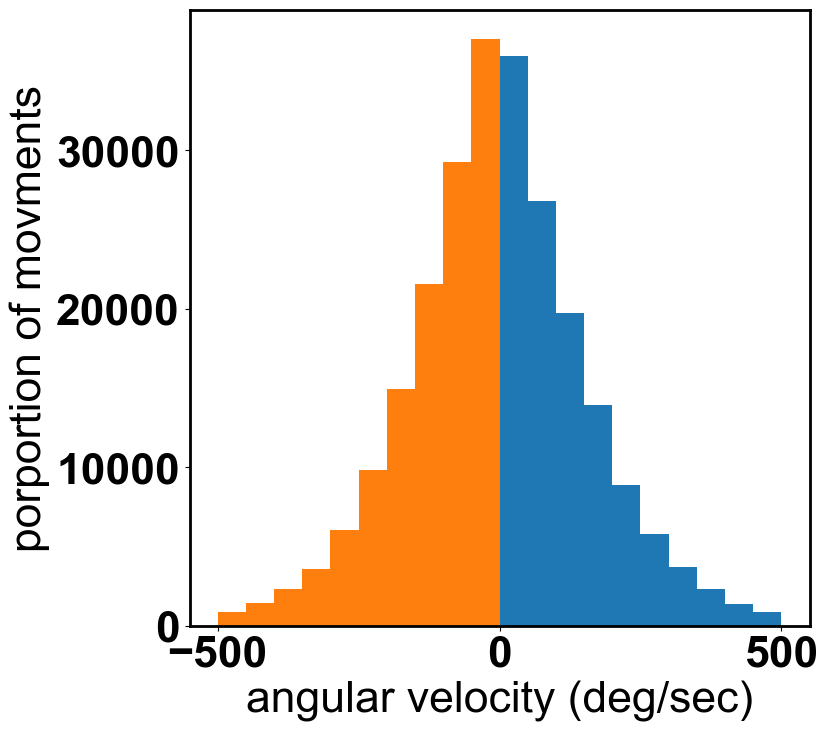

In [446]:
all_turns = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,range = (0,500))
plt.hist(neg_turns,range = (-500,0))
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('porportion of movments')

In [537]:
all_angles

array([21.7611355 , 49.9664894 , 87.59075399, ...,  3.27892062,
       -7.53117314, -6.2400402 ])

In [545]:
turns_from_angles

array([], shape=(0, 0), dtype=float64)

(array([ 20., 133., 498., 316.,   6.,   6., 343., 556., 168.,  33.]),
 array([-800., -640., -480., -320., -160.,    0.,  160.,  320.,  480.,
         640.,  800.]),
 <BarContainer object of 10 artists>)

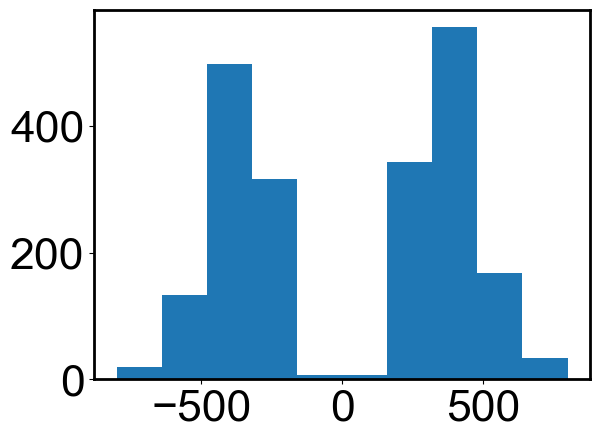

In [581]:
plt.hist(all_turns,range = (-800,800))

(array([  282.,   899.,  5495., 23697., 92902., 84834., 17544.,  6773.,
         4967.,  4245.]),
 array([-800., -640., -480., -320., -160.,    0.,  160.,  320.,  480.,
         640.,  800.]),
 <BarContainer object of 10 artists>)

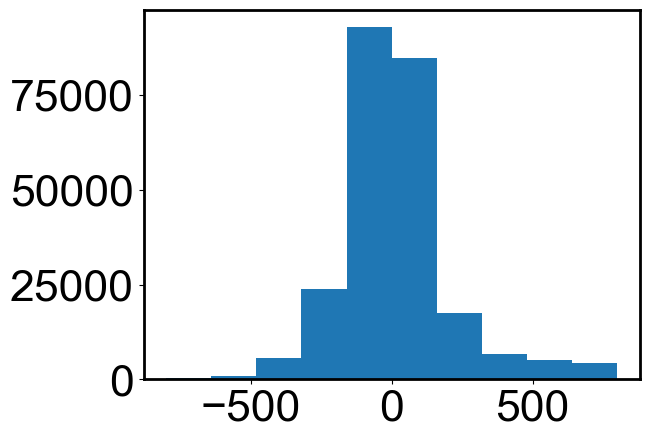

In [582]:
plt.hist(all_angles_corner,range = (-800,800))

In [583]:
[np.intersect1d(all_angles, all_turns,return_indices=True)[1]]

[array([176168, 172297,  73442, ...,  42554, 208570, 146429], dtype=int64)]

(array([  16.,  104.,  672., 1023.,  204.,   47.,   51.,   36.,   15.,
          17.]),
 array([-800., -640., -480., -320., -160.,    0.,  160.,  320.,  480.,
         640.,  800.]),
 <BarContainer object of 10 artists>)

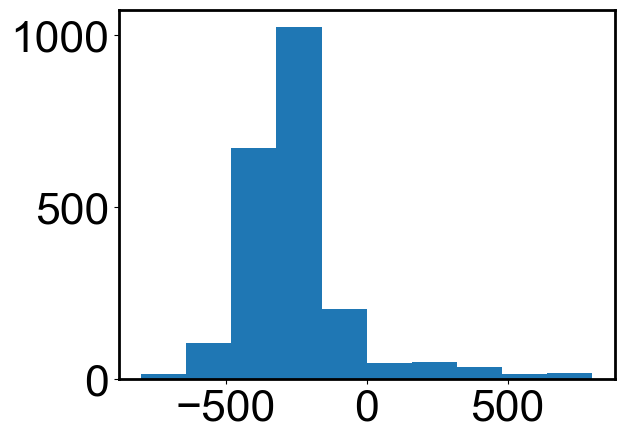

In [585]:
plt.hist(all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]],range = (-800,800))

(array([ 26., 204., 524., 420.,  84.,  33.,  27.,  17.,   9.,   8.]),
 array([-800., -640., -480., -320., -160.,    0.,  160.,  320.,  480.,
         640.,  800.]),
 <BarContainer object of 10 artists>)

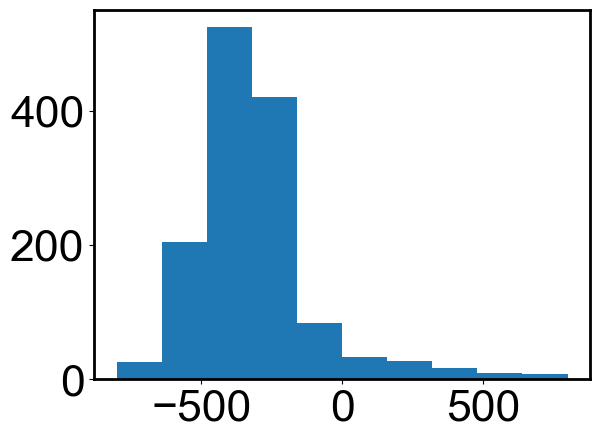

In [587]:
plt.hist(all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]],range = (-800,800))

In [573]:
turn_inds

array([], shape=(0, 0), dtype=int64)

In [579]:
np.intersect1d(all_angles, all_turns,return_indices=True)[1].shape

(2201,)

In [ ]:
np.argwhere(all_angles == all_turns)

array([], shape=(0, 0), dtype=int64)

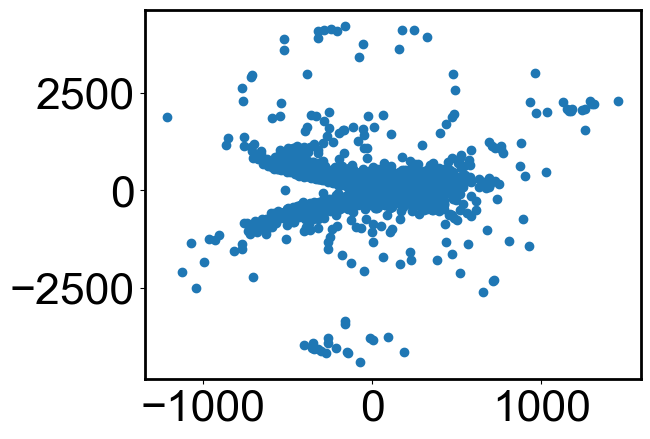

In [733]:
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60

corner_angle_at_turns = all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]]
angle_at_turns = all_angles[np.intersect1d(all_angles, all_turns,return_indices=True)[1]]
plt.scatter(corner_angle_at_turns,angle_at_turns)

In [ ]:
 all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]] < 

In [732]:
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60

corner_angle_at_turns = all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]][]
angle_at_turns = all_angles[np.intersect1d(all_angles, all_turns,return_indices=True)[1]]
plt.scatter(corner_angle_at_turns,angle_at_turns)

SyntaxError: invalid syntax (3734144083.py, line 5)

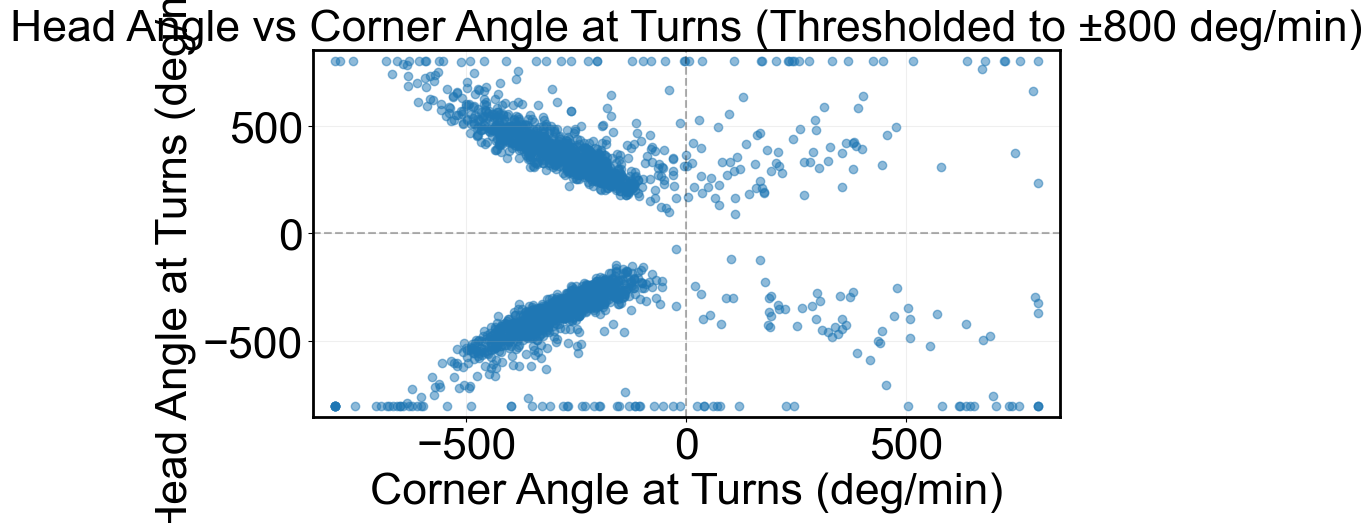

In [609]:
import matplotlib.pyplot as plt
import numpy as np

# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = light.head_turn_velocity.to_numpy() * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

# Apply thresholding (-800 to 800)
corner_angle_at_turns = np.clip(corner_angle_at_turns, -800, 800)
angle_at_turns = np.clip(angle_at_turns, -800, 800)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(corner_angle_at_turns, angle_at_turns, alpha=0.5)

# Add labels and title
plt.xlabel('Corner Angle at Turns (deg/min)')
plt.ylabel('Head Angle at Turns (deg/min)')
plt.title('Head Angle vs Corner Angle at Turns (Thresholded to ±800 deg/min)')

# Add reference lines
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Set axis limits to make sure we see the thresholds
plt.xlim(-850, 850)
plt.ylim(-850, 850)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

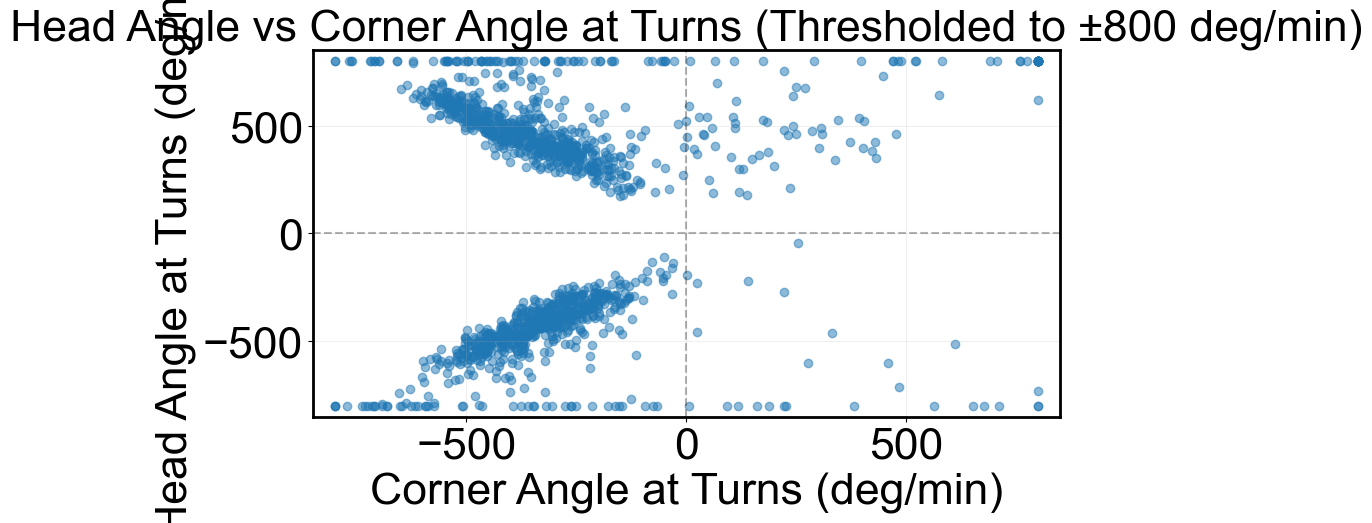

In [608]:
import matplotlib.pyplot as plt
import numpy as np

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = dark.head_turn_velocity.to_numpy() * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

# Apply thresholding (-800 to 800)
corner_angle_at_turns = np.clip(corner_angle_at_turns, -800, 800)
angle_at_turns = np.clip(angle_at_turns, -800, 800)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(corner_angle_at_turns, angle_at_turns, alpha=0.5)

# Add labels and title
plt.xlabel('Corner Angle at Turns (deg/min)')
plt.ylabel('Head Angle at Turns (deg/min)')
plt.title('Head Angle vs Corner Angle at Turns (Thresholded to ±800 deg/min)')

# Add reference lines
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Set axis limits to make sure we see the thresholds
plt.xlim(-850, 850)
plt.ylim(-850, 850)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

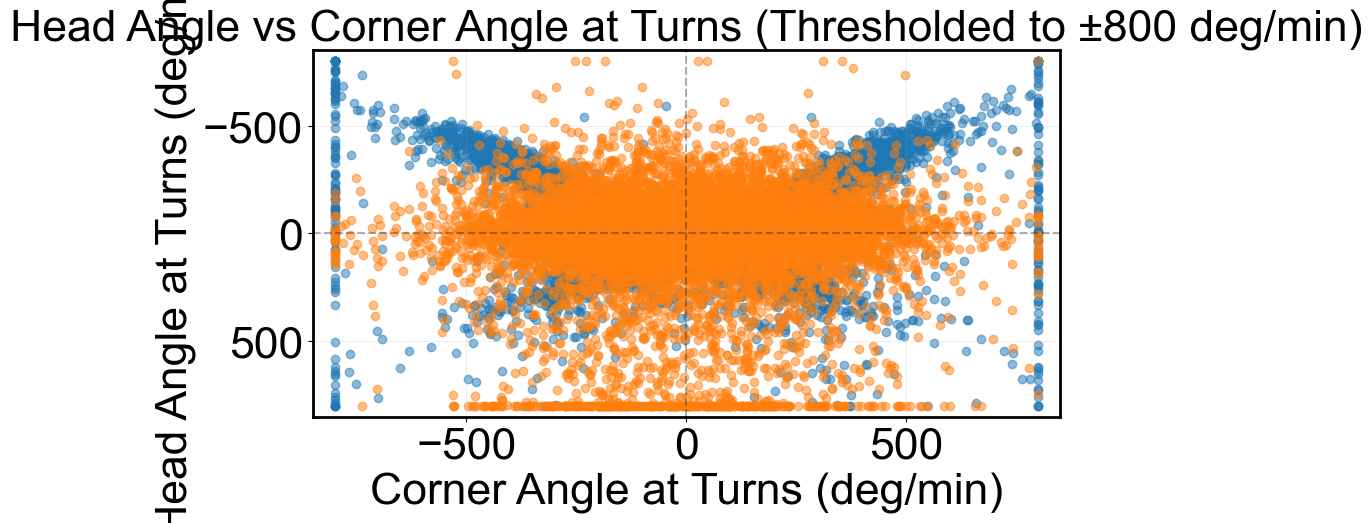

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -1000
upper_bound = 1000
mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
#all_angles = all_angles[mask]
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

# Apply thresholding (-800 to 800)
corner_angle_at_turns = np.clip(corner_angle_at_turns, -800, 800)
angle_at_turns = np.clip(angle_at_turns, -800, 800)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(angle_at_turns, corner_angle_at_turns, alpha=0.5)

all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -1000
upper_bound = 1000
mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
#all_angles = all_angles[mask]
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

# Apply thresholding (-800 to 800)
corner_angle_at_turns = np.clip(corner_angle_at_turns, -800, 800)
angle_at_turns = np.clip(angle_at_turns, -800, 800)

# Create the scatter plot
plt.scatter(angle_at_turns, corner_angle_at_turns, alpha=0.5)

# Add labels and title
plt.xlabel('Corner Angle at Turns (deg/min)')
plt.ylabel('Head Angle at Turns (deg/min)')
plt.title('Head Angle vs Corner Angle at Turns (Thresholded to ±800 deg/min)')

# Add reference lines
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Set axis limits to make sure we see the thresholds
plt.xlim(-850, 850)
plt.ylim(850, -850)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [746]:

def find_nan_indices_1d(arr):
    return [i for i, val in enumerate(arr) if np.isnan(val)]

In [751]:
find_nan_indices_1d(corner_angle_at_turns) + find_nan_indices_1d(angle_at_turns)

[6080]

In [748]:
find_nan_indices_1d(angle_at_turns)

[]

In [754]:
np.delete(corner_angle_at_turns, find_nan_indices_1d(corner_angle_at_turns) + find_nan_indices_1d(angle_at_turns)).shape

(10414,)

In [752]:
corner_angle_at_turns.pop(find_nan_indices_1d(corner_angle_at_turns) + find_nan_indices_1d(angle_at_turns)).shape

AttributeError: 'numpy.ndarray' object has no attribute 'pop'

In [767]:
type(corner_angle_at_turns)

numpy.ndarray

In [765]:
angle_at_turns.shape

(10414,)

In [766]:
corner_angle_at_turns.shape

(10414,)

In [771]:
bin_indices

array([ 59, 152, 117,  95,  24,  24,   9, 138,  96, 113,   3, 155, 133,
        33,  29,  29,  48,  83,  69,  46,  97,  22,  46,  58,  72, 125,
        31,  82,  94,   7,  97,  27,  10, 151, 154, 129,  48,  15, 109,
        70,  19,  79,   5, 145,  41, 106,  49,  83,  87,  29, 155, 124,
       150, 143,  95, 147,  14,  31,   7,  52,  62,  43, 132,  57,  44,
        86,  22, 128,  11, 157, 123,  31,   0, 130, 113, 116, 123,  11,
        57,  18, 138,  99,  52,  10,  49,  52, 116, 102, 141,  75,  19,
       114, 121,  89, 123,  79,  83,  68,   4,  17,   5, 101,  50,  81,
       145,  39,  65, 120,  36,  12,  46,  25, 148, 129, 101, 139, 128,
        29, 142,  86, 129, 143,  50,  17,  36,  68, 130, 137,   1,  81,
        66,  35,  19,  54, 150,  51,  83, 112,  58, 155, 153,  40,  79,
        48,  45,   5,  97,  80,   8,  44, 145,  38,  23,  78, 157,  38,
       107, 121,  38, 116,  58, 101, 101,  85,  14, 133,  51,  29,   6,
        94, 108,   2,  81,  36, 103,  27, 110,  61, 149,  22,  5

In [776]:
bin_indices.shape

(232607,)

In [774]:
bin_centers

array([-795., -785., -775., -765., -755., -745., -735., -725., -715.,
       -705., -695., -685., -675., -665., -655., -645., -635., -625.,
       -615., -605., -595., -585., -575., -565., -555., -545., -535.,
       -525., -515., -505., -495., -485., -475., -465., -455., -445.,
       -435., -425., -415., -405., -395., -385., -375., -365., -355.,
       -345., -335., -325., -315., -305., -295., -285., -275., -265.,
       -255., -245., -235., -225., -215., -205., -195., -185., -175.,
       -165., -155., -145., -135., -125., -115., -105.,  -95.,  -85.,
        -75.,  -65.,  -55.,  -45.,  -35.,  -25.,  -15.,   -5.,    5.,
         15.,   25.,   35.,   45.,   55.,   65.,   75.,   85.,   95.,
        105.,  115.,  125.,  135.,  145.,  155.,  165.,  175.,  185.,
        195.,  205.,  215.,  225.,  235.,  245.,  255.,  265.,  275.,
        285.,  295.,  305.,  315.,  325.,  335.,  345.,  355.,  365.,
        375.,  385.,  395.,  405.,  415.,  425.,  435.,  445.,  455.,
        465.,  475.,

In [796]:
np.digitize(all_angles, bins).min()

0

In [794]:
bin_indices.min()

-1

In [792]:
bin_centers.shape

(160,)

In [790]:
bin_indices

array([65, 54, 48, ..., 80, 79, 79], dtype=int64)

In [825]:
x_jittered.size()

TypeError: 'int' object is not callable

(array([  3.,   4.,  17., 139., 218., 182.,  25.,  13.,   4.,   2.]),
 array([-1097.96319988,  -876.13699063,  -654.31078138,  -432.48457213,
         -210.65836288,    11.16784637,   232.99405562,   454.82026487,
          676.64647413,   898.47268338,  1120.29889263]),
 <BarContainer object of 10 artists>)

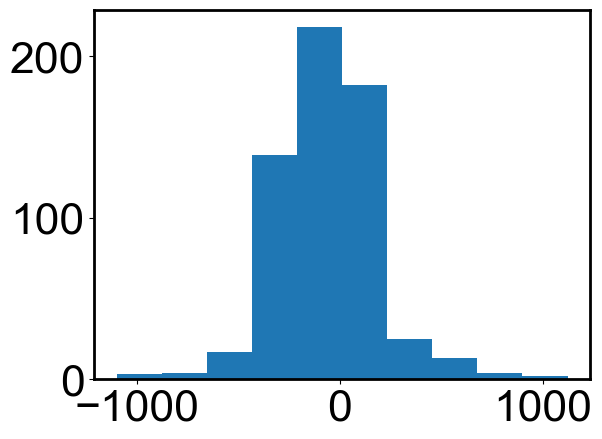

In [836]:
plt.hist(corner_angle_at_turns)

In [842]:
large_indices.shape

(2018,)

In [839]:
all_turns.shape

(10418,)

In [838]:
large_turns.shape

(2021,)

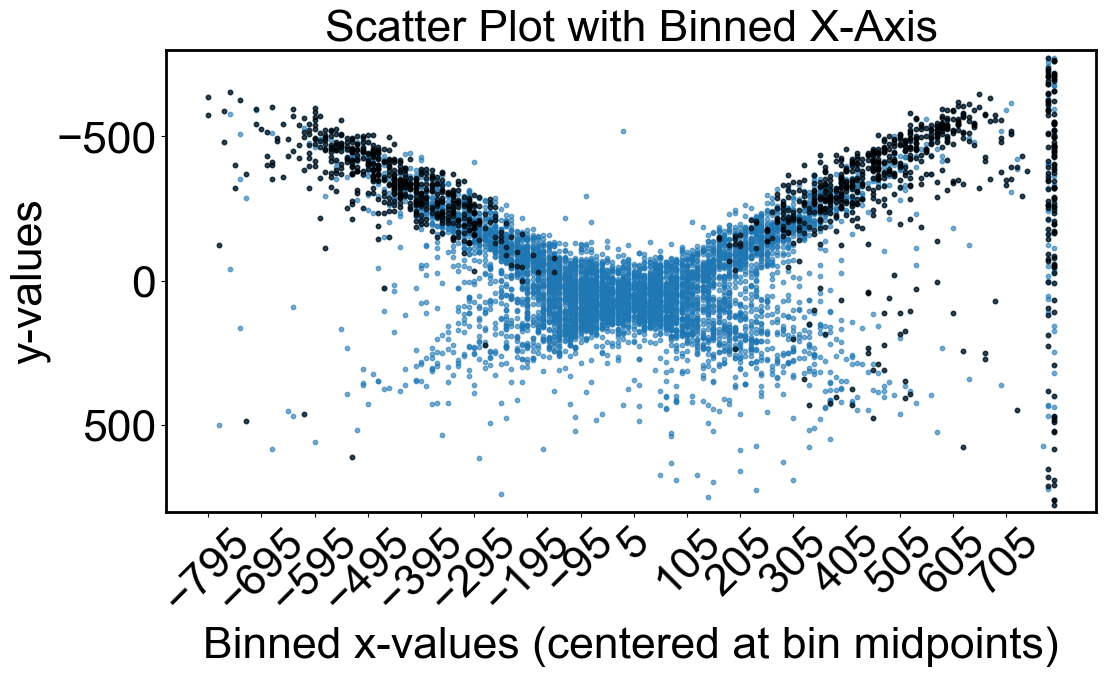

In [910]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]



# Define bins (from -800 to 800 in steps of 10)
bins = np.arange(-800, 810, 10)

# Assign each x-value to a bin
bin_indices = np.digitize(angle_at_turns, bins)-2   # Subtract 1 to make bins 0-indexed

# Compute bin centers for x-axis labels
bin_centers = (bins[:-1] + bins[1:]) / 2


bin_indices_large = np.digitize(angle_at_large_turns, bins)-2   # Subtract 1 to make bins 0-indexed

# Compute bin centers for x-axis labels
bin_centers_large = (bins[:-1] + bins[1:]) / 2
# Add small jitter to x-positions to avoid overplotting
x_jittered = bin_centers[bin_indices] + np.random.uniform(-3, 3, len(angle_at_turns))

# Create scatter plot
plt.figure(figsize=(12, 6))

plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10,color ='tab:blue')
plt.scatter(bin_centers_large[bin_indices_large], corner_angle_at_large_turns, alpha=0.6, s=10,color ='black')

# Customize plot
plt.xticks(bin_centers[::10], rotation=45)  # Show every 5th bin label
plt.xlabel("Binned x-values (centered at bin midpoints)")
plt.ylabel("y-values")
plt.title("Scatter Plot with Binned X-Axis")
plt.ylim(800,-800)
plt.show()


Ratio of NEGATIVE values in corner_angle_at_large_turns: 92.9%


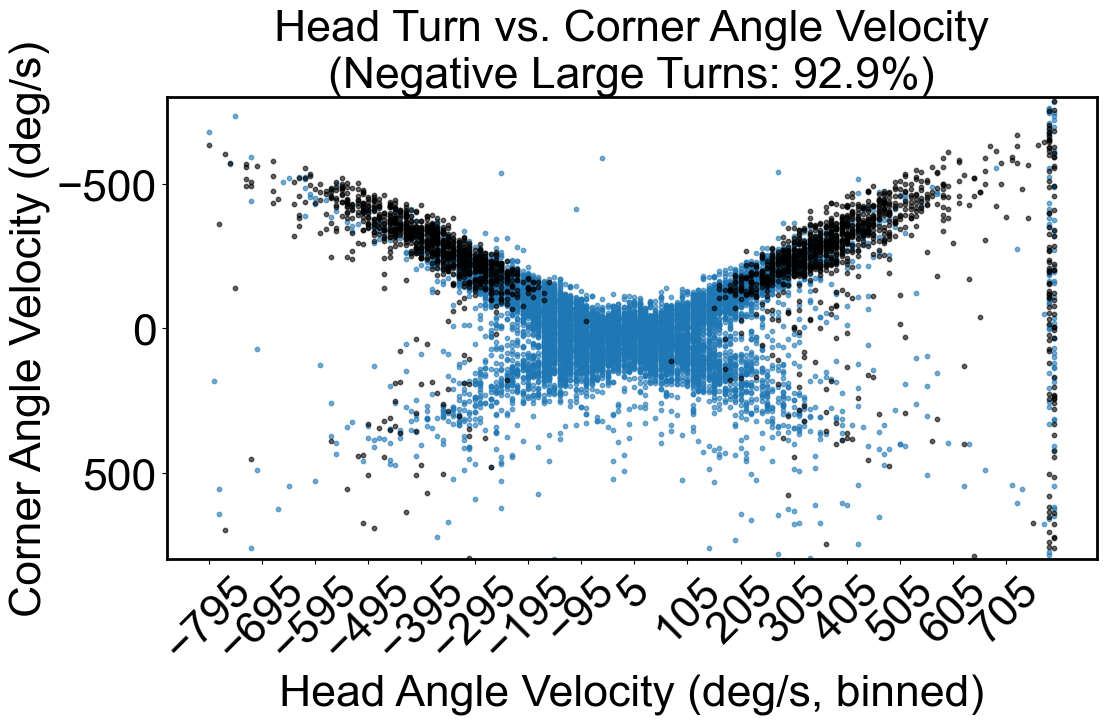

In [871]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---

# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = light.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-800, 810, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins) - 2

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns, alpha=0.6, s=10, color='black', label="Large Turns")

# Customize plot
plt.xticks(bin_centers[::10], rotation=45)
plt.xlabel("Head Angle Velocity (deg/s, binned)")
plt.ylabel("Corner Angle Velocity (deg/s)")
plt.title(f"Head Turn vs. Corner Angle Velocity\n(Negative Large Turns: {negative_ratio:.1f}%)")
plt.ylim(800, -800)  # Inverted y-axis
plt.show()

In [877]:
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -1000
upper_bound = 1000
print(all_angles.shape)
mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles = all_angles[mask]
print(all_angles.shape)

(232607,)
(230447,)


Ratio of NEGATIVE values in corner_angle_at_large_turns: 93.2%


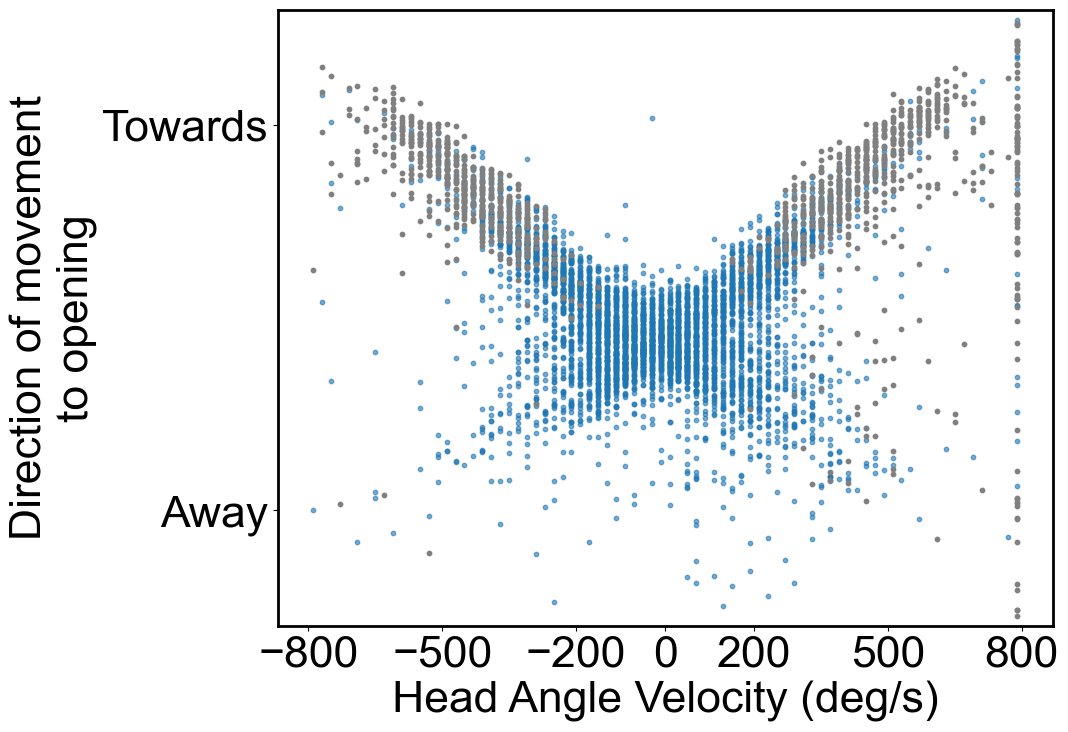

In [1066]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -800
upper_bound = 800
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]


# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-800, 810, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins,right=True) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins,right=True) - 2

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns, alpha=1, s=10, color='grey', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s)")
plt.ylabel("Direction of movement\nto opening")
#plt.title(f"Head Turn vs. Corner Angle Velocity\n(Towards Large Turns: {negative_ratio:.1f}%)")
plt.ylim(800, -800)  # Inverted y-axis
#plt.xlim(-900, 900)  # Inverted y-axis
plt.show()

Ratio of NEGATIVE values in corner_angle_at_large_turns: 93.6%


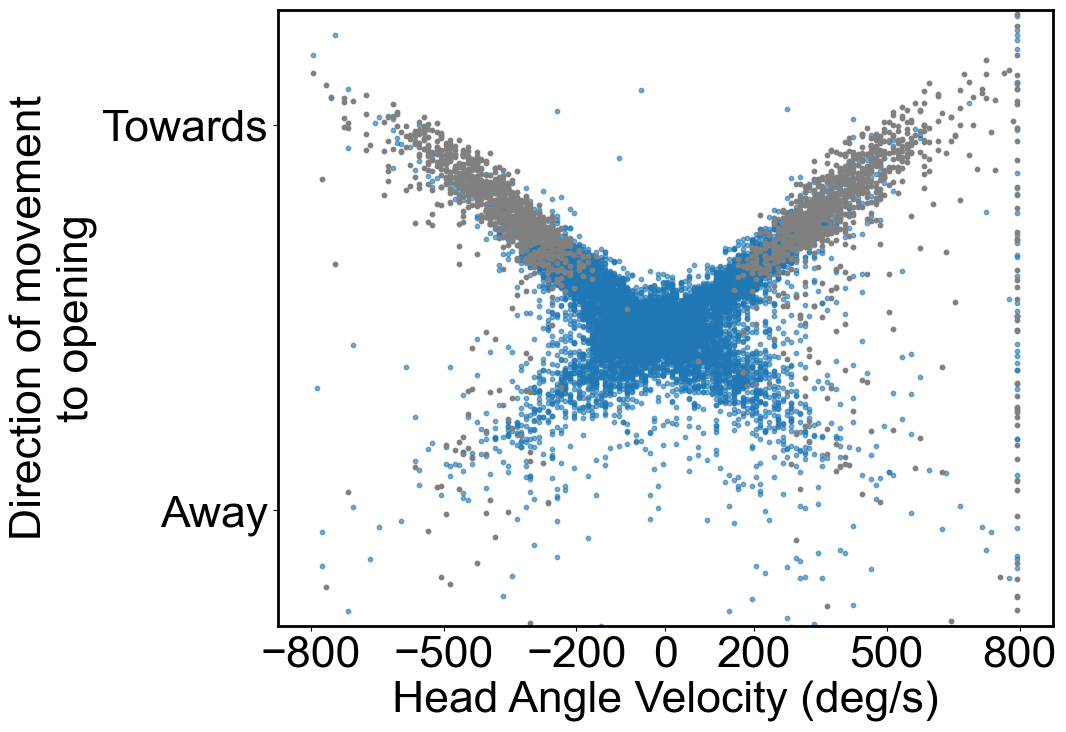

In [1135]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -800
upper_bound = 800
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = light.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]


# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-800, 810, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins,right=True) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins,right=True) - 2

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns, alpha=1, s=10, color='grey', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s)")
plt.ylabel("Direction of movement\nto opening")
#plt.title(f"Head Turn vs. Corner Angle Velocity\n(Towards Large Turns: {negative_ratio:.1f}%)")
plt.ylim(800, -800)  # Inverted y-axis
#plt.xlim(-900, 900)  # Inverted y-axis
plt.show()

In [ ]:
plt.plot()

In [ ]:
angle_at_large_turns
corner_angle_at_large_turns

Ratio of NEGATIVE values in corner_angle_at_large_turns: 93.2%


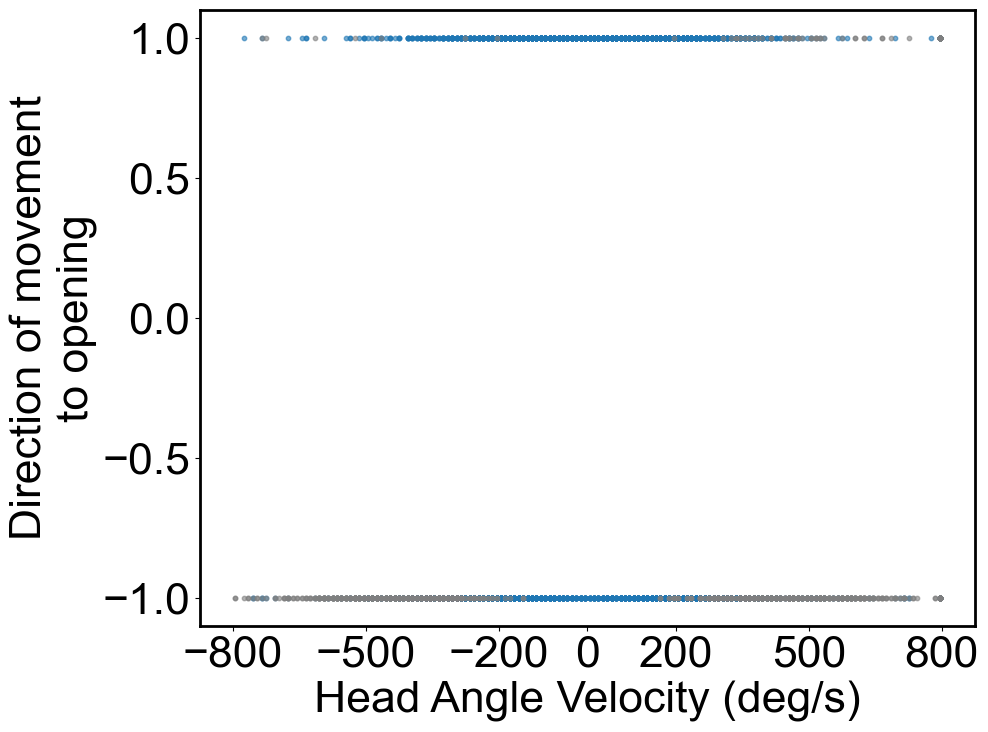

In [1123]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -800
upper_bound = 800
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

corner_angle_at_turns_categorical = np.where(corner_angle_at_turns < 0, -1, np.where(corner_angle_at_turns > 0, 1, corner_angle_at_turns))
corner_angle_at_large_turns_categorical =  np.where(corner_angle_at_large_turns < 0, -1, np.where(corner_angle_at_large_turns > 0, 1, corner_angle_at_large_turns))


# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-800, 810, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins) - 2

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns_categorical, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns_categorical, alpha=0.6, s=10, color='grey', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
#plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s)")
plt.ylabel("Direction of movement\nto opening")
#plt.title(f"Head Turn vs. Corner Angle Velocity\n(Towards Large Turns: {negative_ratio:.1f}%)")
#plt.ylim(800, -800)  # Inverted y-axis
#plt.xlim(-900, 900)  # Inverted y-axis
plt.show()

Text(0, 0.5, 'Head to Corner')

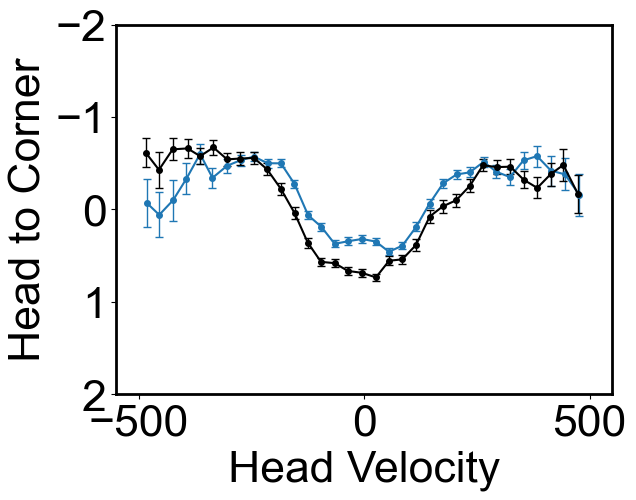

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]
  

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -500
upper_bound = 500
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = light.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

corner_angle_at_turns_categorical = np.where(corner_angle_at_turns < 0, -1, np.where(corner_angle_at_turns > 0, 1, corner_angle_at_turns))
corner_angle_at_large_turns_categorical =  np.where(corner_angle_at_large_turns < 0, -1, np.where(corner_angle_at_large_turns > 0, 1, corner_angle_at_large_turns))
# --- Binning and Plotting ---
bins = np.arange(-500, 510, 30)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4)  # Marker size

plt.ylim(2, -2)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')


# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -500
upper_bound = 500
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

corner_angle_at_turns_categorical = np.where(corner_angle_at_turns < 0, -1, np.where(corner_angle_at_turns > 0, 1, corner_angle_at_turns))
corner_angle_at_large_turns_categorical =  np.where(corner_angle_at_large_turns < 0, -1, np.where(corner_angle_at_large_turns > 0, 1, corner_angle_at_large_turns))
# --- Binning and Plotting ---
bins = np.arange(-500, 510, 30)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4,color = 'black')  # Marker size

plt.ylim(2, -2)
plt.xlim(-550,550)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')



Text(0, 0.5, 'Head to Corner')

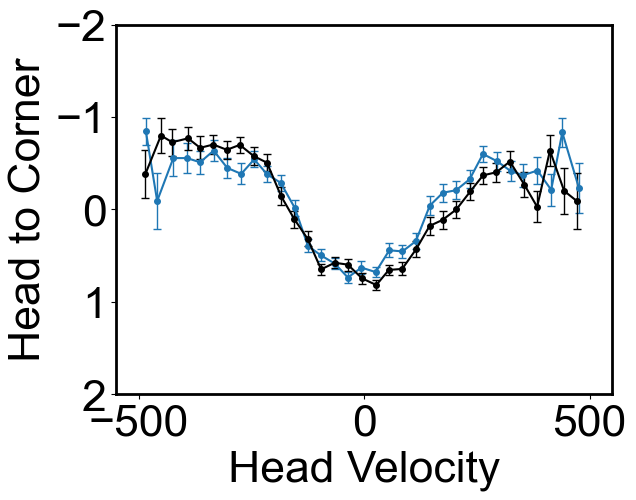

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.task == 'oadark']

light = data[data.turn_direction_left_right == 'left']
dark = data[data.turn_direction_left_right == 'right']

# Get the data
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
lower_bound = -500
upper_bound = 500
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = light.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

corner_angle_at_turns_categorical = np.where(corner_angle_at_turns < 0, -1, np.where(corner_angle_at_turns > 0, 1, corner_angle_at_turns))
corner_angle_at_large_turns_categorical =  np.where(corner_angle_at_large_turns < 0, -1, np.where(corner_angle_at_large_turns > 0, 1, corner_angle_at_large_turns))
# --- Binning and Plotting ---
bins = np.arange(-500, 510, 30)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4)  # Marker size

plt.ylim(2, -2)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')


# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -500
upper_bound = 500
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]

corner_angle_at_turns_categorical = np.where(corner_angle_at_turns < 0, -1, np.where(corner_angle_at_turns > 0, 1, corner_angle_at_turns))
corner_angle_at_large_turns_categorical =  np.where(corner_angle_at_large_turns < 0, -1, np.where(corner_angle_at_large_turns > 0, 1, corner_angle_at_large_turns))
# --- Binning and Plotting ---
bins = np.arange(-500, 510, 30)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4,color = 'black')  # Marker size

plt.ylim(2, -2)
plt.xlim(-550,550)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')


(800.0, -800.0)

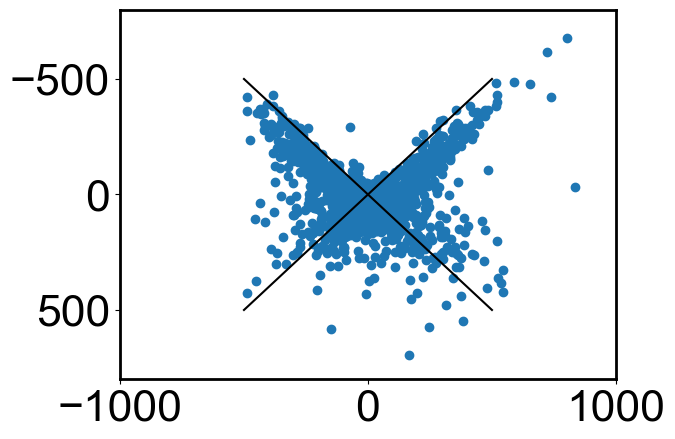

In [9]:
plt.scatter(angle_at_turns[::5],corner_angle_at_turns[::5])
plt.plot([-500,500],[-500,500],color = 'black')
plt.plot([-500,500],[500,-500],color = 'black')
plt.xlim(-1000,1000)
plt.ylim(800,-800)

(800.0, -800.0)

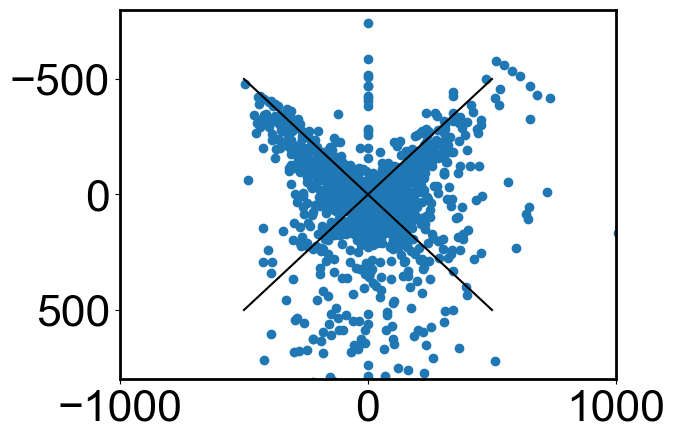

In [1152]:
plt.scatter(all_angles[::100],all_angles_corner[::100])
plt.plot([-500,500],[-500,500],color = 'black')
plt.plot([-500,500],[500,-500],color = 'black')
plt.xlim(-1000,1000)
plt.ylim(800,-800)

(800.0, -800.0)

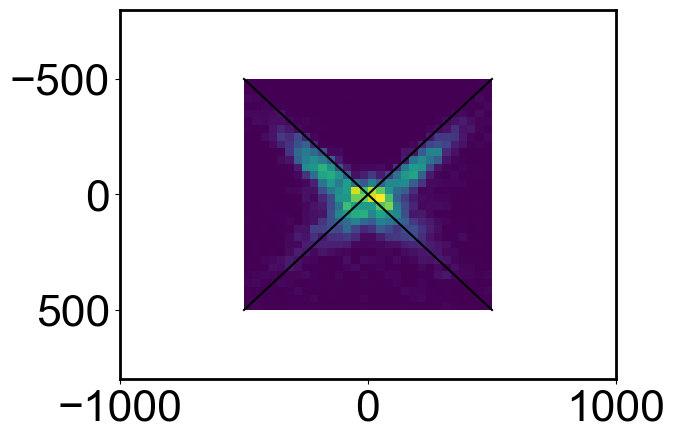

In [1164]:
plt.hist2d(angle_at_turns[::],corner_angle_at_turns[::],range=[[-500, 500], [-500, 500]],bins = [30,30])
plt.plot([-500,500],[-500,500],color = 'black')
plt.plot([-500,500],[500,-500],color = 'black')
plt.xlim(-1000,1000)
plt.ylim(800,-800)

In [ ]:

# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-800, 810, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins) - 2

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns_categorical, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns_categorical, alpha=0.6, s=10, color='grey', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
#plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s)")
plt.ylabel("Direction of movement\nto opening")
#plt.title(f"Head Turn vs. Corner Angle Velocity\n(Towards Large Turns: {negative_ratio:.1f}%)")
#plt.ylim(800, -800)  # Inverted y-axis
#plt.xlim(-900, 900)  # Inverted y-axis
plt.show()

In [1073]:
bins.shape

(81,)

In [ ]:
head_to_corner_vel_mean = []
head_vel_mean =[]
for  i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices==i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
head_to_corner_vel_mean =  np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)

plt.plot(head_vel_mean[:-1],head_to_corner_vel_mean[:-1])
plt.ylim(1,-1)




(1.5, -1.5)

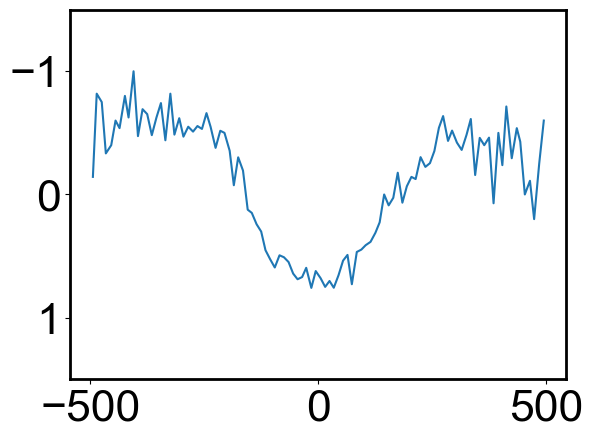

In [1124]:
plt.plot(head_vel_mean[:-1],head_to_corner_vel_mean[:-1])
plt.ylim(1.5,-1.5)

Text(0, 0.5, 'Head to Corner')

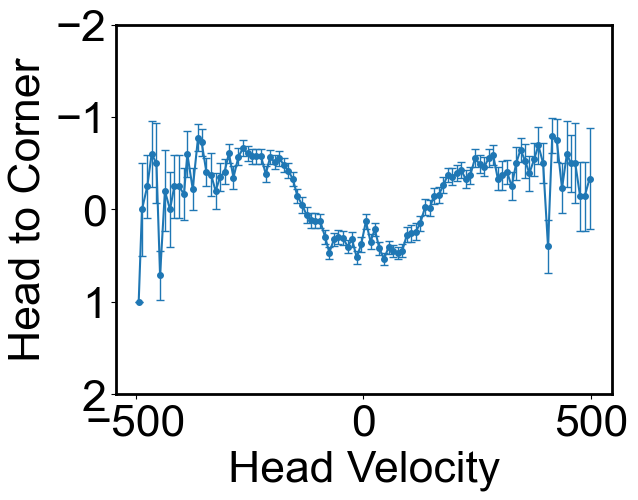

In [1119]:
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4)  # Marker size

plt.ylim(2, -2)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')


Text(0, 0.5, 'Head to Corner')

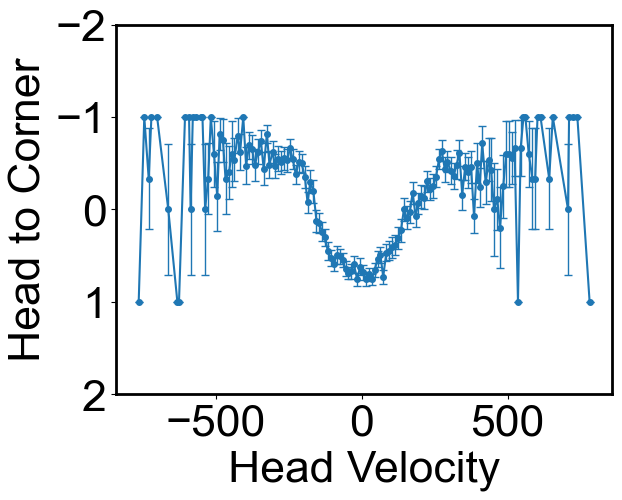

In [1125]:
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices):
    inds_to_mean = np.where(bin_indices == i)
    bin_head_vel_means = angle_at_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4)  # Marker size

plt.ylim(2, -2)
plt.xlabel('Head Velocity')
plt.ylabel('Head to Corner')

In [ ]:
angle_at_large_turns
corner_angle_at_large_turns

Text(0, 0.5, 'Largest Head to Corner')

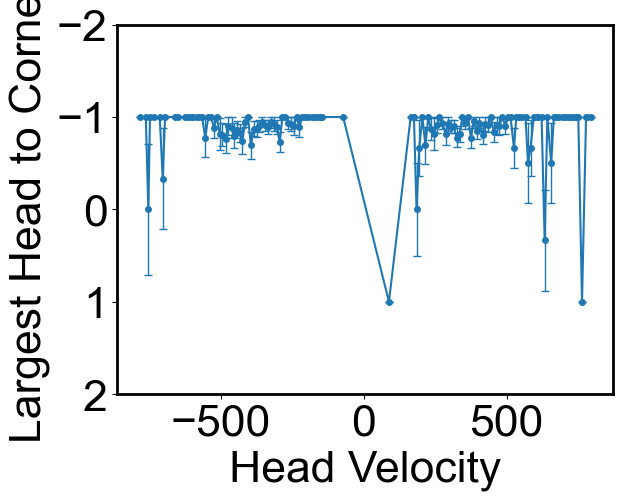

In [1111]:
head_to_corner_vel_mean = []
head_vel_mean = []
head_corner_vels_std_err = []  # New list for standard errors

for i in np.unique(bin_indices_large):
    inds_to_mean = np.where(bin_indices_large == i)
    bin_head_vel_means = angle_at_large_turns[inds_to_mean]
    bin_head_corner_vels = corner_angle_at_large_turns_categorical[inds_to_mean]
    
    bin_head_vel_means_mean = np.nanmean(bin_head_vel_means)
    bin_head_corner_vels_mean = np.nanmean(bin_head_corner_vels)
    
    # Calculate standard error for this bin
    # Standard error = standard deviation / sqrt(n)
    n = np.sum(~np.isnan(bin_head_corner_vels))  # Count non-NaN values
    if n > 0:
        std_dev = np.nanstd(bin_head_corner_vels)
        std_err = std_dev / np.sqrt(n)
    else:
        std_err = np.nan
    
    head_to_corner_vel_mean.append(bin_head_corner_vels_mean)
    head_vel_mean.append(bin_head_vel_means_mean)
    head_corner_vels_std_err.append(std_err)

head_to_corner_vel_mean = np.array(head_to_corner_vel_mean)
head_vel_mean = np.array(head_vel_mean)
head_corner_vels_std_err = np.array(head_corner_vels_std_err)

# Create the plot with error bars
plt.errorbar(head_vel_mean[:-1], head_to_corner_vel_mean[:-1], 
             yerr=head_corner_vels_std_err[:-1], 
             fmt='o-',  # Use circles connected by lines
             capsize=3,  # Add caps to error bars
             elinewidth=1,  # Error bar line width
             markersize=4)  # Marker size

plt.ylim(2, -2)
plt.xlabel('Head Velocity')
plt.ylabel('Largest Head to Corner')

In [954]:
np.digitize(angle_at_turns, bins)

array([54, 93, 74, ..., 50, 81, 69], dtype=int64)

In [946]:
bin_indices

array([52, 91, 72, ..., 48, 79, 67], dtype=int64)

Ratio of NEGATIVE values in corner_angle_at_large_turns: 93.2%


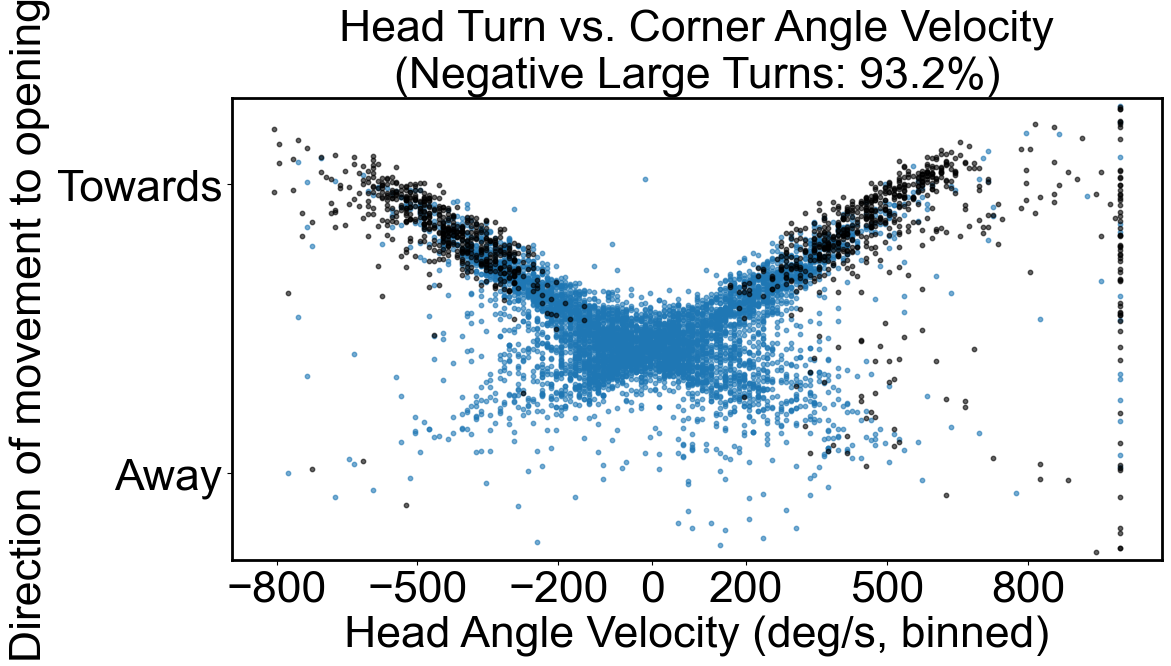

In [912]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -800
upper_bound = 800
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]


# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-1000, 1010, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins) - 2

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns, alpha=0.6, s=10, color='black', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s, binned)")
plt.ylabel("Direction of movement to opening")
plt.title(f"Head Turn vs. Corner Angle Velocity\n(Negative Large Turns: {negative_ratio:.1f}%)")
plt.ylim(800, -800)  # Inverted y-axis
plt.show()

Ratio of NEGATIVE values in corner_angle_at_large_turns: 50.7%


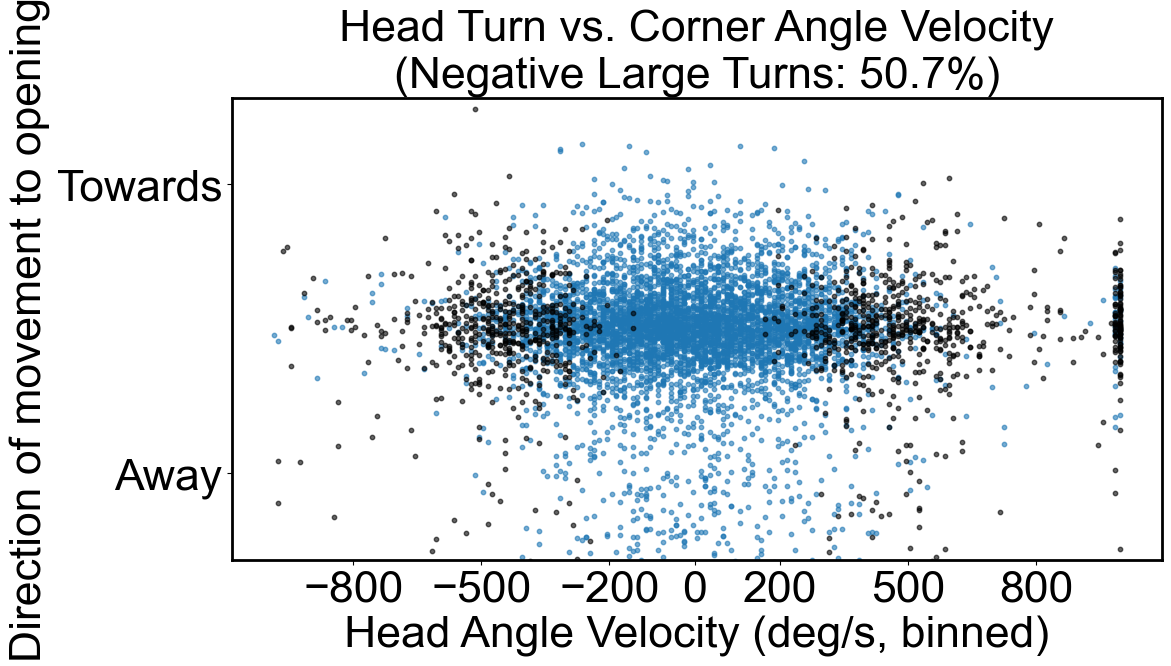

In [909]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Processing ---
# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
lower_bound = -800
upper_bound = 800
#mask = (all_angles >= lower_bound) & (all_angles <= upper_bound)
#all_angles[~(all_angles >= lower_bound) & (all_angles <= upper_bound)] = 0
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60
# Get indices where angles match turns (common_indices) and large turns (large_indices)
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]
large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Remove overlapping indices (ensure no point appears in both plots)
common_indices_filtered = np.setdiff1d(common_indices, large_indices)

# Get values for filtered indices
corner_angle_at_turns = all_angles_corner[common_indices_filtered]
angle_at_turns = all_angles[common_indices_filtered]
corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]


# --- Compute Ratio of NEGATIVE Values in Large Turns ---
negative_ratio = np.mean(corner_angle_at_large_turns < 0) * 100  # Percentage
print(f"Ratio of NEGATIVE values in corner_angle_at_large_turns: {negative_ratio:.1f}%")

# --- Binning and Plotting ---
bins = np.arange(-1000, 1010, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bin indices for both datasets (no jitter)
bin_indices = np.digitize(angle_at_turns, bins) - 2  # 0-indexed
bin_indices_large = np.digitize(angle_at_large_turns, bins) - 2

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10, color='tab:blue', label="Regular Turns")
plt.scatter(bin_centers[bin_indices_large], corner_angle_at_large_turns, alpha=0.6, s=10, color='black', label="Large Turns")

# Customize plot with ONLY the requested changes
plt.xticks([-800, -500, -200, 0, 200, 500, 800])
plt.yticks([-500, 500], ['Towards', 'Away'])
plt.xlabel("Head Angle Velocity (deg/s, binned)")
plt.ylabel("Direction of movement to opening")
plt.title(f"Head Turn vs. Corner Angle Velocity\n(Negative Large Turns: {negative_ratio:.1f}%)")
plt.ylim(800, -800)  # Inverted y-axis
plt.show()

(array([  255.,   491.,  2907., 20878., 94664., 88464., 19190.,  2830.,
          530.,   238.]),
 array([-9.99227952e+02, -7.99418036e+02, -5.99608119e+02, -3.99798203e+02,
        -1.99988287e+02, -1.78370206e-01,  1.99631546e+02,  3.99441462e+02,
         5.99251379e+02,  7.99061295e+02,  9.98871211e+02]),
 <BarContainer object of 10 artists>)

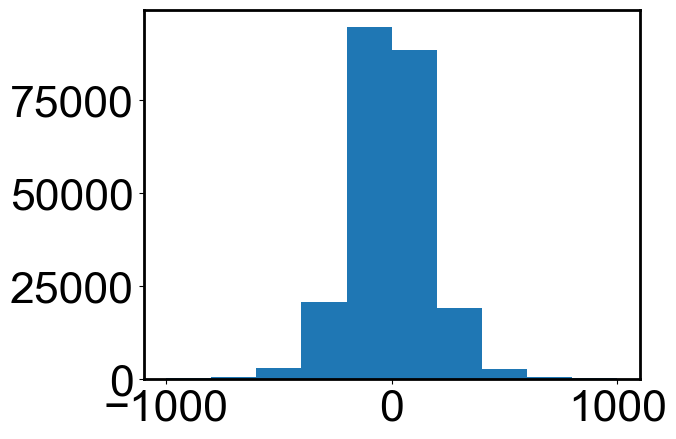

In [874]:
plt.hist(all_angles)

In [848]:
dark.shape

(1247, 297)

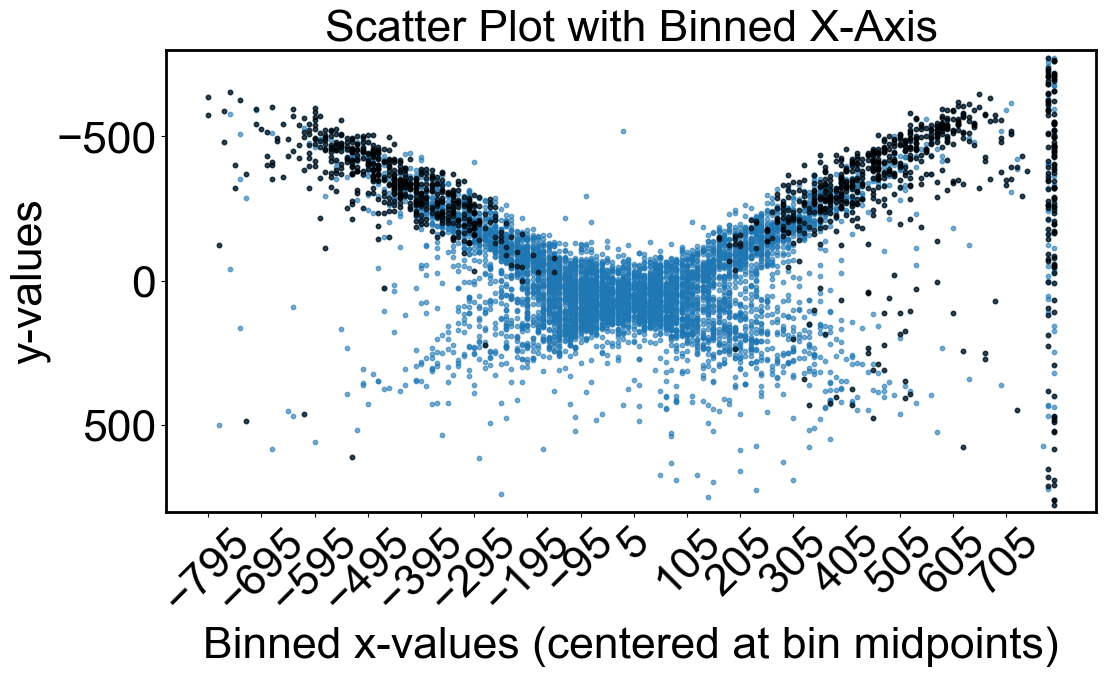

In [851]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.avg_lateral_error<0] 
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60        # Random y-values (e.g., categories or scores)
large_turns = dark.head_turn_velocity.to_numpy() * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

large_indices = np.intersect1d(all_angles, large_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

corner_angle_at_large_turns = all_angles_corner[large_indices]
angle_at_large_turns = all_angles[large_indices]



# Define bins (from -800 to 800 in steps of 10)
bins = np.arange(-800, 810, 10)

# Assign each x-value to a bin
bin_indices = np.digitize(angle_at_turns, bins)-2   # Subtract 1 to make bins 0-indexed

# Compute bin centers for x-axis labels
bin_centers = (bins[:-1] + bins[1:]) / 2


bin_indices_large = np.digitize(angle_at_large_turns, bins)-2   # Subtract 1 to make bins 0-indexed

# Compute bin centers for x-axis labels
bin_centers_large = (bins[:-1] + bins[1:]) / 2
# Add small jitter to x-positions to avoid overplotting
x_jittered = bin_centers[bin_indices] + np.random.uniform(-3, 3, len(angle_at_turns))

# Create scatter plot
plt.figure(figsize=(12, 6))

plt.scatter(bin_centers[bin_indices], corner_angle_at_turns, alpha=0.6, s=10,color ='tab:blue')
plt.scatter(bin_centers_large[bin_indices_large], corner_angle_at_large_turns, alpha=0.6, s=10,color ='black')

# Customize plot
plt.xticks(bin_centers[::10], rotation=45)  # Show every 5th bin label
plt.xlabel("Binned x-values (centered at bin midpoints)")
plt.ylabel("y-values")
plt.title("Scatter Plot with Binned X-Axis")
plt.ylim(800,-800)
plt.show()

(array([  34.,  188.,  735., 1894., 2455., 2377., 1621.,  715.,  163.,
         233.]),
 array([-795., -636., -477., -318., -159.,    0.,  159.,  318.,  477.,
         636.,  795.]),
 <BarContainer object of 10 artists>)

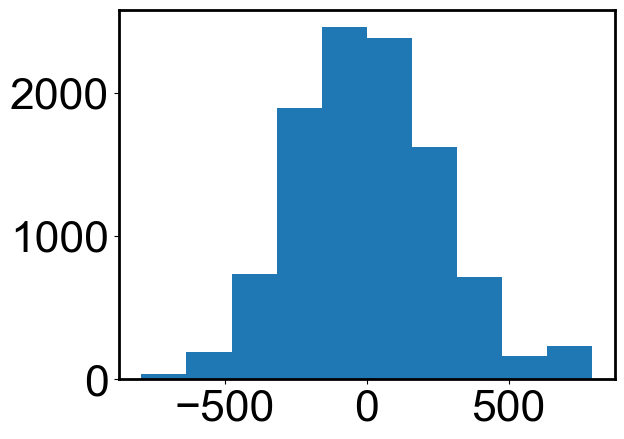

In [815]:
plt.hist(bin_centers[bin_indices]) 

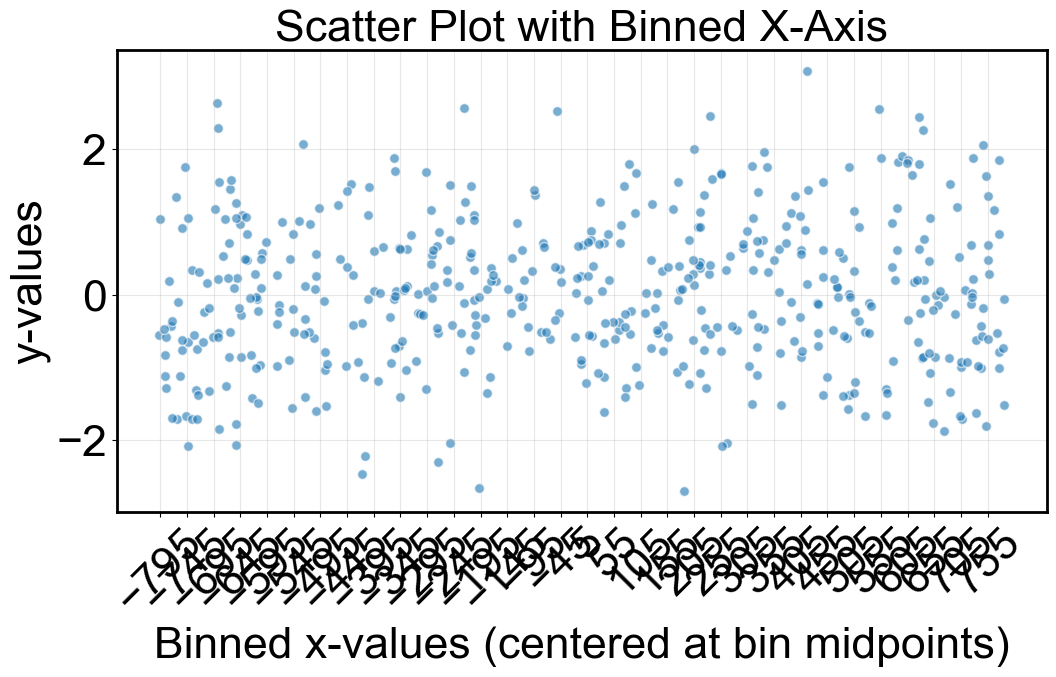

In [778]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
x = np.random.uniform(-800, 800, 500)  # Continuous x-values (-800 to 800)
y = np.random.randn(500)               # Random y-values (e.g., categories or scores)

# Define bins (from -800 to 800 in steps of 10)
bins = np.arange(-800, 810, 10)

# Assign each x-value to a bin
bin_indices = np.digitize(x, bins) - 1  # Subtract 1 to make bins 0-indexed

# Compute bin centers for x-axis labels
bin_centers = (bins[:-1] + bins[1:]) / 2

# Add small jitter to x-positions to avoid overplotting
x_jittered = bin_centers[bin_indices] + np.random.uniform(-3, 3, len(x))

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(x_jittered, y, alpha=0.6, edgecolors='w', s=50)

# Customize plot
plt.xticks(bin_centers[::5], rotation=45)  # Show every 5th bin label
plt.xlabel("Binned x-values (centered at bin midpoints)")
plt.ylabel("y-values")
plt.title("Scatter Plot with Binned X-Axis")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
counts, bin_edge = np.histogram(angle_at_turns,)

In [717]:
binned_result = bin_indices(angle_at_turns)

In [725]:
binned_result[3]

[116, 117, 118]

In [721]:
len(binned_result)

160

In [706]:
bin_numbers = np.digitize(angle_at_turns, bin_edges)

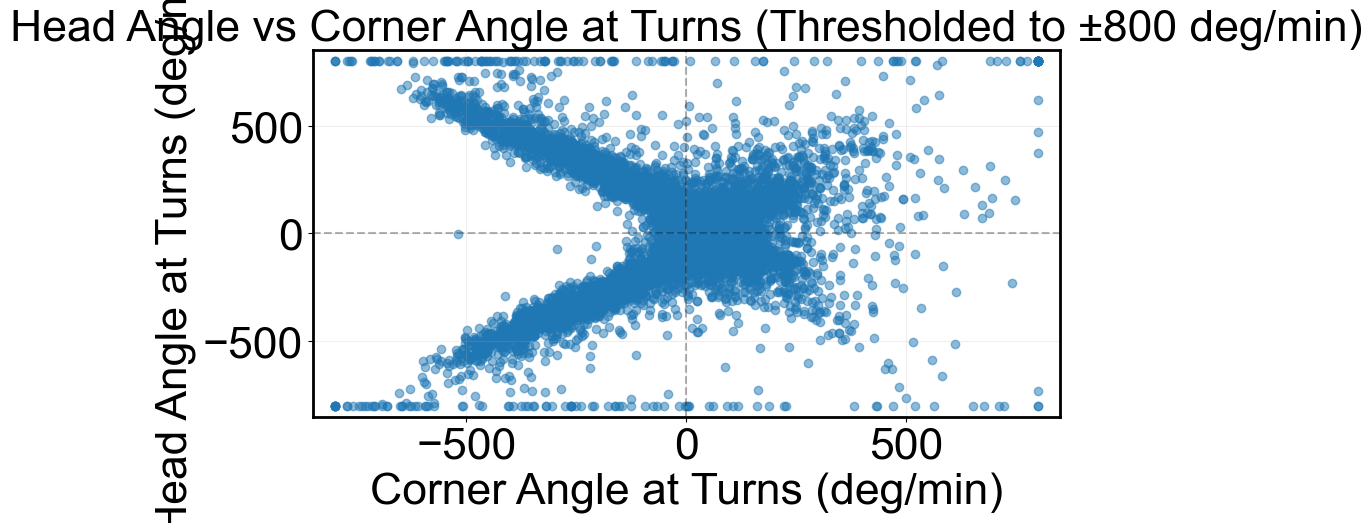

In [610]:
import matplotlib.pyplot as plt
import numpy as np

# Get the data
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60

# Get indices where angles match turns
common_indices = np.intersect1d(all_angles, all_turns, return_indices=True)[1]

# Get the values at turns
corner_angle_at_turns = all_angles_corner[common_indices]
angle_at_turns = all_angles[common_indices]

# Apply thresholding (-800 to 800)
corner_angle_at_turns = np.clip(corner_angle_at_turns, -800, 800)
angle_at_turns = np.clip(angle_at_turns, -800, 800)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(corner_angle_at_turns, angle_at_turns, alpha=0.5)

# Add labels and title
plt.xlabel('Corner Angle at Turns (deg/min)')
plt.ylabel('Head Angle at Turns (deg/min)')
plt.title('Head Angle vs Corner Angle at Turns (Thresholded to ±800 deg/min)')

# Add reference lines
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Set axis limits to make sure we see the thresholds
plt.xlim(-850, 850)
plt.ylim(-850, 850)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

(array([1.68372845e-05, 7.07165948e-05, 4.40575611e-04, 1.17860991e-03,
        2.02889278e-03, 1.88465338e-03, 4.61902838e-04, 1.15054777e-04,
        3.08683549e-05, 2.18884698e-05]),
 array([-800., -640., -480., -320., -160.,    0.,  160.,  320.,  480.,
         640.,  800.]),
 <BarContainer object of 10 artists>)

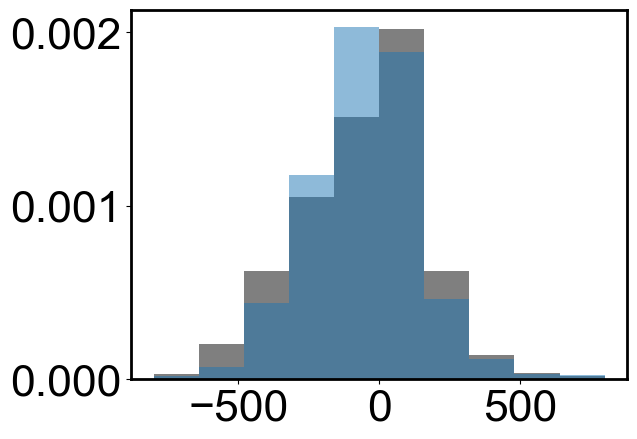

In [ ]:
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60



plt.hist(all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]],range = (-800,800),color = 'black',alpha = .5,density=True)

all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60

turn_inds = np.argwhere(all_angles == all_turns )
turns_from_angles =  all_angles[turn_inds]


plt.hist(all_angles_corner[np.intersect1d(all_angles, all_turns,return_indices=True)[1]],range = (-800,800),color = 'tab:blue',alpha = .5,density=True)

In [598]:
all_angles.shape

(251852,)

In [597]:
all_angles_corner.shape

(251852,)

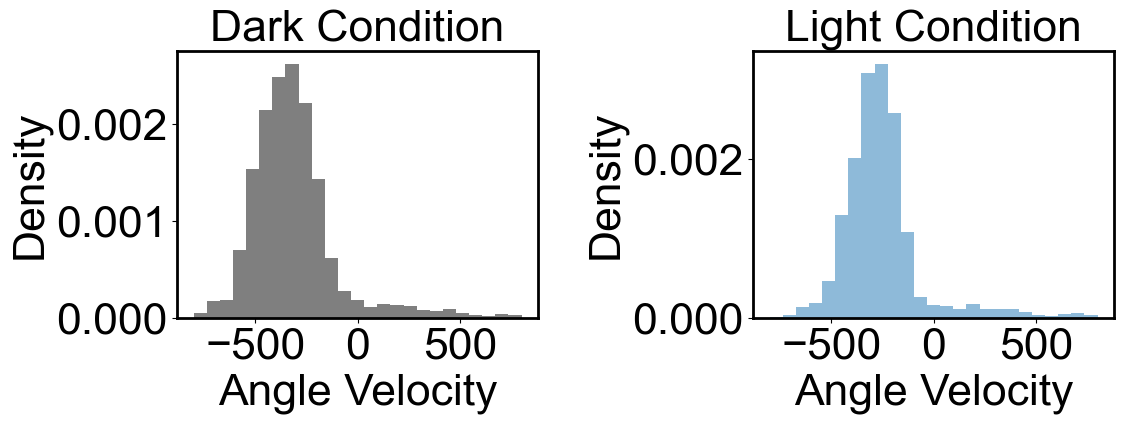

In [596]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Dark condition plot
all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = dark.head_turn_velocity.to_numpy() * 60

turn_inds = np.argwhere(all_angles == all_turns)
turns_from_angles = all_angles[turn_inds]

ax1.hist(all_angles_corner[np.intersect1d(all_angles, all_turns, return_indices=True)[1]], 
         range=(-800, 800), color='black', alpha=0.5, density=True,bins = 25)
ax1.set_title('Dark Condition')
ax1.set_xlabel('Angle Velocity')
ax1.set_ylabel('Density')

# Light condition plot
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns =  light.head_turn_velocity.to_numpy() * 60

turn_inds = np.argwhere(all_angles == all_turns)
turns_from_angles = all_angles[turn_inds]

ax2.hist(all_angles_corner[np.intersect1d(all_angles, all_turns, return_indices=True)[1]], 
         range=(-800, 800), color='tab:blue', alpha=0.5, density=True,bins = 25)
ax2.set_title('Light Condition')
ax2.set_xlabel('Angle Velocity')
ax2.set_ylabel('Density')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60

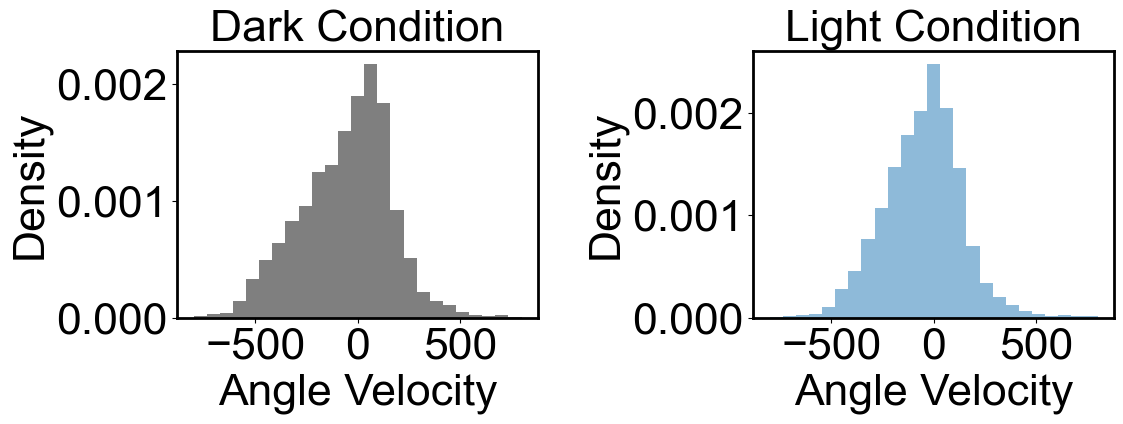

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Dark condition plot
dark_all_angles = flatten_list_of_arrays(dark.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60
large_turns = dark.head_turn_velocity.to_numpy() * 60



ax1.hist(all_angles_corner[np.intersect1d(all_angles, all_turns, return_indices=True)[1]], 
         range=(-800, 800), color='black', alpha=0.5, density=True,bins = 25)
ax1.set_title('Dark Condition')
ax1.set_xlabel('Angle Velocity')
ax1.set_ylabel('Density')

# Light condition plot
all_angles = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
all_angles_corner = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60



ax2.hist(all_angles_corner[np.intersect1d(all_angles, all_turns, return_indices=True)[1]], 
         range=(-800, 800), color='tab:blue', alpha=0.5, density=True,bins = 25)
ax2.set_title('Light Condition')
ax2.set_xlabel('Angle Velocity')
ax2.set_ylabel('Density')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Text(0, 0.5, 'porportion of movments')

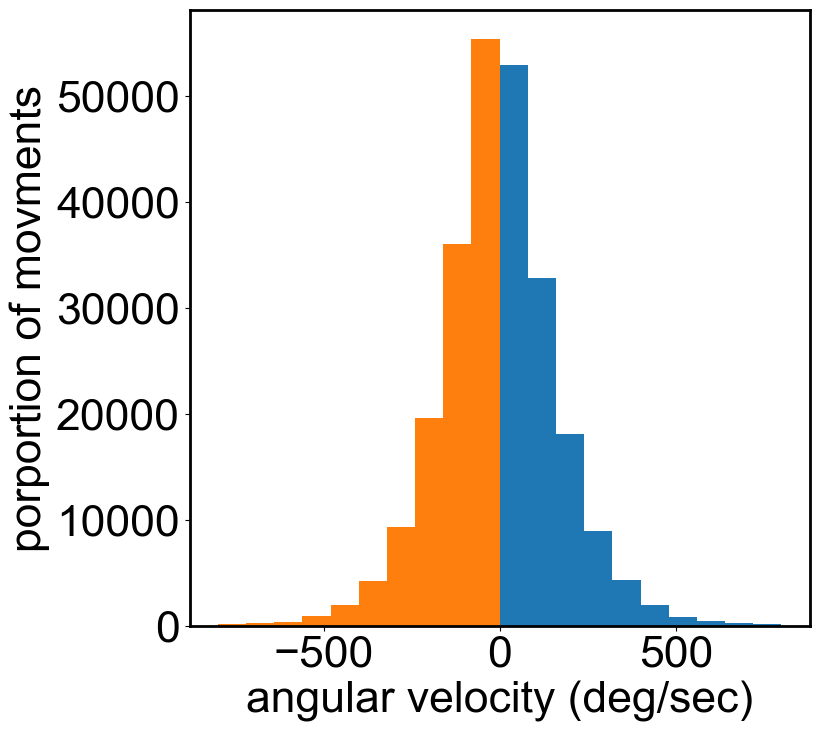

In [532]:
all_turns = flatten_list_of_arrays(light.head_angle_velocity.to_list()) * 60
pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,range = (0,800))
plt.hist(neg_turns,range = (-800,0))
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('porportion of movments')

Text(0, 0.5, 'porportion of movments')

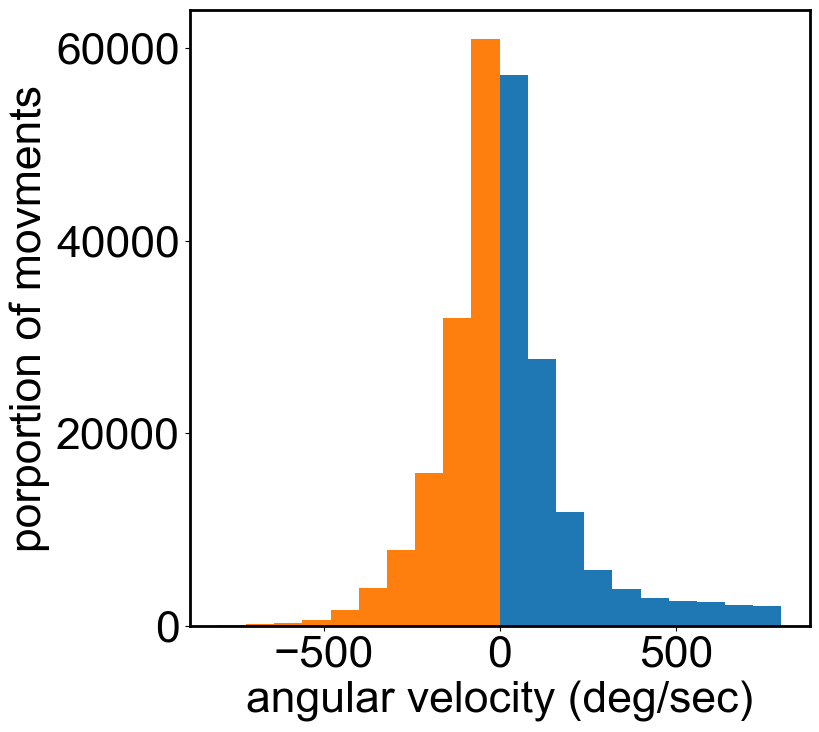

In [603]:
all_turns = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) * 60

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,range = (0,800))
plt.hist(neg_turns,range = (-800,0))
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('porportion of movments')



Text(0, 0.5, 'porportion of movments')

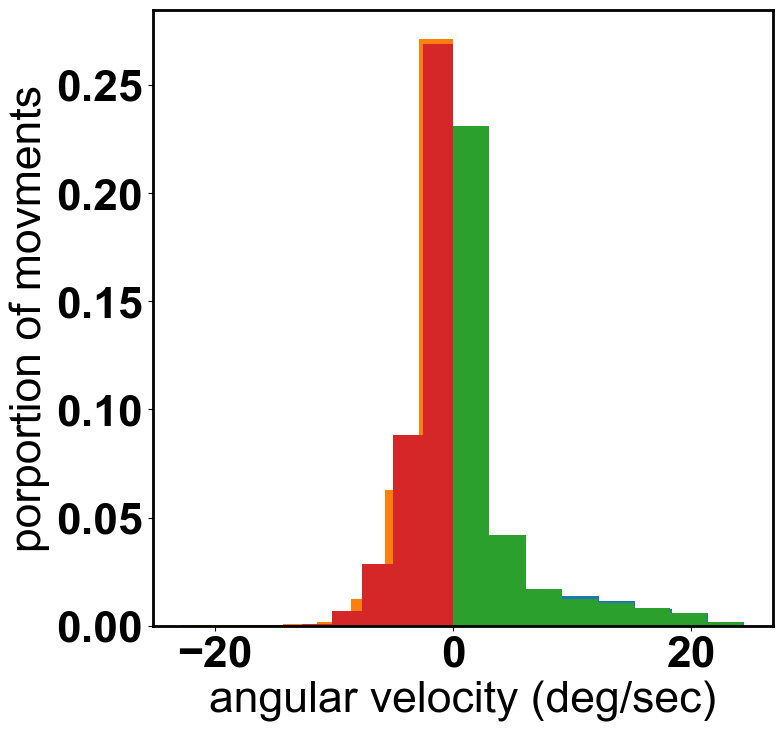

In [317]:
all_turns = flatten_list_of_arrays(light.head_corner_angle_velocity.to_list()) 

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,density=True,bins=8)
plt.hist(neg_turns,density=True,bins=8)
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('porportion of movments')

all_turns = flatten_list_of_arrays(dark.head_corner_angle_velocity.to_list()) 

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]

plt.hist(pos_turns,density=True,bins=8)
plt.hist(neg_turns,density=True,bins=8)
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('porportion of movments')

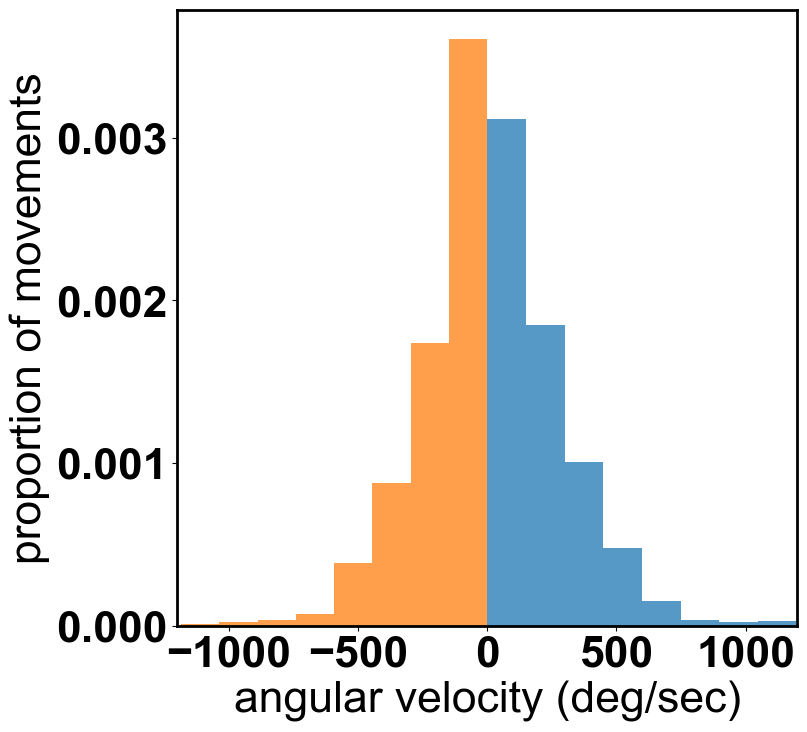

In [ ]:
# Create figure and axis using plt.subplots()
fig, ax = plt.subplots(figsize=(8, 8))
# get data 
all_turns = flatten_list_of_arrays(dark.head_turn_velocities.to_list()) * 60
pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
# Plot histograms for positive and negative turns
ax.hist(pos_turns, density=True, bins=8, alpha=0.75, label='Positive Turns')
ax.hist(neg_turns, density=True, bins=8, alpha=0.75, label='Negative Turns')

# Set x-axis ticks and labels
ax.set_xticks([-1000, -500, 0, 500, 1000])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('proportion of movements')

# Adjust x-axis limits to include all ticks
ax.set_xlim(-1200, 1200)



plt.show()

Text(0, 0.5, 'porportion of largest movments')

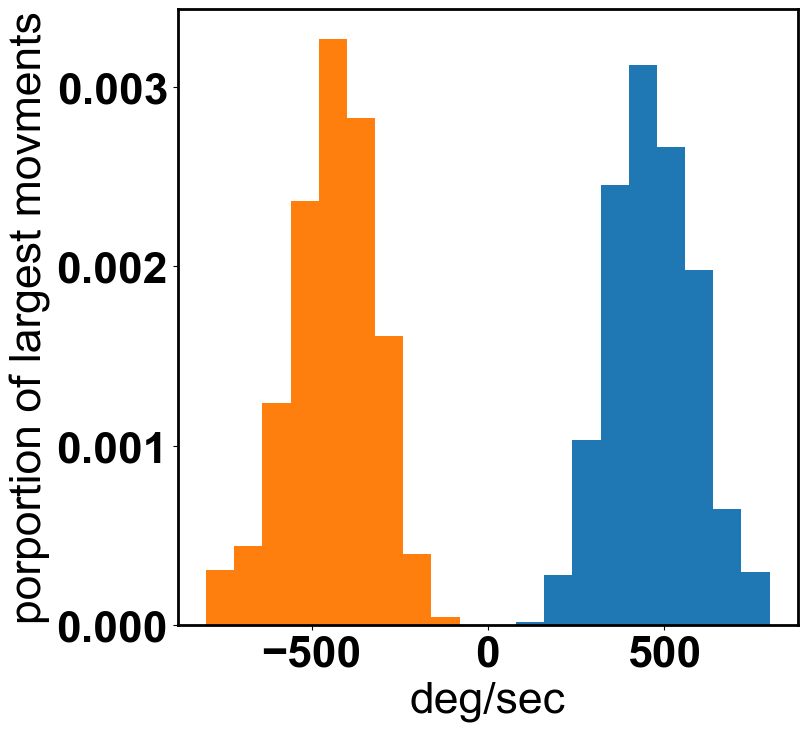

In [ ]:
all_turns = dark.head_turn_velocity.to_numpy()* 60

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,range=(0,800),density=True)
plt.hist(neg_turns,range=(-800,0),density=True)

plt.xlabel('deg/sec')
plt.ylabel('porportion of largest movments')

light.positive_peaks

In [427]:
light.distance_at_head_turn.median()

8.397997306608225

In [424]:
dark.num_turn.median()

7.0

In [425]:
light.num_turn.median()

6.0

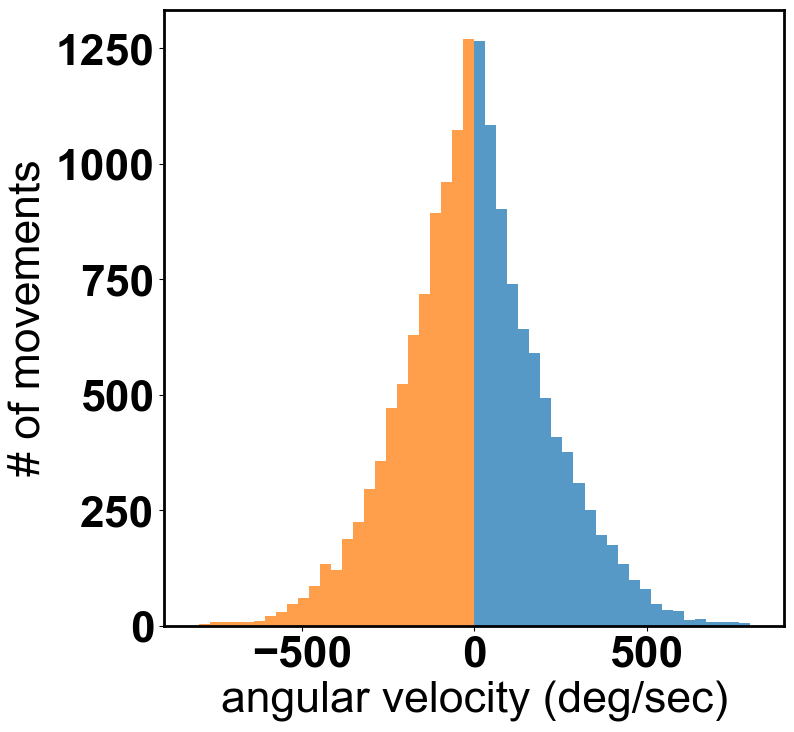

In [418]:
# Create figure and axis using plt.subplots()
fig, ax = plt.subplots(figsize=(8, 8))
# get data 
all_turns = flatten_list_of_arrays(light.head_turn_velocities.to_list()) * 60
pos_turns = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
neg_turns = flatten_list_of_arrays(light.negative_heights.to_list()) * 60
# Plot histograms for positive and negative turns
ax.hist(pos_turns, density=False, bins=25, alpha=0.75,range= (0,800),label='Positive Turns')
ax.hist(neg_turns, density=False, bins=25, alpha=0.75,range= (-800,0),label='Negative Turns')

# Set x-axis ticks and labels
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')

# Adjust x-axis limits to include all ticks
ax.set_xlim(-900, 900)


#ax.set_ylim(0, 0.006)
plt.show()

fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\light_all_head_turns.pdf",dpi = 300, transparent=True)

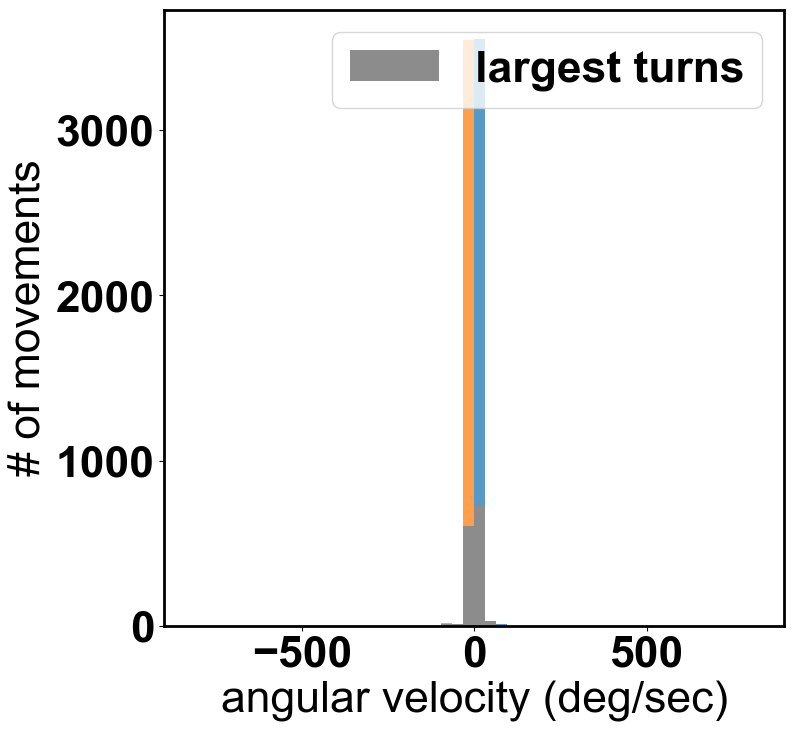

In [447]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  



dark = data[data.task == 'oadark']

# Get full dataset
full_pos = flatten_list_of_arrays(dark.positive_heights.to_list()) 
full_neg = flatten_list_of_arrays(dark.negative_heights.to_list()) 

# Get largest movements subset
all_largest = dark.head_turn_velocity.to_numpy() 
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
ax.legend(handles=legend_elements)

plt.show()

In [503]:
full_neg

array([-273.4613816 , -131.42718747, -456.19230681, ..., -302.03174152,
       -112.64705765, -418.06014858])

In [502]:
full_pos

array([236.42870041, 420.20595588, 203.26161927, ..., 120.01309564,
       118.73483543, 342.17924718])

In [586]:
full_pos

array([14185.7220244 , 25212.35735299, 12195.69715642, ...,
        7200.78573836,  7124.09012608, 20530.75483056])

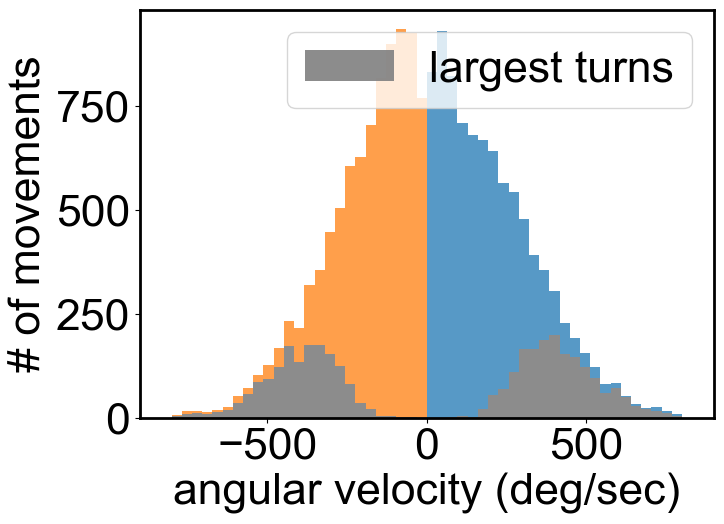

In [465]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  



light = data

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [325]:
len(full_pos) 

6515

In [328]:
len(all_largest)

2205

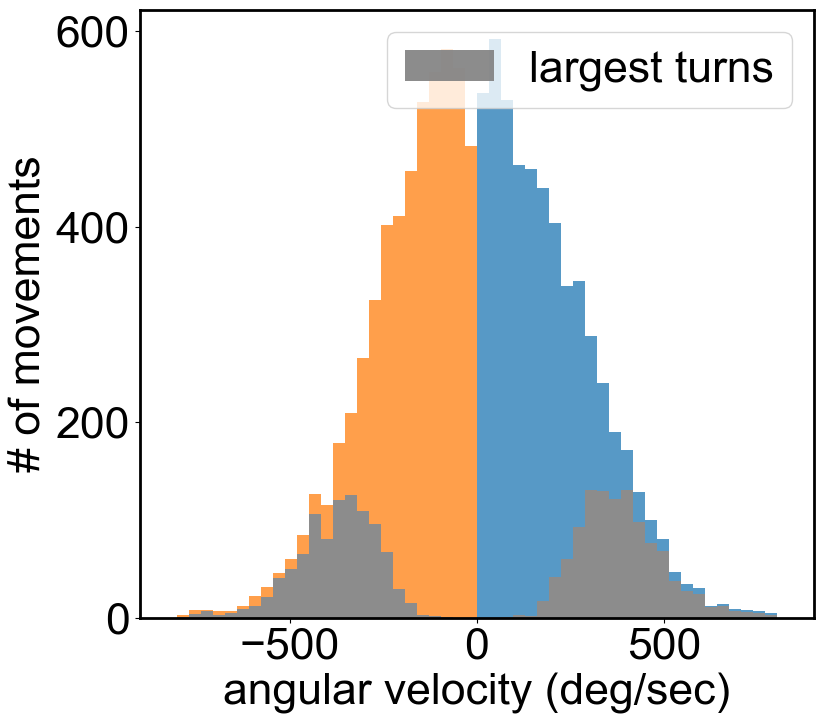

In [899]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  



light = data[data.task == 'oa']

# Create figure
fig, ax = plt.subplots(figsize=(9, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos,range=(0,800))
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos,range=(0,800))
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg,range=(-800,0))
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg,range=(-800,0))
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\light_all_head_turns.pdf",dpi = 300, transparent=True)

(array([  3.,   8.,   6.,   9.,   6.,  11.,  18.,  22.,  43.,  54.,  68.,
        106., 108., 137., 215., 192., 270., 366., 370., 404., 481., 495.,
        527., 570., 548., 456.]),
 array([-800.        , -769.23076923, -738.46153846, -707.69230769,
        -676.92307692, -646.15384615, -615.38461538, -584.61538462,
        -553.84615385, -523.07692308, -492.30769231, -461.53846154,
        -430.76923077, -400.        , -369.23076923, -338.46153846,
        -307.69230769, -276.92307692, -246.15384615, -215.38461538,
        -184.61538462, -153.84615385, -123.07692308,  -92.30769231,
         -61.53846154,  -30.76923077,    0.        ]),
 <BarContainer object of 26 artists>)

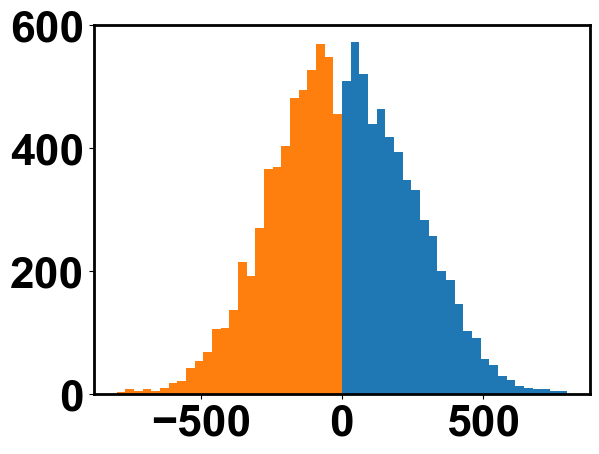

In [450]:
plt.hist(full_pos,range=(0,800),bins=26)
plt.hist(full_neg,range=(-800,0),bins=26)

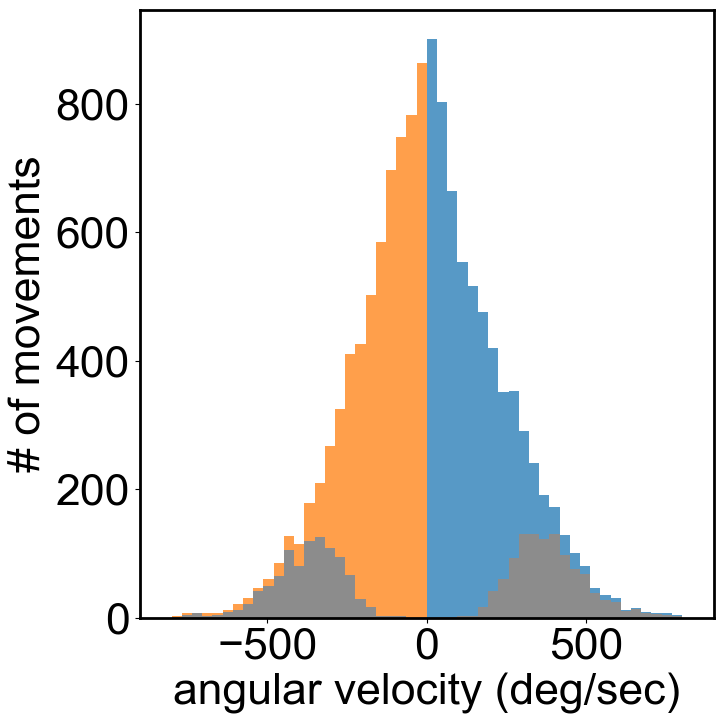

In [135]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  



light = data[data.task == 'oa']

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
#ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

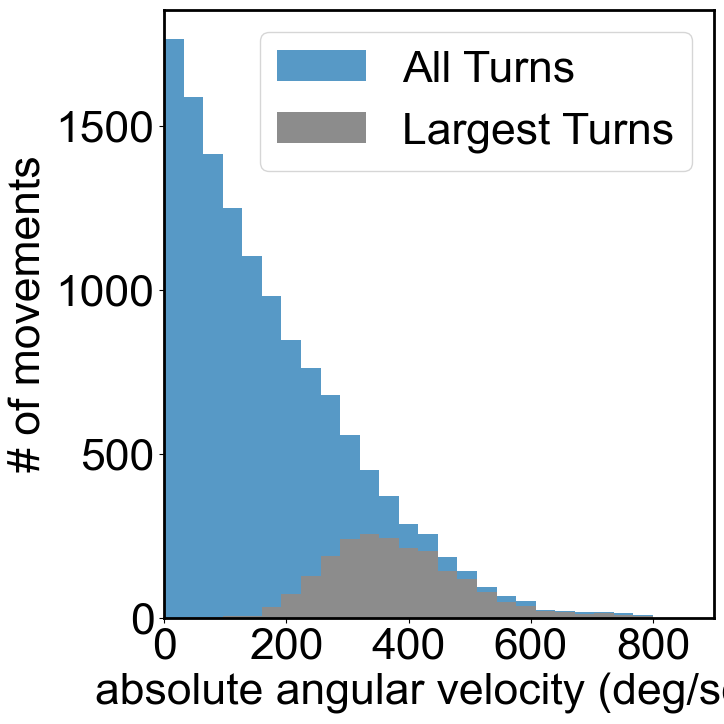

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Assuming 'data' is already prepared as in your original code
light = data[data.task == 'oa']

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = np.abs(flatten_list_of_arrays(light.negative_heights.to_list()) * 60)  # Take absolute values

# Get largest movements subset
all_largest = np.abs(light.head_turn_velocity.to_numpy() * 60)  # Take absolute values
largest_pos = all_largest[light.head_turn_velocity > 0]
largest_neg = all_largest[light.head_turn_velocity < 0]

# Define bin edges (25 bins for 0 to 800 deg/sec)
bins = np.linspace(0, 800, 26)

# Compute histograms for positive turns
counts_full_pos, _ = np.histogram(full_pos, bins=bins)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

# Compute histograms for negative turns (absolute values)
counts_full_neg, _ = np.histogram(full_neg, bins=bins)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Combine positive and negative distributions
total_counts = counts_full_pos + counts_full_neg
total_largest = counts_largest_pos + counts_largest_neg
total_rest = counts_rest_pos + counts_rest_neg

# Calculate bar properties
width = bins[1] - bins[0]
bin_centers = bins[:-1] + width/2

# Plot combined distribution (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers, total_largest, width, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers, total_rest, width, 
       bottom=total_largest, color='tab:blue', alpha=0.75, label='All Turns')

# Configure axis
ax.set_xticks([0, 200, 400, 600, 800])
ax.set_xlabel('absolute angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(0, 900)

# Create legend
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.75, label='All Turns'),
    Patch(facecolor='grey', alpha=0.9, label='Largest Turns')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

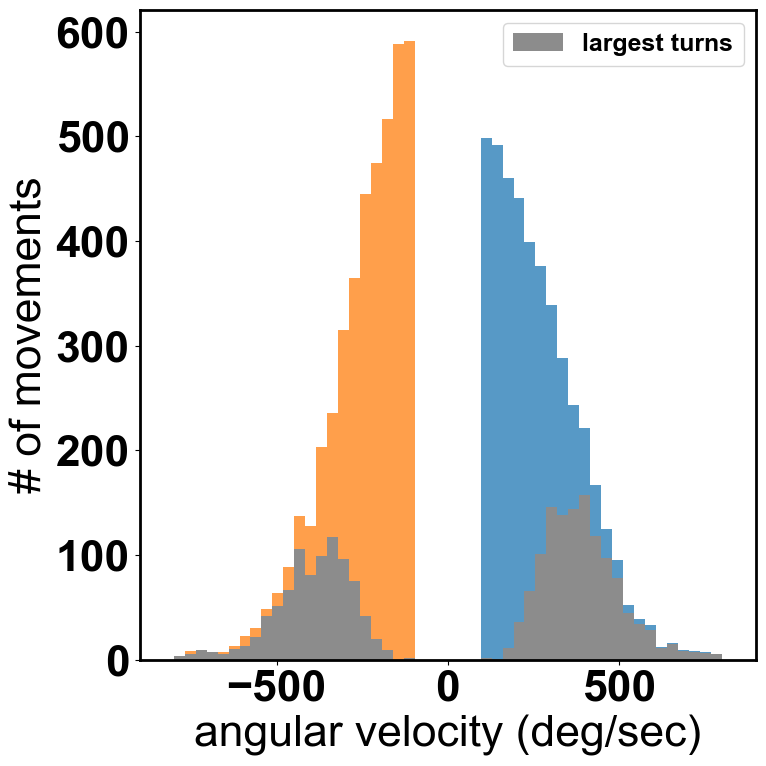

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [572]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  



light = data[data.task == 'oa']

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) 
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) 

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() 
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\yuta_light_all_head_turns.pdf",dpi = 300, transparent=True)

Text(0, 0.5, 'porportion of largest movments')

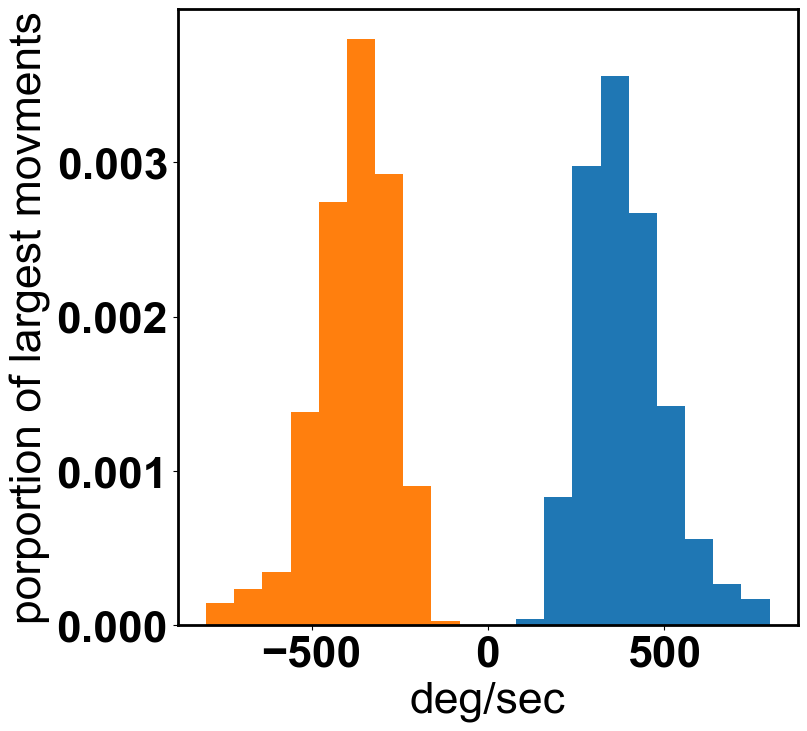

In [306]:
all_turns = light.head_turn_velocity.to_numpy()* 60

pos_turns = all_turns[all_turns>0]
neg_turns = all_turns[all_turns<0]
plt.figure(figsize=(8, 8))
plt.hist(pos_turns,range=(0,800),density=True)
plt.hist(neg_turns,range=(-800,0),density=True)
plt.xlabel('deg/sec')
plt.ylabel('porportion of largest movments')

(array([  12.,   12.,   17.,   20.,   41.,  166.,  507., 1206., 2454.,
        4358.]),
 array([-1.18776208e+03, -1.06898818e+03, -9.50214268e+02, -8.31440360e+02,
        -7.12666451e+02, -5.93892543e+02, -4.75118635e+02, -3.56344726e+02,
        -2.37570818e+02, -1.18796910e+02, -2.30014334e-02]),
 <BarContainer object of 10 artists>)

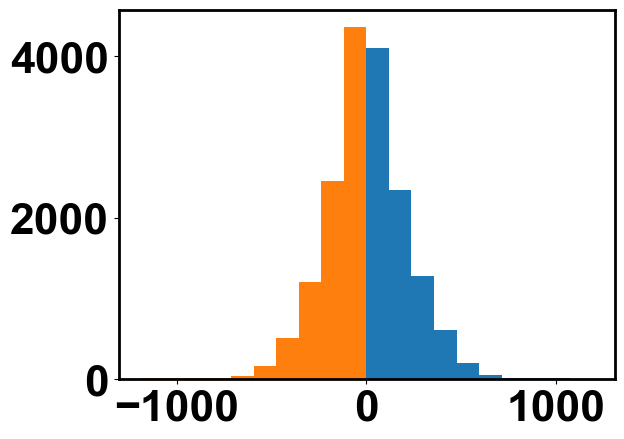

In [288]:
plt.hist(pos_turns)
plt.hist(neg_turns)

In [16]:
np.nanmedian(flatten_list_of_arrays(dark.head_turn_velocities.to_list()))

155.75040141461233

In [15]:
np.nanmedian(flatten_list_of_arrays(light.head_turn_velocities.to_list()))

129.94194031050262

(array([ 22.,  34., 163., 728.,  64.,  82., 857., 214.,  26.,  15.]),
 array([-1187.76208469,  -949.77526967,  -711.78845465,  -473.80163963,
         -235.81482461,     2.17199041,   240.15880542,   478.14562044,
          716.13243546,   954.11925048,  1192.1060655 ]),
 <BarContainer object of 10 artists>)

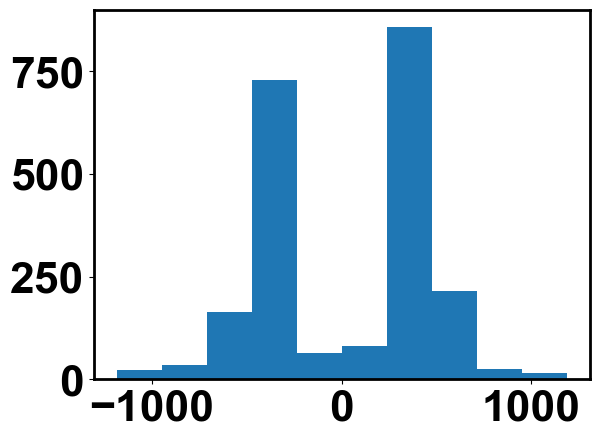

In [282]:
plt.hist(light.head_turn_velocity*60)

(array([  0.,   0.,   0.,  24., 128., 267., 377., 360., 304., 220.]),
 array([  0.,  50., 100., 150., 200., 250., 300., 350., 400., 450., 500.]),
 <BarContainer object of 10 artists>)

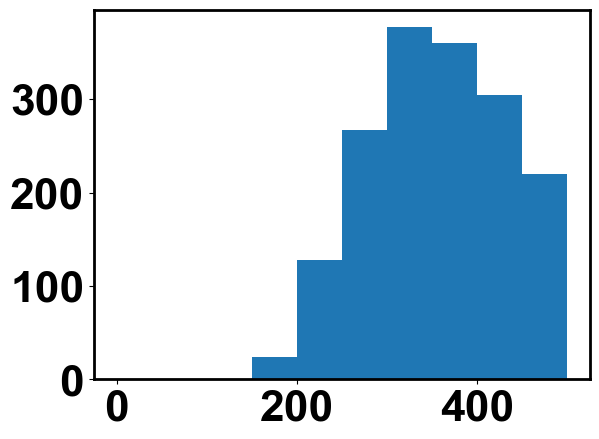

In [34]:
plt.hist(light.head_turn_velocity*60,range= (0,500))

(array([3153., 2589., 2928., 3242., 1523.,  739.,  312.,  124.,   81.,
          72.]),
 array([5.52209337e-03, 1.79338941e+01, 3.58622662e+01, 5.37906383e+01,
        7.17190103e+01, 8.96473824e+01, 1.07575754e+02, 1.25504126e+02,
        1.43432499e+02, 1.61360871e+02, 1.79289243e+02]),
 <BarContainer object of 10 artists>)

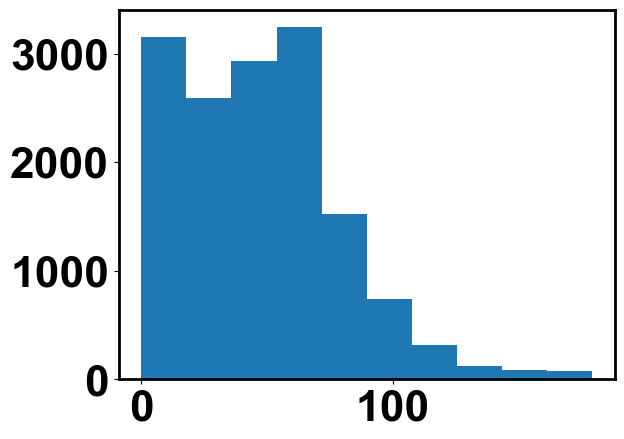

In [10]:
plt.hist(flatten_list_of_arrays(light.angles_at_head_turns.to_numpy()))

(array([7.000e+00, 4.000e+00, 2.000e+00, 1.250e+02, 3.220e+03, 1.594e+03,
        1.365e+03, 1.375e+03, 9.100e+02, 1.450e+02]),
 array([-19. , -14.1,  -9.2,  -4.3,   0.6,   5.5,  10.4,  15.3,  20.2,
         25.1,  30. ]),
 <BarContainer object of 10 artists>)

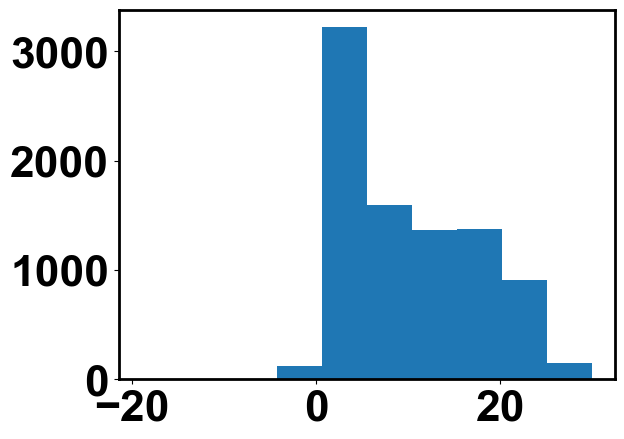

In [19]:
plt.hist(np.round(flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())))

(array([1.59701890e-05, 1.92973117e-05, 2.92786798e-05, 4.52488688e-05,
        1.34415757e-04, 3.57998403e-04, 7.69230769e-04, 1.74407772e-03,
        2.82871972e-03, 4.05576258e-03]),
 array([-1000.,  -900.,  -800.,  -700.,  -600.,  -500.,  -400.,  -300.,
         -200.,  -100.,     0.]),
 <BarContainer object of 10 artists>)

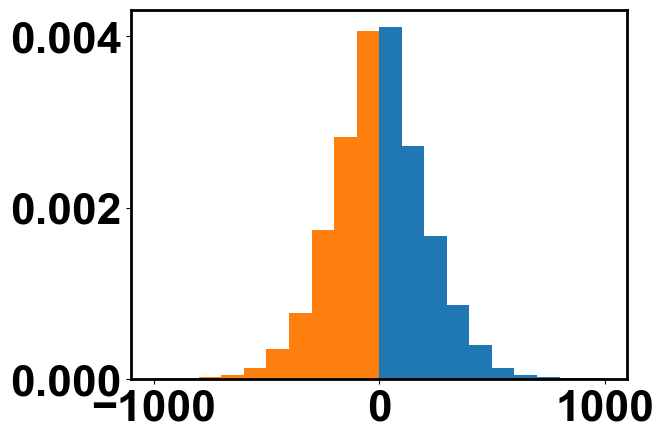

In [242]:
plt.hist(peak_values_pos,range = (0,1000),density=True)
plt.hist(peak_values_neg,range = (-1000,0),density=True)


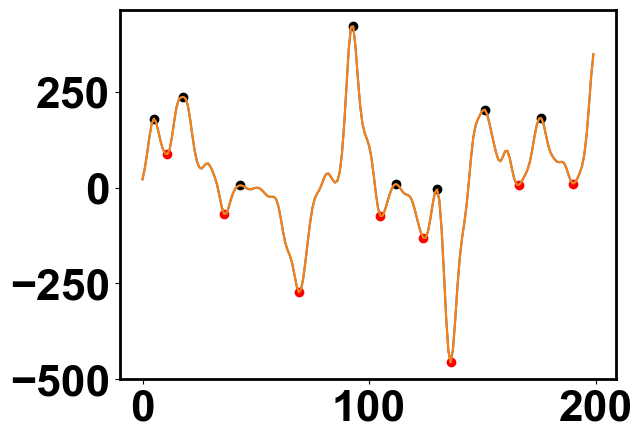

In [281]:
plt.plot(light_head_angle_velocity[:200])

ligh_peaks_pos,light_props_pos =  find_peaks(light_head_angle_velocity[:200],prominence=50)
ligh_peaks_neg,light_props_neg =  find_peaks(light_head_angle_velocity[:200]*-1,prominence=50)
plt.plot(light_head_angle_velocity[:200])
plt.scatter(ligh_peaks_pos,light_head_angle_velocity[ligh_peaks_pos],c='black')
plt.scatter(ligh_peaks_neg,light_head_angle_velocity[ligh_peaks_neg],c='red')

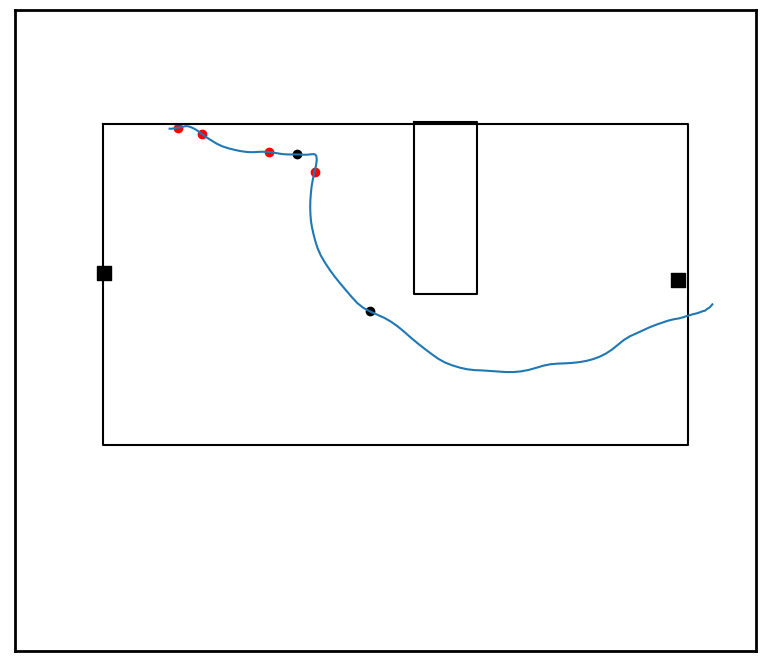

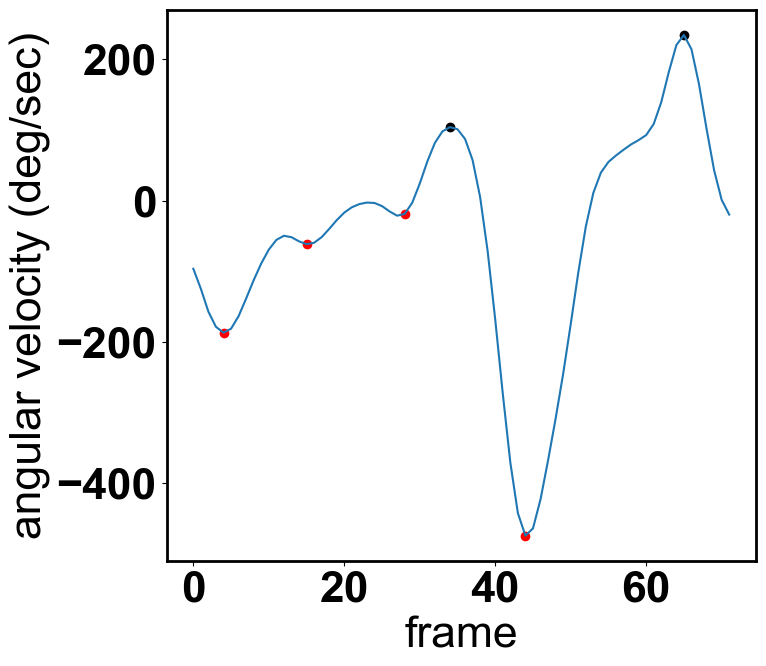

In [ ]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data['obstacle_cluster'].isin([1])] 
data = data[data.intial_lateral_error<0] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    ob_ind = int(row.obstacle_ind)
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
 

   
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('frame')
    ligh_peaks_pos,light_props_pos =  find_peaks(row.head_angle_velocity[:ob_ind],height=0)
    ligh_peaks_neg,light_props_neg =  find_peaks(row.head_angle_velocity[:ob_ind]*-1,height=0)

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        peaks = ligh_peaks_pos
        neg_peaks =ligh_peaks_neg
        
        # Plot on first figure
        ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='tab:blue')
        ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
 
        
        # Plot on second figure
        ax2.plot( smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:blue')
        ax2.scatter([peaks], smooth(row.head_angle_velocity)[peaks]*60, color='black')
     

        ax1.scatter(smooth(row.ts_nose_x_cm)[neg_peaks], smooth(row.ts_nose_y_cm)[neg_peaks], color='red')
   
        
        # Plot on second figure
 
        ax2.scatter([neg_peaks], smooth(row.head_angle_velocity)[neg_peaks]*60, color='red')

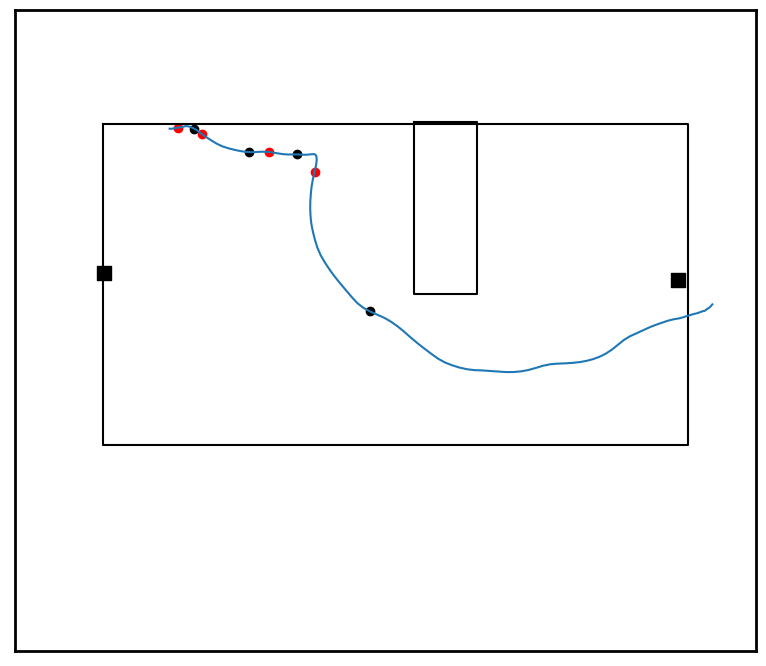

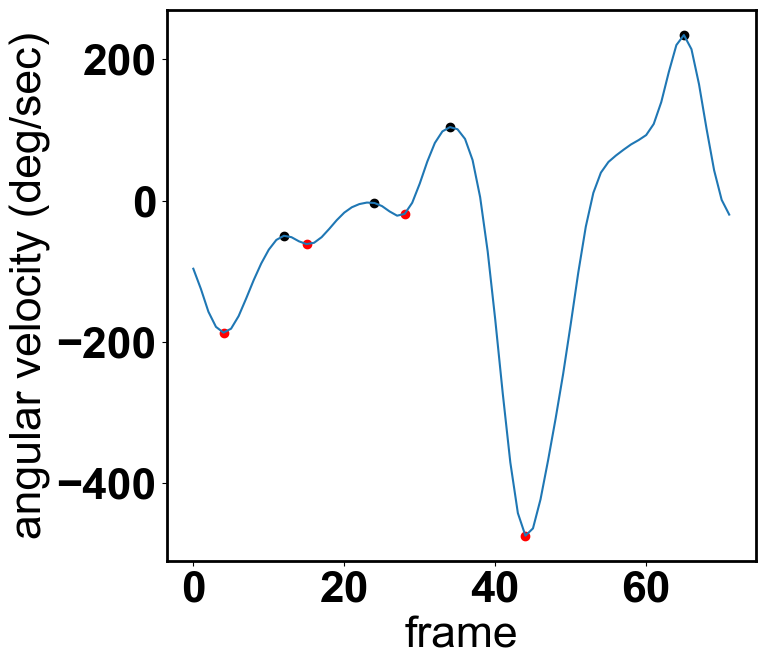

In [215]:
data = pd.concat([light_dark])
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data['obstacle_cluster'].isin([1])] 
data = data[data.intial_lateral_error<0] 

#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    ob_ind = int(row.obstacle_ind)
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
 

   
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('frame')
    ligh_peaks_pos,light_props_pos =  find_peaks(row.head_angle_velocity[:ob_ind])
    ligh_peaks_neg,light_props_neg =  find_peaks(row.head_angle_velocity[:ob_ind]*-1)

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        peaks = ligh_peaks_pos
        neg_peaks =ligh_peaks_neg
        
        # Plot on first figure
        ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='tab:blue')
        ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
 
        
        # Plot on second figure
        ax2.plot( smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:blue')
        ax2.scatter([peaks], smooth(row.head_angle_velocity)[peaks]*60, color='black')
     

        ax1.scatter(smooth(row.ts_nose_x_cm)[neg_peaks], smooth(row.ts_nose_y_cm)[neg_peaks], color='red')
   
        
        # Plot on second figure
 
        ax2.scatter([neg_peaks], smooth(row.head_angle_velocity)[neg_peaks]*60, color='red')

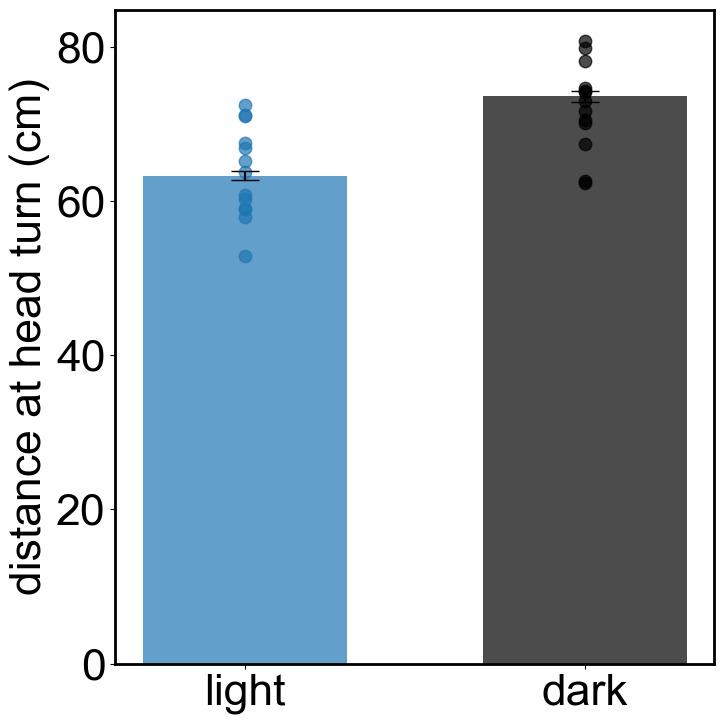

In [636]:
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['angle_before_head_turn'].median()
light_se = light_data['angle_before_head_turn'].sem()
dark_median = dark_data['angle_before_head_turn'].median()
dark_se = dark_data['angle_before_head_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# Add individual animal points for light condition
for i, animal in enumerate(light_data['animal'].unique()):
    animal_dist = light_data[light_data['animal'] == animal]['angle_before_head_turn'].median()
    ax.scatter(0, animal_dist, color='tab:blue', s=80, alpha=0.7,)

# Add individual animal points for dark condition
for i, animal in enumerate(dark_data['animal'].unique()):
    animal_dist = dark_data[dark_data['animal'] == animal]['angle_before_head_turn'].median()
    ax.scatter(1, animal_dist, color='black', s=80, alpha=0.7,)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
ax.set_ylabel('distance at head turn (cm)')

plt.tight_layout()
plt.show()

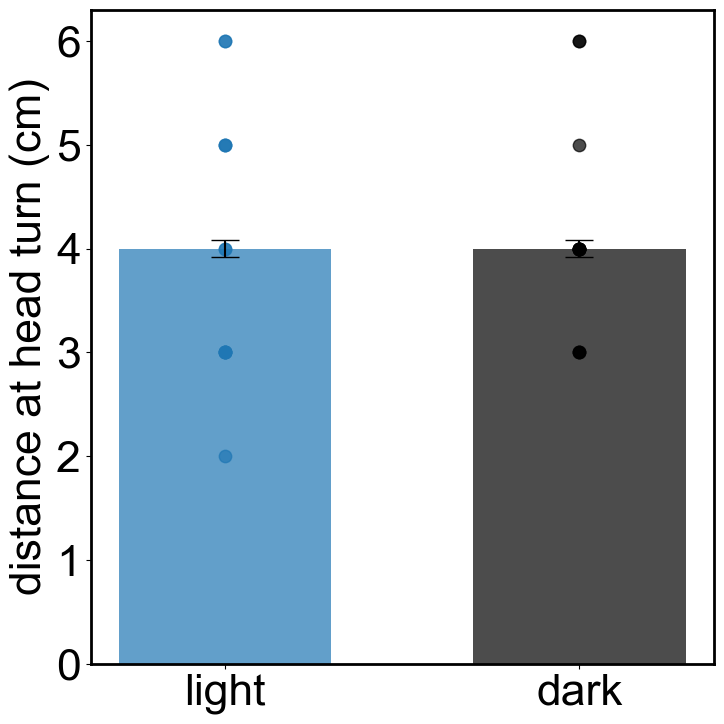

In [637]:
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['task'] == 'oa']
dark_data = data[data['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['num_turn'].median()
light_se = light_data['num_turn'].sem()
dark_median = dark_data['num_turn'].median()
dark_se = dark_data['num_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# Add individual animal points for light condition
for i, animal in enumerate(light_data['animal'].unique()):
    animal_dist = light_data[light_data['animal'] == animal]['num_turn'].median()
    ax.scatter(0, animal_dist, color='tab:blue', s=80, alpha=0.7,)

# Add individual animal points for dark condition
for i, animal in enumerate(dark_data['animal'].unique()):
    animal_dist = dark_data[dark_data['animal'] == animal]['num_turn'].median()
    ax.scatter(1, animal_dist, color='black', s=80, alpha=0.7,)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
ax.set_ylabel('distance at head turn (cm)')

plt.tight_layout()
plt.show()

In [ ]:
def get_head_angle(df):
    """ ego centric head angle using trial"""
    for ind, row in df.iterrows():
        leftear_x = row['ts_leftear_x_cm']
        leftear_y = row['ts_leftear_y_cm']
        rightear_x = row['ts_rightear_x_cm']
        rightear_y = row['ts_rightear_y_cm']
        nose_x = row['ts_nose_x_cm']
        nose_y = row['ts_nose_y_cm']
        angs = []
        if row.odd == 'left':
            for step in range(len(leftear_x)):
                ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step])*-1)
                angs.append(ang)
        else:
            for step in range(len(leftear_x)):
                ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step]))
                angs.append(ang)
        df.at[ind, 'head_angle'] = gaussian_filter(np.array(np.degrees(angs)),2,mode = 'reflect').astype(object)

def get_head_angle_whole_trial(df):
    """ ego centric head angle using trial"""
    for ind, row in df.iterrows():
        leftear_x = row['leftear_x_cm']
        leftear_y = row['leftear_y_cm']
        rightear_x = row['rightear_x_cm']
        rightear_y = row['rightear_y_cm']
        nose_x = row['nose_x_cm']
        nose_y = row['nose_y_cm']
        angs = []
        if row.odd == 'left':
            for step in range(len(leftear_x)):
                ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step])*-1)
                angs.append(ang)
        else:
            for step in range(len(leftear_x)):
                ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step]))
                angs.append(ang)
        df.at[ind, 'head_angle_whole_trial'] = gaussian_filter(np.array(np.degrees(angs)),2,mode = 'reflect').astype(object)

In [1197]:
light_dark.ts_angle_to_corner

0        [22.910957220700098, 15.15938321217035, 5.0697...
1        [34.376282958437095, 26.031155649477473, 15.82...
2        [41.421116148873004, 39.455914996248914, 37.33...
3        [75.56368721643425, 78.61711490211145, 79.8300...
4        [54.23358474925138, 47.98558442665839, 45.8413...
                               ...                        
14548    [88.24773495887553, 82.03124855181409, 72.0203...
14549    [1.2689662770877257, 5.314745369922314, 1.0555...
14550    [48.95931674716832, 37.1786522732223, 36.59180...
14551    [72.9953572263413, 73.97856062538015, 73.65375...
14552    [90.68601508187531, 89.26406283243942, 93.8719...
Name: ts_angle_to_corner, Length: 14553, dtype: object

In [1203]:
range(len(row.ts_angle_to_corner))

range(0, 147)

In [1201]:
for step in list(range(len(row.ts_angle_to_corner))):
    print(step)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146


In [ ]:
if row.odd == 'left':
    for step in range(len(ear_x)):
        ang = np.arctan2(ear_y[step]-corner_y[step],(ear_x[step]-corner_x[step])*-1)
        angs.append(ang)
    else:
        for step in range(len(ear_x)):
            ang = np.arctan2(ear_y[step]-corner_y[step],(ear_x[step]-corner_x[step]))
            angs.append(ang)
    df.at[ind, 'ts_angle_to_corner_new'] = gaussian_filter(np.array(np.degrees(angs)),2,mode = 'reflect').astype(object)

In [ ]:
def ts_angle_to_corner_new(df):
    """get angel of nose to open corner at a hold"""
    for direction, direction_frame in df.groupby(['odd']):
        for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
            for ind,row in cluster_frame.iterrows():
                    
                    nose_x = row['ts_nose_x_cm'].astype(float)
                    nose_y = row['ts_nose_y_cm'].astype(float)
                    ear_x = np.mean([row['ts_rightear_x_cm'],row['ts_leftear_x_cm']],axis=0)
                    ear_y = np.mean([row['ts_rightear_y_cm'],row['ts_leftear_y_cm']],axis=0)
                    
                    if direction == 'right':
                        if cluster == 0 or cluster == 1:
                            corner_x = row['gt_obstacleBR_x_cm']
                            corner_y = row['gt_obstacleBR_y_cm']+2
                            ang = []
                            for i in list(range(len(nose_x))):
                            
                            
                            
                            
                            
                            
                        
                            #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                            try:
                             df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                            except ValueError:
                                print(ang)
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner_new'] = np.nan
                                    
                        if cluster == 2 or cluster == 3:
                                obstalce_edge= np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']])
                                nose_near_edge = nose_x[np.nanargmin(np.abs(np.array(nose_x) - obstalce_edge))]
                                ind_nose_near_edge = np.argwhere(nose_x==nose_near_edge)[0][0]
                                distance_to_top = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleTR_y_cm']))
                                distance_to_bottom = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleBR_y_cm']))
                                if distance_to_top < distance_to_bottom:
                                    corner_x = row['gt_obstacleTR_x_cm']
                                    corner_y = row['gt_obstacleTR_y_cm']-2
                                    ang = []
                                    
                                    
                                    for i in list(range(len(nose_x))):
                                        

                                        
                                    ang = np.array(ang)
                                    
                                    
                                if distance_to_top > distance_to_bottom:
                                    corner_x = row['gt_obstacleBR_x_cm']
                                    corner_y = row['gt_obstacleBR_y_cm']+2
                                    ang = []
                                    
                                    
                                    for i in list(range(len(nose_x))):
                                        
                                        
                                    ang = np.array(ang)
                                    
                                    
                                #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                                try:
                                    df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                                    
                                except IndexError:
                                    
                                    
                                    
                                    
                        if cluster == 4 or cluster == 5:
                            corner_x = row['gt_obstacleTR_x_cm']
                            corner_y = row['gt_obstacleTR_y_cm']-2
                            ang = []
                            
                            
                            
                            for i in list(range(len(nose_x))):
                                
                                
                            ang = np.array(ang)
                            
                            
                            #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                                
                            except IndexError:
                                
                             
                    if direction == 'left':
                        if cluster == 0 or cluster == 1:
                            corner_x = row['gt_obstacleBL_x_cm']
                            corner_y = row['gt_obstacleBL_y_cm']+2
                            ang = []
                            
                            
                            
                            for i in list(range(len(nose_x))):
                                
                            ang = np.array(ang)
                            
                            
                            #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                                
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner_new'] = np.nan
                                
                        if cluster == 2 or cluster == 3:
                                obstalce_edge= np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']])
                                nose_near_edge = nose_x[np.nanargmin(np.abs(np.array(nose_x) - obstalce_edge))]
                                ind_nose_near_edge = np.argwhere(nose_x==nose_near_edge)[0][0]
                                distance_to_top = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleTL_y_cm']))
                                distance_to_bottom = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleBL_y_cm']))
                                if distance_to_top < distance_to_bottom:
                                    corner_x = row['gt_obstacleTL_x_cm']
                                    corner_y = row['gt_obstacleTL_y_cm']-2
                                    ang = []
                                    
                                    
                                    for i in list(range(len(nose_x))):
                                        
                                        
                                    ang = np.array(ang)
                                    
                                    
                                if distance_to_top > distance_to_bottom:
                                    corner_x = row['gt_obstacleBL_x_cm']
                                    corner_y = row['gt_obstacleBL_y_cm']+2
                                    ang = []
                                    
                                    
                                    for i in list(range(len(nose_x))):
                                        
                                        
                                    ang = np.array(ang)
                                    
                                    
                                #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                                try:
                                    df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                                    
                                except IndexError:
                                    
                            
                            
                        if cluster == 4 or cluster == 5:
                            corner_x = row['gt_obstacleTL_x_cm']
                            corner_y = row['gt_obstacleTL_y_cm']-2
                            ang = []
                            
                            
                            
                            for i in list(range(len(nose_x))):
                                
                                
                            ang = np.array(ang)
                            
                            
                            #df.at[ind,'angle_to_corner_' + str()] = ang.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner_new'] = ang.astype(object)
                                
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner_new'] = np.nan
                                